# EDA House rent

Datos tomados de: https://www.kaggle.com/datasets/rkb0023/houserentpredictiondataset

## Contexto

El mercado inmobiliario es un sector dinámico en el que los precios de las viviendas pueden variar según múltiples factores, como la ubicación, el tamaño, las condiciones del mercado y las características de la propiedad. Este dataset fue recopilado por Austin Reese el 7 de enero de 2020 desde Craiglist.org, un sitio web de anuncios clasificados. Contiene 265,190 registros de viviendas con 22 variables, proporcionando una fuente rica para el análisis de precios de inmuebles.

Es posible que los datos presenten ciertas irregularidades, como valores atípicos, información incompleta o inconsistencias en los atributos. Sin embargo, este conjunto de datos representa una excelente oportunidad para aplicar técnicas de exploración, limpieza y modelado predictivo en el ámbito de la analítica de datos inmobiliaria.

## Problema

El objetivo de este proyecto es desarrollar modelos de analítica de datos para predecir dos aspectos clave del mercado inmobiliario:

1. Predicción del precio de la vivienda: Utilizar regresión lineal para estimar el precio de una propiedad en función de sus características. Se busca identificar qué factores tienen mayor impacto en el valor de las viviendas y evaluar la precisión del modelo en distintas condiciones.

2. Clasificación del tipo de casa: Aplicar modelos de regresión logística para predecir el tipo de vivienda en función de sus atributos. Se pretende evaluar cómo las variables del dataset (como el número de habitaciones, baños, tamaño, etc.) pueden ayudar a categorizar correctamente las viviendas en diferentes tipos.

Para abordar este problema, se llevará a cabo un proceso de análisis y modelado, que incluirá:

1. Limpieza de datos: Identificación y tratamiento de valores nulos, inconsistencias y valores atípicos.
2. Análisis exploratorio (EDA): Visualización y evaluación de la relación entre variables.
3. Transformación de datos: Codificación de variables categóricas, escalado de variables numéricas y selección de características relevantes.
4. Entrenamiento y evaluación de modelos: Aplicación de regresión lineal para la predicción de precios y regresión logística para la clasificación del tipo de casa, con métricas de desempeño como RMSE (para regresión) y precisión o F1-score (para clasificación).
5. Optimización de modelos: Ajuste de hiperparámetros y validación cruzada para mejorar el rendimiento.

Este enfoque permitirá no solo comprender los factores que influyen en los precios de las viviendas, sino también desarrollar herramientas predictivas útiles para la toma de decisiones en el sector inmobiliario.

## Paso 1: Importar Liberias

In [1]:
import pandas  as pd
import numpy as np
import kagglehub
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelBinarizer
import os

C:\Users\guill\Documents\GitHub\taller-house-rent\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Paso 2: Descargar los datos

In [2]:
path = kagglehub.dataset_download("rkb0023/houserentpredictiondataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\guill\.cache\kagglehub\datasets\rkb0023\houserentpredictiondataset\versions\1


In [3]:
files_in_directory = os.listdir(path)
print("Files in dataset directory:", files_in_directory)

Files in dataset directory: ['houseRent']


In [4]:
files_in_directory = os.listdir(f"{path}/houseRent")
print("Files in dataset directory:", files_in_directory)

Files in dataset directory: ['housePricing.docx', 'housing_train.csv']


In [5]:
df = pd.read_csv(f"{path}/houseRent/housing_train.csv")

In [6]:
df.shape

(265190, 22)

In [7]:
df.head()

,id,url,region,region_url,price,type,sqfeet,beds,baths,cats_allowed,...,wheelchair_access,electric_vehicle_charge,comes_furnished,laundry_options,parking_options,image_url,description,lat,long,state
0,7039061606,https://bham.craigslist.org/apa/d/birmingham-h...,birmingham,https://bham.craigslist.org,1195,apartment,1908,3,2.0,1,...,0,0,0,laundry on site,street parking,https://images.craigslist.org/00L0L_80pNkyDeG0...,Apartments In Birmingham AL Welcome to 100 Inv...,33.4226,-86.7065,al
1,7041970863,https://bham.craigslist.org/apa/d/birmingham-w...,birmingham,https://bham.craigslist.org,1120,apartment,1319,3,2.0,1,...,0,0,0,laundry on site,off-street parking,https://images.craigslist.org/00707_uRrY9CsNMC...,Find Your Way to Haven Apartment Homes Come ho...,33.3755,-86.8045,al
2,7041966914,https://bham.craigslist.org/apa/d/birmingham-g...,birmingham,https://bham.craigslist.org,825,apartment,1133,1,1.5,1,...,0,0,0,laundry on site,street parking,https://images.craigslist.org/00h0h_b7Bdj1NLBi...,Apartments In Birmingham AL Welcome to 100 Inv...,33.4226,-86.7065,al
3,7041966936,https://bham.craigslist.org/apa/d/birmingham-f...,birmingham,https://bham.craigslist.org,800,apartment,927,1,1.0,1,...,0,0,0,laundry on site,street parking,https://images.craigslist.org/00808_6ghZ8tSRQs...,Apartments In Birmingham AL Welcome to 100 Inv...,33.4226,-86.7065,al
4,7041966888,https://bham.craigslist.org/apa/d/birmingham-2...,birmingham,https://bham.craigslist.org,785,apartment,1047,2,1.0,1,...,0,0,0,laundry on site,street parking,https://images.craigslist.org/00y0y_21c0FOvUXm...,Apartments In Birmingham AL Welcome to 100 Inv...,33.4226,-86.7065,al


In [8]:
df.tail()

,id,url,region,region_url,price,type,sqfeet,beds,baths,cats_allowed,...,wheelchair_access,electric_vehicle_charge,comes_furnished,laundry_options,parking_options,image_url,description,lat,long,state
265185,7050851033,https://columbus.craigslist.org/apa/d/columbus...,columbus,https://columbus.craigslist.org,0,apartment,1061,2,2.0,1,...,0,0,0,w/d in unit,detached garage,https://images.craigslist.org/00m0m_8wP9hX96TZ...,â BERKLEY HOUSE â Voted #1 BEST Communit...,40.0495,-83.0669,oh
265186,7050887997,https://columbus.craigslist.org/apa/d/grove-ci...,columbus,https://columbus.craigslist.org,1069,apartment,1020,2,1.5,1,...,0,0,0,w/d hookups,detached garage,https://images.craigslist.org/00N0N_ioCvFNCv24...,!!!!Tour today and receive $5 Starbucks gift c...,39.8408,-83.0804,oh
265187,7044801015,https://columbus.craigslist.org/apa/d/columbus...,columbus,https://columbus.craigslist.org,1507,apartment,1660,2,1.5,1,...,0,0,0,NaN,NaN,https://images.craigslist.org/00j0j_5EIRWzdHCV...,"The Commons at Olentangy4765 Blairfield Dr, Co...",40.0564,-83.0417,oh
265188,7050885800,https://columbus.craigslist.org/apa/d/newark-l...,columbus,https://columbus.craigslist.org,1001,apartment,1220,3,1.5,1,...,0,0,0,w/d hookups,off-street parking,https://images.craigslist.org/00J0J_6VSTqFJb86...,www.McMillenWoods.com www.mcmillenwoods.com ...,40.0451,-82.4564,oh
265189,7050884586,https://columbus.craigslist.org/apa/d/columbus...,columbus,https://columbus.craigslist.org,1164,townhouse,1300,2,2.5,1,...,0,0,0,w/d hookups,attached garage,https://images.craigslist.org/00w0w_h1L3gxb8rG...,Park Club apartments is offering some of the B...,NaN,NaN,NaN


## Paso 3: Análisis de datos

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265190 entries, 0 to 265189
Data columns (total 22 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       265190 non-null  int64  
 1   url                      265190 non-null  object 
 2   region                   265190 non-null  object 
 3   region_url               265190 non-null  object 
 4   price                    265190 non-null  int64  
 5   type                     265190 non-null  object 
 6   sqfeet                   265190 non-null  int64  
 7   beds                     265190 non-null  int64  
 8   baths                    265190 non-null  float64
 9   cats_allowed             265190 non-null  int64  
 10  dogs_allowed             265190 non-null  int64  
 11  smoking_allowed          265190 non-null  int64  
 12  wheelchair_access        265190 non-null  int64  
 13  electric_vehicle_charge  265190 non-null  int64  
 14  come

In [10]:
df.dtypes

id                           int64
url                         object
region                      object
region_url                  object
price                        int64
type                        object
sqfeet                       int64
beds                         int64
baths                      float64
cats_allowed                 int64
dogs_allowed                 int64
smoking_allowed              int64
wheelchair_access            int64
electric_vehicle_charge      int64
comes_furnished              int64
laundry_options             object
parking_options             object
image_url                   object
description                 object
lat                        float64
long                       float64
state                       object
dtype: object

In [11]:
# Select specific numerical columns
selected_columns = ['price', 'sqfeet', 'beds', 'baths']
numerical_columns = [col for col in selected_columns if col in df.columns]

# Compute summary statistics
statistics = df[numerical_columns].agg(
    ['mean', 'median', 'std', 'var', 'min', 'max', 'skew', 'kurt']
).T.rename(columns={
    "mean": "Mean",
    "median": "Median",
    "std": "Standard Deviation",
    "var": "Variance",
    "min": "Minimum",
    "max": "Maximum",
    "skew": "Skewness",
    "kurt": "Kurtosis"
})

# Display results
print("\nMedidas de tendencia central y dispersión:\n")
statistics


Medidas de tendencia central y dispersión:



,Mean,Median,Standard Deviation,Variance,Minimum,Maximum,Skewness,Kurtosis
price,12272.853592,1060.0,5.376352e+06,2.890516e+13,0.0,2.768307e+09,514.780933,265062.432267
sqfeet,1093.678287,950.0,2.306888e+04,5.321730e+08,0.0,8.388607e+06,340.467541,120492.280883
beds,1.912414,2.0,3.691900e+00,1.363012e+01,0.0,1.100000e+03,272.959497,79164.809147
baths,1.483468,1.0,6.302080e-01,3.971621e-01,0.0,7.500000e+01,13.323474,1427.809871


Los datos presentados describen características de propiedades inmobiliarias, incluyendo precio, tamaño en pies cuadrados, número de habitaciones y número de baños. Se incluyen estadísticas clave como la media, mediana, varianza, desviación estándar, valores mínimos y máximos, así como medidas de forma de la distribución (sesgo y curtosis).

A continuación, se analiza cada variable:

**price** (precio):
- **Promedio**: \$12,272.85
- **Mediana**: \$1,060.00 (el 50% de las propiedades tienen un precio menor a este valor).
- **Varianza**: 28,905,157,770,383.52 (indica una dispersión extremadamente alta en los precios).
- **Desviación estándar**: 5,376,351.72 (posiblemente errónea, ya que es demasiado grande en relación con los valores esperados).
- **Mínimo**: \$0.00 (debe eliminarse, ya que probablemente representa datos erróneos o registros incompletos).
- **Máximo**: \$2,768,307,249.00 (valor excesivamente alto, indica la presencia de valores atípicos).
- **Sesgo positivo extremo**: 514.78 (la distribución está altamente sesgada hacia valores muy elevados).
- **Curtosis leptocúrtica extrema**: 265,062.43 (indica la presencia de valores atípicos extremos que afectan la distribución).

**Interpretación**:
La distribución del precio muestra una alta asimetría positiva, lo que significa que hay propiedades con precios excepcionalmente altos que distorsionan la media y otras medidas de tendencia central. La curtosis extremadamente alta confirma que existen valores atípicos significativos en la distribución. Además, el valor mínimo de \$0.00 es poco realista y probablemente erróneo, por lo que debe eliminarse del análisis. Para mejorar la calidad de los resultados, se recomienda realizar una limpieza de datos, filtrando o ajustando valores atípicos antes de aplicar cualquier modelo estadístico o predictivo.




**sqfeet** (Tamaño en pies cuadrados):
- **Promedio**: 1,093.68 pies²
- **Mediana**: 950.00 pies² (el 50% de las propiedades tienen un tamaño menor a este valor).
- **Varianza**: 532,173,020.04 (indica una dispersión muy alta en los tamaños de las propiedades).
- **Desviación estándar**: 532,173,020.04 (probablemente errónea, ya que es excesivamente grande en comparación con los valores esperados).
- **Mínimo**: 0.00 pies² (valor poco realista, lo que sugiere datos erróneos o faltantes; debe eliminarse).
- **Máximo**: 8,388,607.00 pies² (demasiado alto para una propiedad residencial, indica la presencia de valores atípicos).
- **Sesgo positivo extremo**: 340.47 (la distribución está fuertemente inclinada hacia propiedades con tamaños inusualmente grandes).
- **Curtosis leptocúrtica extrema**: 120,492.28 (la distribución presenta valores atípicos extremos que afectan su forma).

**Interpretación**:
La distribución del tamaño de las propiedades muestra un sesgo positivo extremo, lo que indica que existen registros con tamaños desproporcionadamente grandes, probablemente propiedades comerciales, terrenos o datos erróneos. La curtosis extremadamente alta confirma la presencia de valores atípicos significativos. Además, el valor mínimo de **0.00 pies²** es poco realista y probablemente un error, por lo que debe ser eliminado del análisis. Se recomienda realizar una limpieza de datos eliminando o ajustando estos valores atípicos para evitar distorsiones en cualquier análisis estadístico o modelo predictivo.

**beds** (Número de habitaciones):
- **Promedio**: 1.91 habitaciones
- **Mediana**: 2.00 habitaciones (la mayoría de las propiedades tienen 2 habitaciones o menos).
- **Varianza**: 13.63 (indica una dispersión relativamente amplia en el número de habitaciones).
- **Desviación estándar**: 3.692 (indica que hay propiedades con un número significativamente diferente de habitaciones respecto a la media).
- **Mínimo**: 0.00 habitaciones (posiblemente estudios o registros incorrectos; se debe evaluar su validez).
- **Máximo**: 1,100.00 habitaciones (valor excesivamente alto, probablemente un error o un registro comercial).
- **Sesgo positivo extremo**: 272.96 (indica que hay valores extremadamente altos que distorsionan la distribución).
- **Curtosis leptocúrtica extrema**: 79,164.80 (altamente influenciada por valores atípicos, lo que confirma la presencia de datos inusuales).

**Interpretación**:
La distribución del número de habitaciones presenta un **sesgo positivo extremo**, lo que indica la presencia de registros con valores inusualmente altos. El máximo de **1,100 habitaciones** es **poco realista** para propiedades residenciales y sugiere errores en los datos o la inclusión de registros comerciales. Por otro lado, el valor **mínimo de 0 habitaciones** podría corresponder a estudios, pero también a datos erróneos.

In [12]:
statistics

,Mean,Median,Standard Deviation,Variance,Minimum,Maximum,Skewness,Kurtosis
price,12272.853592,1060.0,5.376352e+06,2.890516e+13,0.0,2.768307e+09,514.780933,265062.432267
sqfeet,1093.678287,950.0,2.306888e+04,5.321730e+08,0.0,8.388607e+06,340.467541,120492.280883
beds,1.912414,2.0,3.691900e+00,1.363012e+01,0.0,1.100000e+03,272.959497,79164.809147
baths,1.483468,1.0,6.302080e-01,3.971621e-01,0.0,7.500000e+01,13.323474,1427.809871


**Baths** (Número de baños):
- Promedio: 1.48 baños
- Mediana: 1.00 baño (la mayoría de las propiedades tienen un solo baño).
- Varianza: 0.63 (baja dispersión, la mayoría de las propiedades tienen un número similar de baños).
- Desviación estándar: 0.39 (indica poca variabilidad).
- Mínimo: 0.00 baños (podría tratarse de errores o baños compartidos).
- Máximo: 75.00 baños (valor extremadamente alto, sugiere un error en los datos).
- Sesgo: 13.32 (distribución sesgada hacia propiedades con más baños)
- Curtosis: 1,427.80 (muestra que existen valores atípicos).

**Interpretación**: Aunque el número de baños tiene menor variabilidad, el máximo de 75 baños es claramente un error o corresponde a un registro comercial. También hay propiedades con 0 baños, lo que puede significar errores o baños compartidos. Se recomienda filtrar valores extremos para un análisis más fiable.

## Paso 4: Gestión de duplicaciones y valores faltantes

### 4.1 Manejo de duplicaciones

In [13]:
duplicates = df.duplicated().sum()

In [14]:
print(f"Número de registros duplicados: {duplicates}")

Número de registros duplicados: 0


### 4.2 Manejo de valores faltantes

In [15]:
len(df)

265190

In [16]:
missing_data = df.isnull().sum()[df.isnull().sum() > 0]

In [17]:
missing_data

laundry_options    54311
parking_options    95135
description            2
lat                 1419
long                1419
state                  1
dtype: int64

In [18]:
#Listar las variables con valores nulos
vars_null = [var for var in df.columns if df[var].isnull().sum() > 0]
print(len(vars_null))
#ordenar las variables con faltantes según su proporcion
df[vars_null].isnull().mean().sort_values(ascending=False)

6


parking_options    0.358743
laundry_options    0.204800
lat                0.005351
long               0.005351
description        0.000008
state              0.000004
dtype: float64

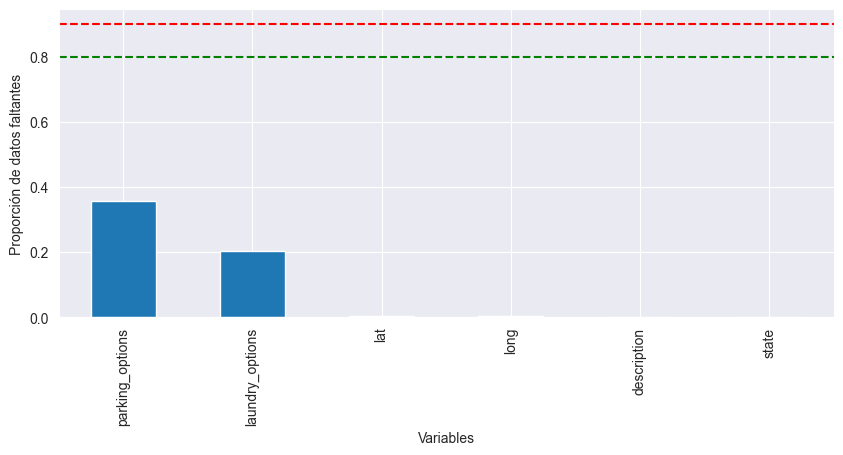

In [19]:
df[vars_null].isnull().mean().sort_values(ascending=False).plot.bar(figsize=(10,4))
plt.ylabel('Proporción de datos faltantes')
plt.xlabel('Variables')
plt.axhline(y=0.90, color='r', linestyle='--')
plt.axhline(y=0.80, color='g', linestyle='--')
plt.show()

Las variables **opciones de parqueo** (*parking_options*) y **opciones de lavado** (*laundry_options*) presentan más del 20% de valores faltantes, lo que indica la necesidad de aplicar un método especializado para su imputación.

In [20]:
df['state'].value_counts()

state
ca    33085
fl    31929
nc    18628
mi    14529
ga    13841
co    11308
ny     9991
il     9706
ks     7910
ia     7488
mn     7468
md     7451
la     7304
az     6752
oh     6558
in     6416
al     6198
nj     5711
ky     5419
ms     4973
ma     4926
id     4466
ct     3765
nd     3428
ar     3149
nm     2917
nv     2846
ne     2697
dc     2502
ak     2169
mo     2158
de     2048
hi     1840
nh     1761
mt     1339
me      420
ok       49
or       44
Name: count, dtype: int64

In [21]:
freq_encoding = df['state'].value_counts().idxmax()
df['state'].fillna(freq_encoding, inplace=True)

C:\Users\guill\AppData\Local\Temp\ipykernel_7992\1321309039.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['state'].fillna(freq_encoding, inplace=True)


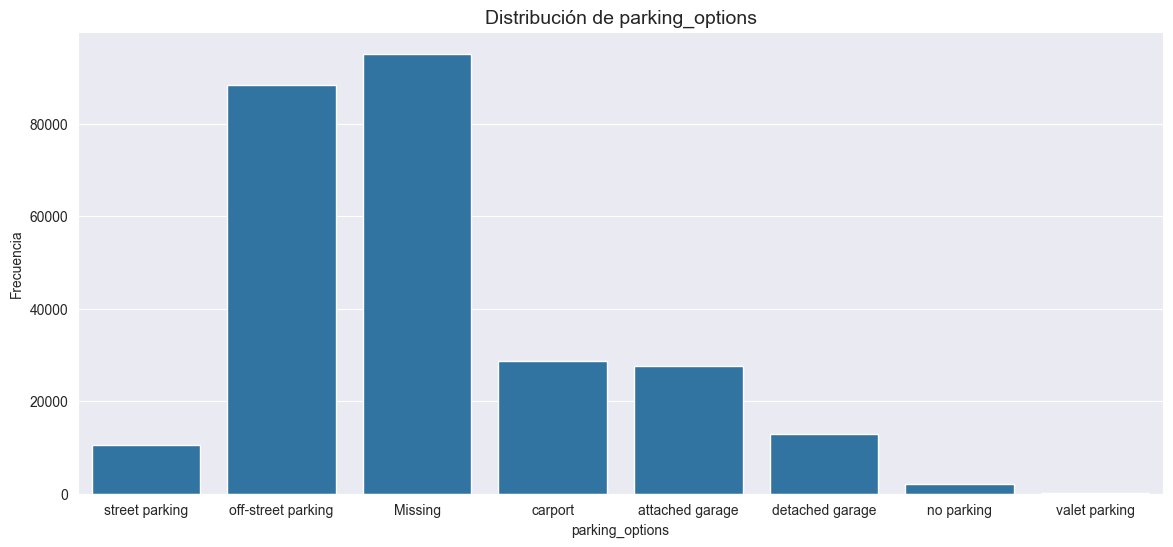

In [22]:
df_missing = df.assign(parking_options=df["parking_options"].fillna("Missing"))
plt.figure(figsize=(14, 6))
sns.countplot(data=df_missing, x="parking_options")
plt.title('Distribución de parking_options', fontsize=14)
plt.xlabel("parking_options")
plt.ylabel('Frecuencia')
plt.show()

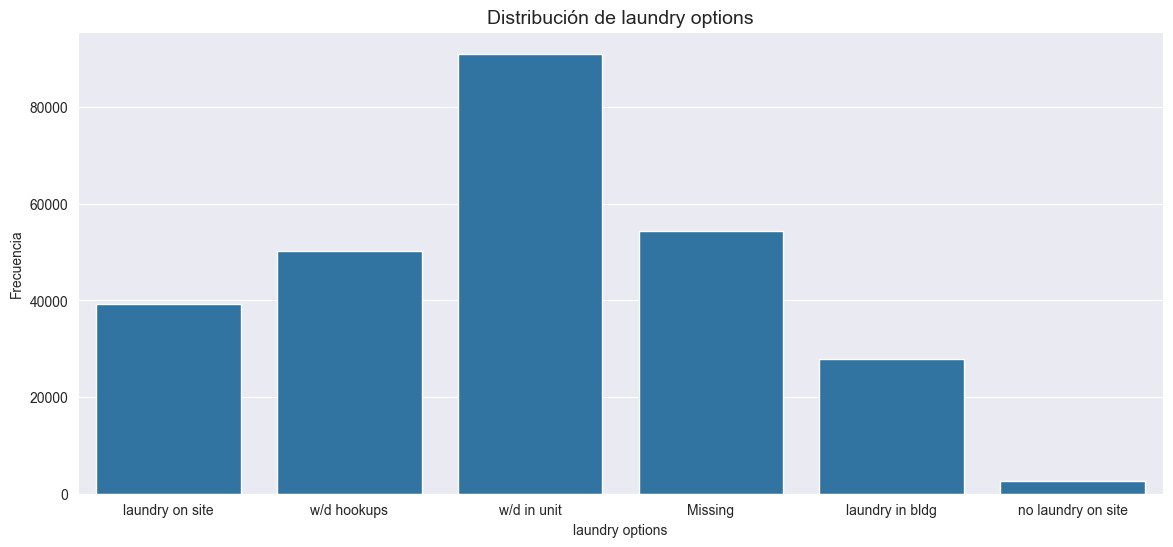

In [23]:
df_missing = df.assign(laundry_options=df["laundry_options"].fillna("Missing"))
plt.figure(figsize=(14, 6))
sns.countplot(data=df_missing, x="laundry_options")
plt.title('Distribución de laundry options', fontsize=14)
plt.xlabel("laundry options")
plt.ylabel('Frecuencia')
plt.show()

In [24]:
# Select relevant categorical column
df_copy = df[['parking_options']].copy()

# Encode categorical values
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df_copy[['parking_options']] = encoder.fit_transform(df_copy[['parking_options']])

# Apply KNN Imputation
imputer = KNNImputer(n_neighbors=3)
df_copy[['parking_options']] = imputer.fit_transform(df_copy[['parking_options']])

# Convert to integers to match encoding
df_copy['parking_options'] = df_copy['parking_options'].round().astype(int)

# Ensure values are within the valid range
max_valid_index = len(encoder.categories_[0]) - 1
df_copy['parking_options'] = np.clip(df_copy['parking_options'], 0, max_valid_index)

# Now inverse transform safely
df_copy[['parking_options']] = encoder.inverse_transform(df_copy[['parking_options']])

# Assign back to original dataframe
df['parking_options'] = df_copy['parking_options']


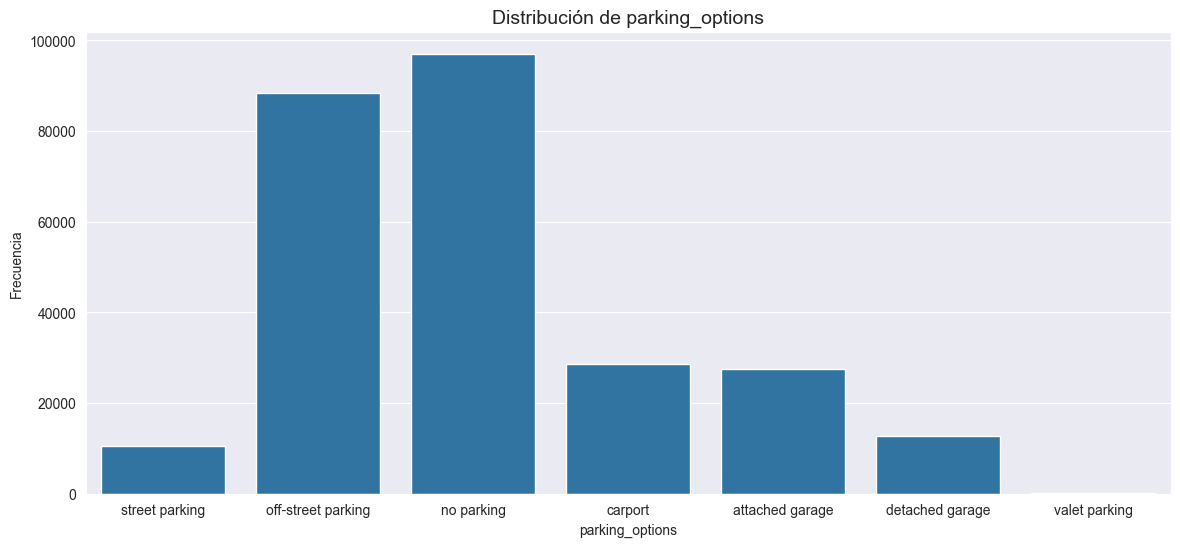

In [25]:
df_missing = df_copy.assign(parking_options=df_copy["parking_options"].fillna("Missing"))
plt.figure(figsize=(14, 6))
sns.countplot(data=df_missing, x="parking_options")
plt.title('Distribución de parking_options', fontsize=14)
plt.xlabel("parking_options")
plt.ylabel('Frecuencia')
plt.show()

In [26]:
# Select relevant categorical column
df_copy = df[['laundry_options']].copy()

# Encode categorical values
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df_copy[['laundry_options']] = encoder.fit_transform(df_copy[['laundry_options']])

# Apply KNN Imputation
imputer = KNNImputer(n_neighbors=3)
df_copy[['laundry_options']] = imputer.fit_transform(df_copy[['laundry_options']])

# Convert to integers to match encoding
df_copy['laundry_options'] = df_copy['laundry_options'].round().astype(int)

# Ensure values are within the valid range
max_valid_index = len(encoder.categories_[0]) - 1
df_copy['laundry_options'] = np.clip(df_copy['laundry_options'], 0, max_valid_index)

# Now inverse transform safely
df_copy[['laundry_options']] = encoder.inverse_transform(df_copy[['laundry_options']])

# Assign back to original dataframe
df['laundry_options'] = df_copy['laundry_options']


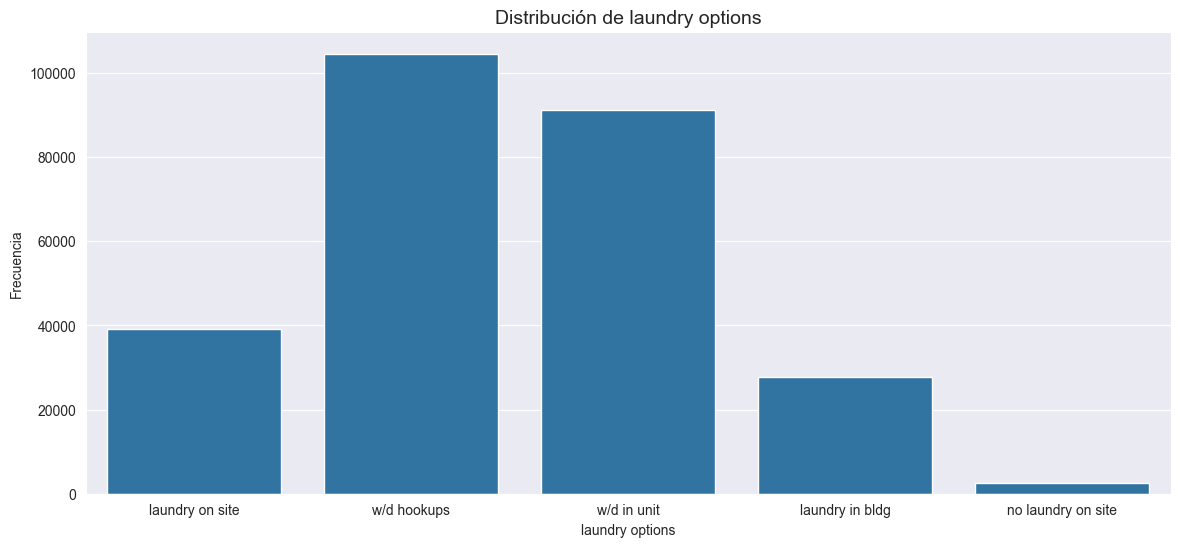

In [27]:
df_missing = df_copy.assign(parking_options=df_copy["laundry_options"].fillna("Missing"))
plt.figure(figsize=(14, 6))
sns.countplot(data=df_missing, x="laundry_options")
plt.title('Distribución de laundry options', fontsize=14)
plt.xlabel("laundry options")
plt.ylabel('Frecuencia')
plt.show()

## Paso 5:  Reducción de Datos

In [28]:
## Check "parking_options", "laundry_options"
data = df.drop(columns=["id", "url", "region_url", "image_url", "description", "lat", "long"])


## Paso 6: Ingeniería de Características (Feature Engineering)

### Paso 6.1: Crear Caracteristicas

In [29]:
data["price_per_sqfeet"] = data["price"] / data["sqfeet"]
data["baths_per_beds"] = data["baths"] / data["beds"]
data["beds_per_sqfeet"] = data["beds"] / data["sqfeet"]

data["baths_per_beds"] = data["baths_per_beds"].apply(lambda x: x if np.isfinite(x) else 0)

## Paso 7: Limpieza y Manipulación de Datos

In [30]:
luxury_threshold = data['price'].quantile(0.85)
data['home_type'] = data['price'].apply(lambda x: 'Luxury Home' if x >= luxury_threshold else 'Standard Home')

In [31]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

data_cleaned = remove_outliers(data, 'price')
data_cleaned = remove_outliers(data_cleaned, 'sqfeet')

In [32]:
data_cleaned = data_cleaned[data_cleaned["price"] != 0]

## Paso 8: Agrupar las variables según el tipo

### Paso 8.1: Guardar la variable objetivo

In [33]:
target_var_num = "price"

In [34]:
target_var_cat = "home_type"

### Paso 8.2: Guardar las variables categorias

In [35]:
vars_cat = [var for var in data.columns if (data[var].dtype == "O"
            or var == "cats_allowed"
            or var == "dogs_allowed"
            or var == "smoking_allowed"
            or var == "wheelchair_access"
            or var == "electric_vehicle_charge"
            or var == "comes_furnished"
            or var == "parking_options"
            or var == "laundry_options")
            and var != target_var_cat]

In [36]:
vars_cat

['region',
 'type',
 'cats_allowed',
 'dogs_allowed',
 'smoking_allowed',
 'wheelchair_access',
 'electric_vehicle_charge',
 'comes_furnished',
 'laundry_options',
 'parking_options',
 'state']

### Paso 8.3 Guardar las variables númericas

In [37]:
vars_nums = [var for var in data.columns if data[var].dtype != "O" and var != "price" and var not in vars_cat]

In [38]:
vars_nums

['sqfeet',
 'beds',
 'baths',
 'price_per_sqfeet',
 'baths_per_beds',
 'beds_per_sqfeet']

### Paso 8.4 Variables discretas

In [39]:
vars_disc = ["beds", "baths"]

In [40]:
vars_con = ["sqfeet","price_per_sqfeet", "baths_per_beds", "beds_per_sqfeet"]

## Paso 9: Análisis Univariado

### Paso 9.1: Análisis Univeriado de Variables Categorías

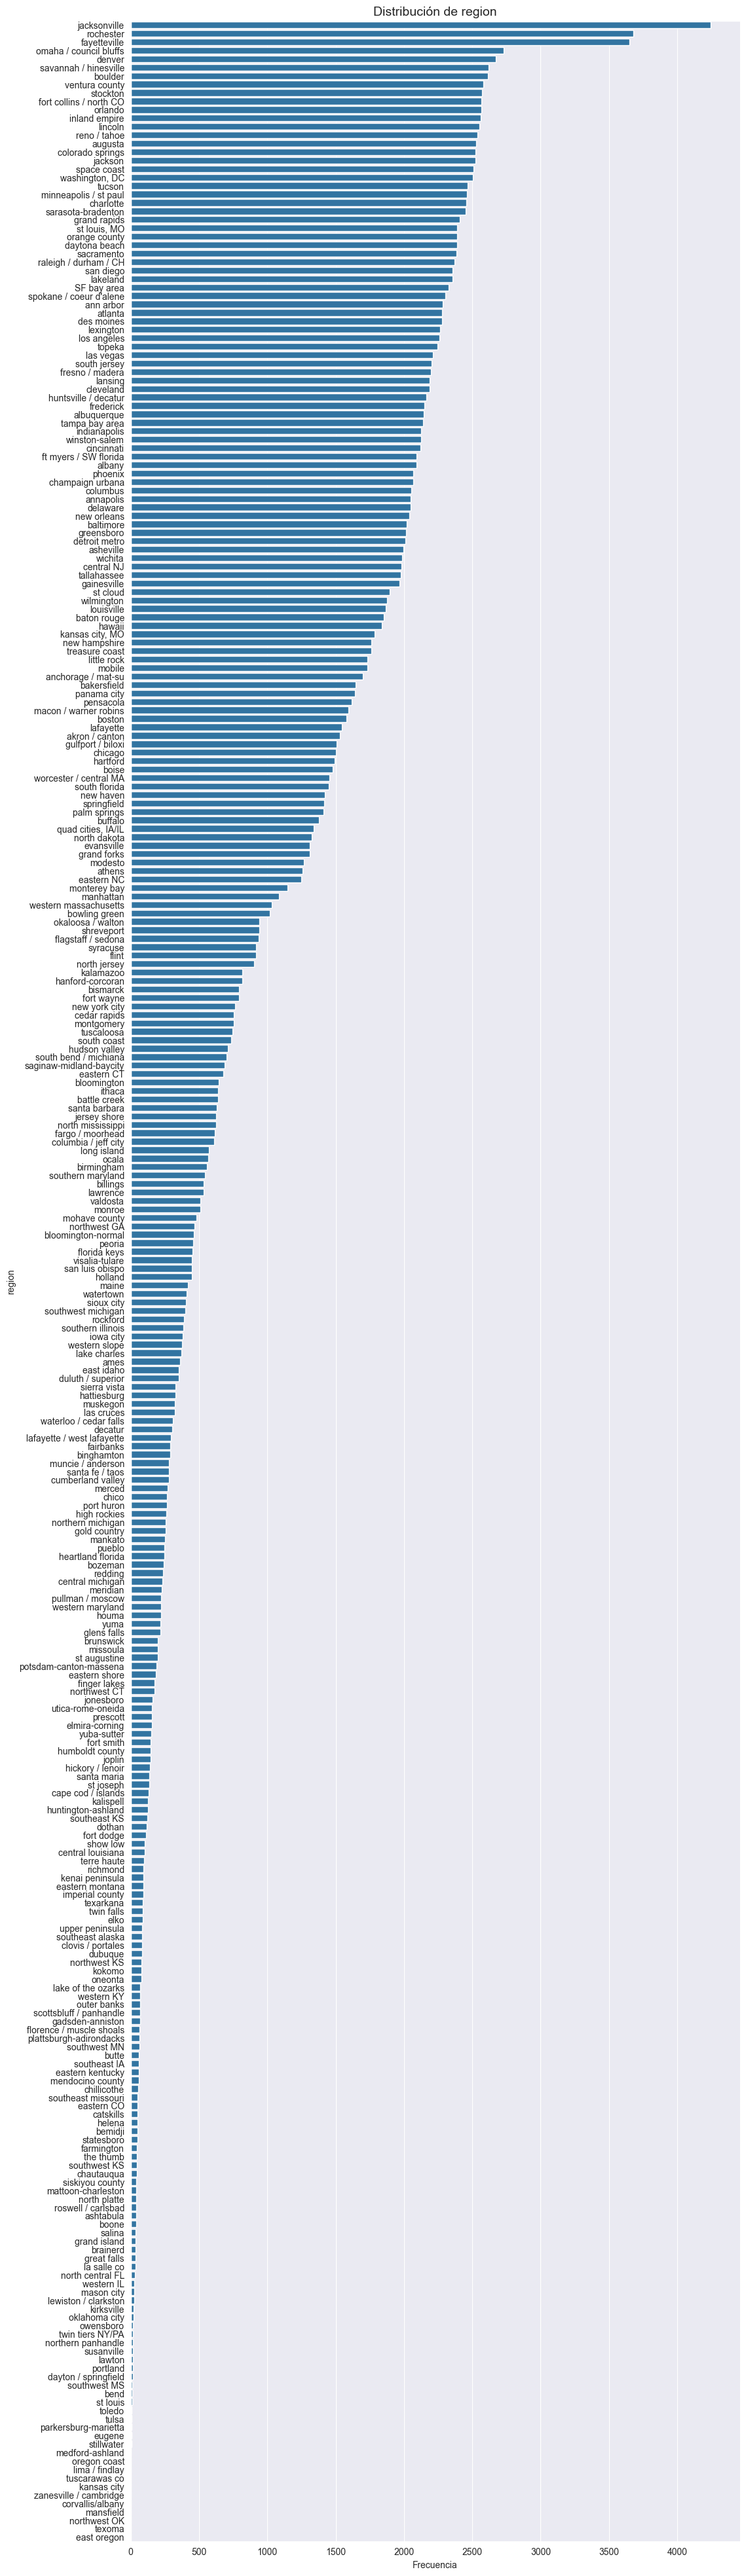

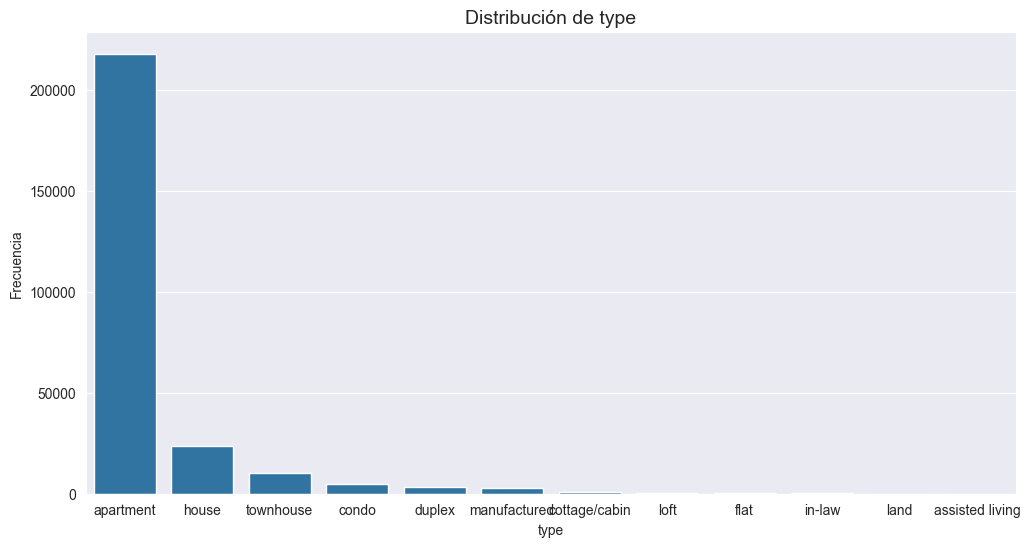

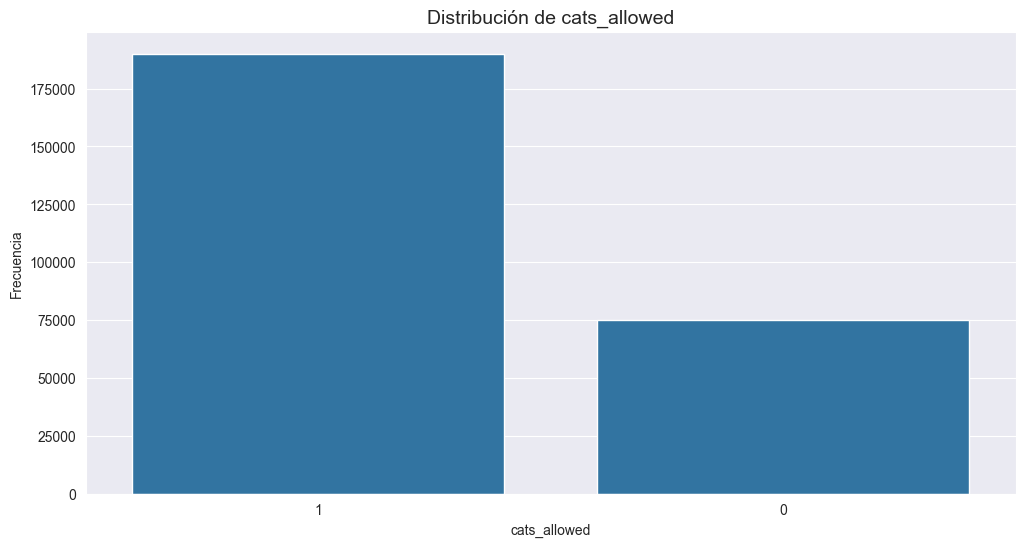

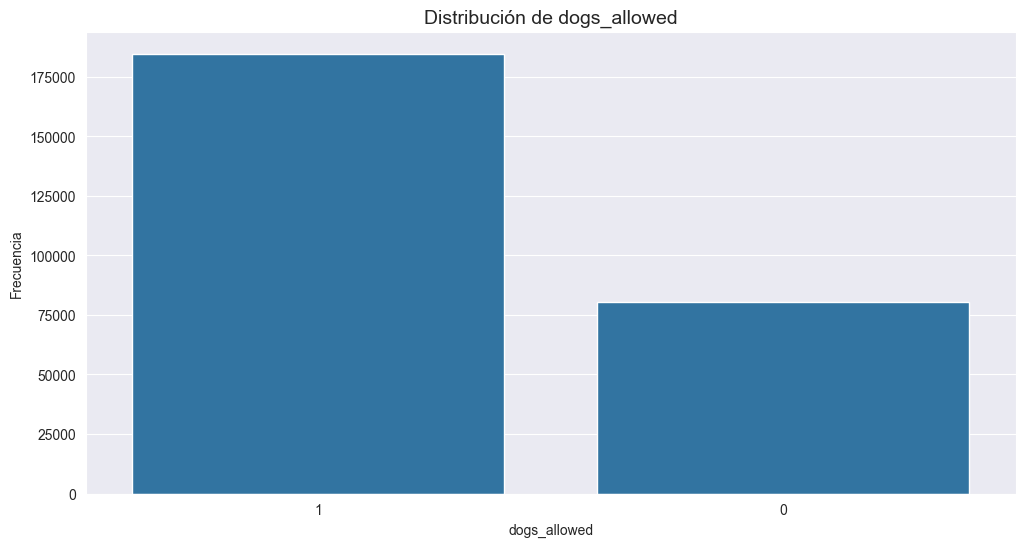

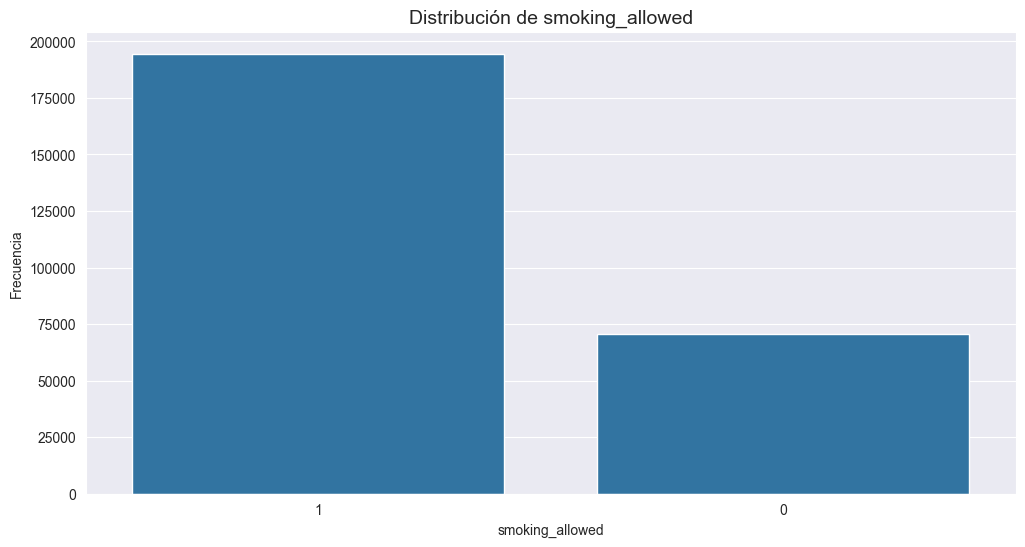

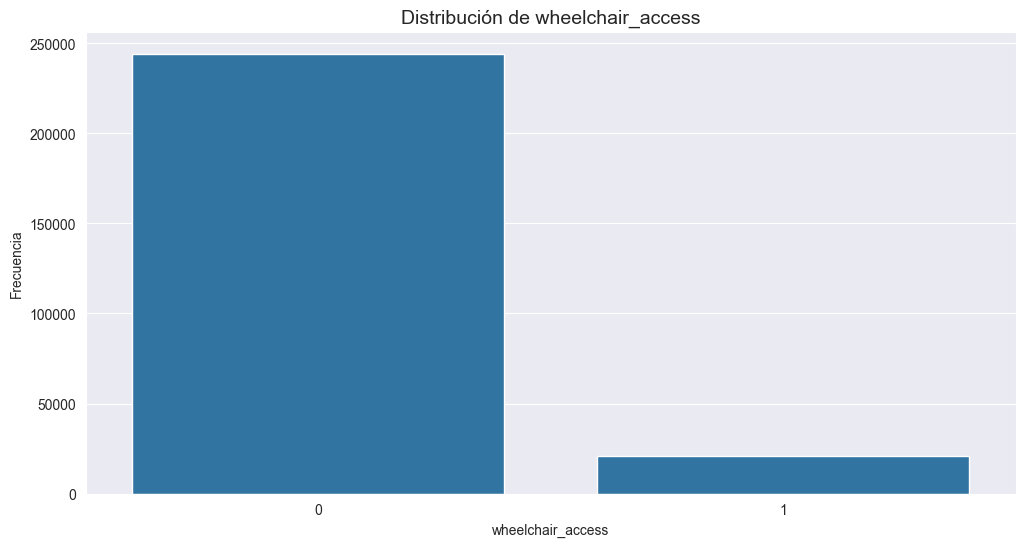

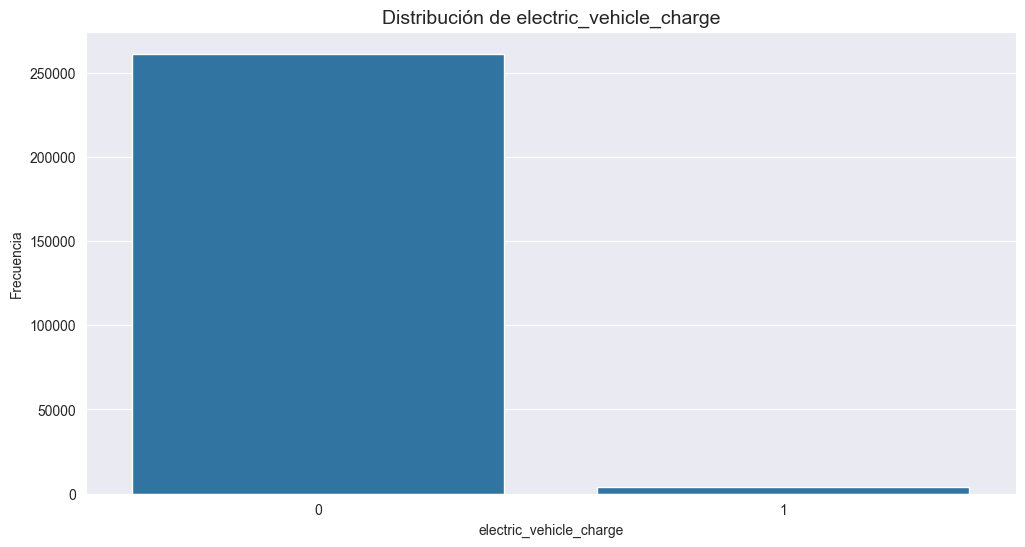

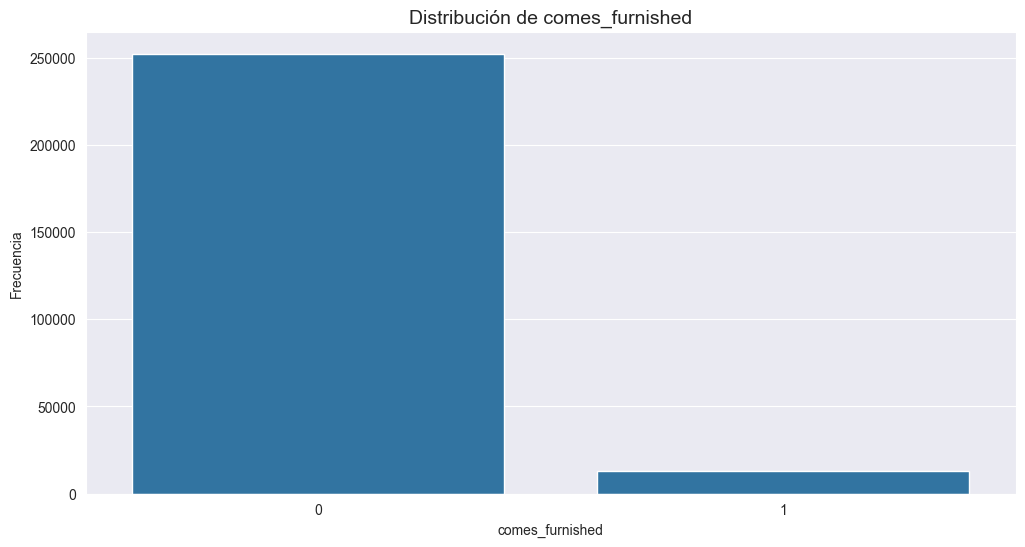

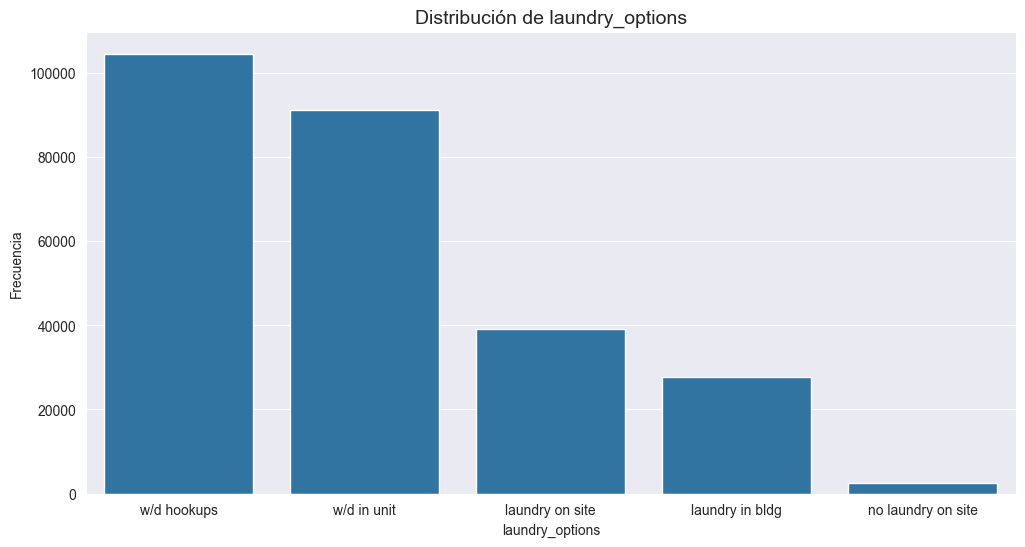

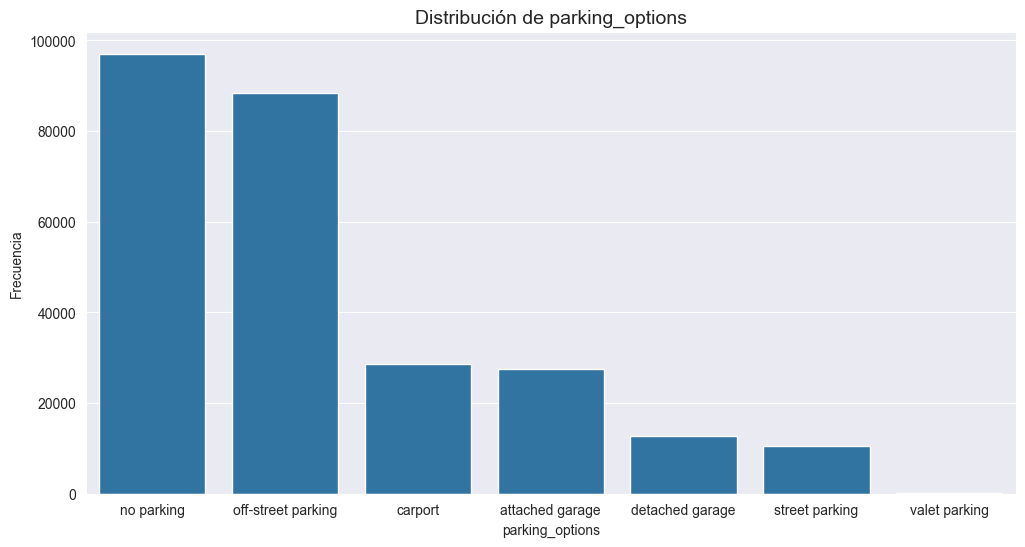

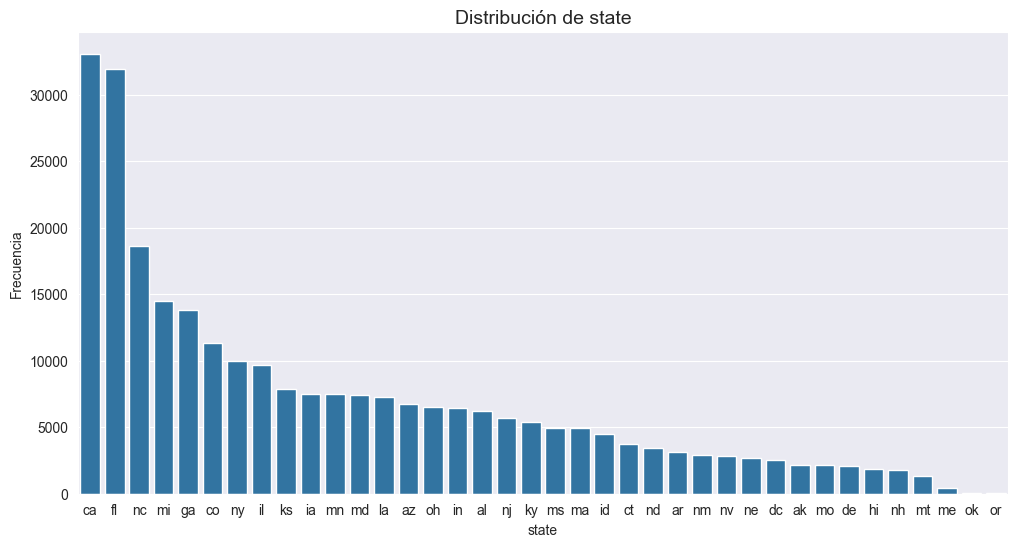

In [41]:
for var in vars_cat:
    order = data[var].value_counts().index
    if var == "region":
        plt.figure(figsize=(12, 50))
        sns.countplot(data=data, y=var, order=order)
        plt.title(f'Distribución de {var}', fontsize=14)
        plt.xlabel('Frecuencia')
        plt.ylabel(var)

    else:
        plt.figure(figsize=(12, 6))
        sns.countplot(data=data, x=var, order=order)
        plt.title(f'Distribución de {var}', fontsize=14)
        plt.xlabel(var)
        plt.ylabel('Frecuencia')
    plt.show()

- **Distribución de region**: Las tres ciudades con mayor frecuencia de propiedades son **Jacksonville, Rochester y Fayette**. Esto sugiere que estos lugares tienen una mayor oferta de vivienda en comparación con otras regiones.

- **Distribución de type**: Los **apartamentos (apartment)** son el tipo de vivienda más frecuente, con más de **200,000 registros**, seguidos por las **casas (house)** y las **casas adosadas (townhouse)**.

- **Distribución de cats_allowed**: Hay **más propiedades que permiten gatos** en comparación con aquellas que no los aceptan. Esto sugiere que muchos propietarios son flexibles con los inquilinos que tienen gatos como mascotas.

- **Distribución de dogs_allowed**: De manera similar a los gatos, hay **más propiedades que permiten perros**. Esto indica que muchas viviendas en alquiler son pet-friendly.

- **Distribución de smoking_allowed**: La mayoría de las propiedades **permiten fumar**, lo que puede reflejar una regulación más flexible en ciertas regiones o tipos de viviendas.

- **Distribución de wheelchair_access**: **Muy pocas propiedades cuentan con acceso para sillas de ruedas**, lo que indica que la oferta de viviendas accesibles es limitada.

- **Distribución de electric_vehicle_charge**: **Son escasas las propiedades con estaciones de carga para vehículos eléctricos**, lo que sugiere que esta infraestructura aún no está ampliamente disponible en el mercado inmobiliario.

- **Distribución de comes_furnished**: **Pocas viviendas están amuebladas**, lo que indica que la mayoría de las propiedades se alquilan sin mobiliario, y los inquilinos deben encargarse de equiparlas.

- **Distribución de laundry_options**: La mayoría de las viviendas cuentan con **conexiones para lavadora y secadora (w/d hookups)** o incluyen **lavadora y secadora en la unidad (w/d in unit)**, mientras que las opciones de lavandería compartida son menos frecuentes. Solo una pequeña proporción de las propiedades **no tiene acceso a lavandería** en el sitio. Esto sugiere que la mayoría de las viviendas en el dataset priorizan la comodidad en cuanto a las opciones de lavado de ropa.

- **Distribución de parking_options**: La mayoría de las propiedades **no cuentan con estacionamiento (`no parking`)**, lo que indica que muchos inmuebles no ofrecen este servicio o dependen de estacionamientos externos. La segunda opción más frecuente es **`off-street parking`**, lo que sugiere que muchas viviendas tienen estacionamiento privado fuera de la vía pública, como espacios asignados en condominios o estacionamientos compartidos.

  Las opciones como **`carport` y `attached garage`** tienen frecuencias intermedias, indicando que un porcentaje de viviendas cuenta con garajes techados, ya sea adjuntos a la vivienda o con estructuras independientes.

  Las opciones menos comunes incluyen **`detached garage` y `street parking`**, lo que sugiere que relativamente pocas propiedades tienen garajes separados o dependen del estacionamiento en la calle.

- **Distribución de state**: Los estados con mayor frecuencia de propiedades en el dataset son **California (CA) y Florida (FL)**, con más de **30,000 registros cada uno**. Esto sugiere que estos estados tienen un alto volumen de oferta de vivienda en comparación con el resto.

  Otros estados con una presencia significativa en la base de datos incluyen **Carolina del Norte (NC), Míchigan (MI), Georgia (GA) y Colorado (CO)**, todos con más de **10,000 registros**.

  A medida que avanzamos en la distribución, la frecuencia de propiedades por estado disminuye, reflejando una menor representación de viviendas en alquiler en lugares como **Oregón (OR), Oklahoma (OK) y Maine (ME)**, que presentan las menores cantidades de registros en el dataset.

  Esta distribución puede indicar una mayor demanda y oferta de alquiler en los estados con más registros, lo que podría estar relacionado con factores económicos, poblacionales o urbanísticos que hacen que estos lugares sean más activos en el mercado inmobiliario.



### Paso 9.2: Análisis Univeriado de Variables Númericas

In [42]:
data[vars_disc].value_counts()

beds  baths
1     1.0      78139
2     2.0      60112
      1.0      44257
3     2.0      29446
2     1.5      12245
               ...  
7     5.5          1
      8.5          1
      7.5          1
8     8.0          1
1000  35.0         1
Name: count, Length: 94, dtype: int64

#### Paso 9.2.1: Análisis Univeriado de Variables Discretas

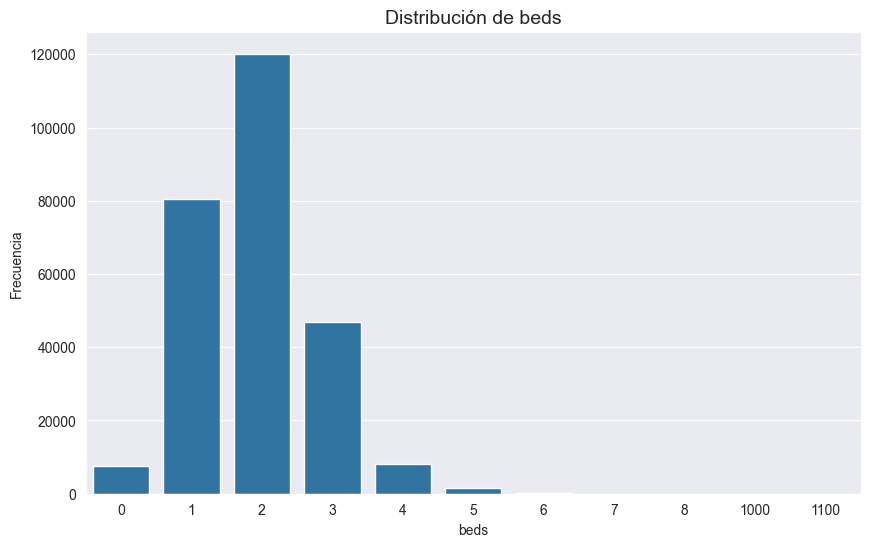

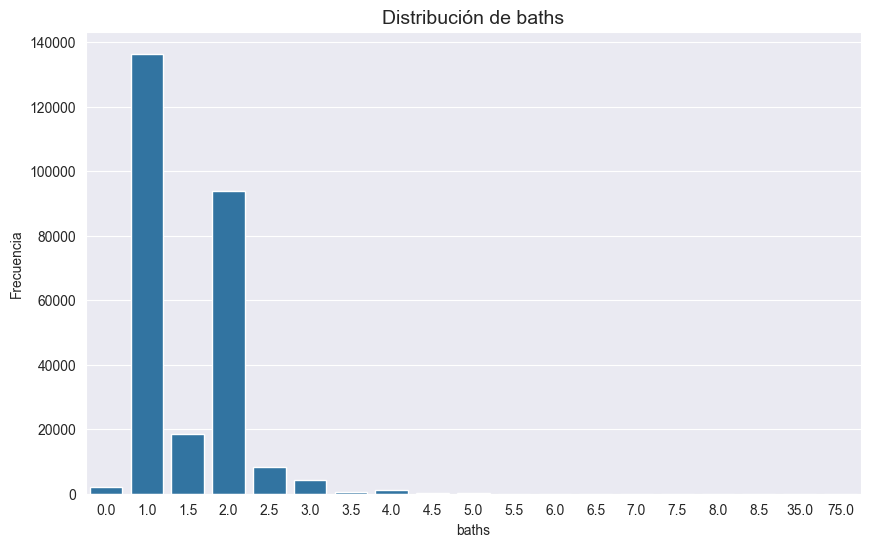

In [43]:
for var in vars_disc:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=data, x=var)
    plt.title(f'Distribución de {var}', fontsize=14)
    plt.xlabel(var)
    plt.ylabel('Frecuencia')
    plt.show()


- La gráfica **"Distribución de beds"** muestra la cantidad de camas en un conjunto de datos, donde la mayoría de las propiedades tienen 2 camas, seguidas por aquellas con 1 y 3 camas, con una frecuencia decreciente a medida que aumenta el número de camas. La distribución es asimétrica y presenta valores atípicos significativos, como registros con 1000 y 1100 camas, que podrían ser errores o casos especiales. En general, la mayoría de las observaciones se concentran entre 1 y 3 camas, mientras que las propiedades con más camas son menos comunes. El sesgo observado en esta distribución es **sesgo a la derecha (positivamente sesgada)**, ya que hay una cola extendida hacia valores altos.

- La gráfica **"Distribución de baths"** muestra la cantidad de baños en un conjunto de datos, donde la mayoría de las propiedades tienen 1 baño, seguidas por aquellas con 2 baños, con una frecuencia decreciente a medida que aumenta el número de baños. La distribución es asimétrica y presenta valores atípicos significativos, como registros con 35 y 75 baños, que podrían ser errores o casos especiales. En general, la mayoría de las observaciones se concentran entre 1 y 2 baños, mientras que las propiedades con más baños son considerablemente menos comunes. El sesgo en esta distribución también es **sesgo a la derecha (positivamente sesgada)**, ya que la mayoría de los valores están concentrados en el extremo inferior, mientras que la cola se extiende hacia valores mayores.

#### Paso 9.2.2: Análisis Univeriado de Variables Continuas

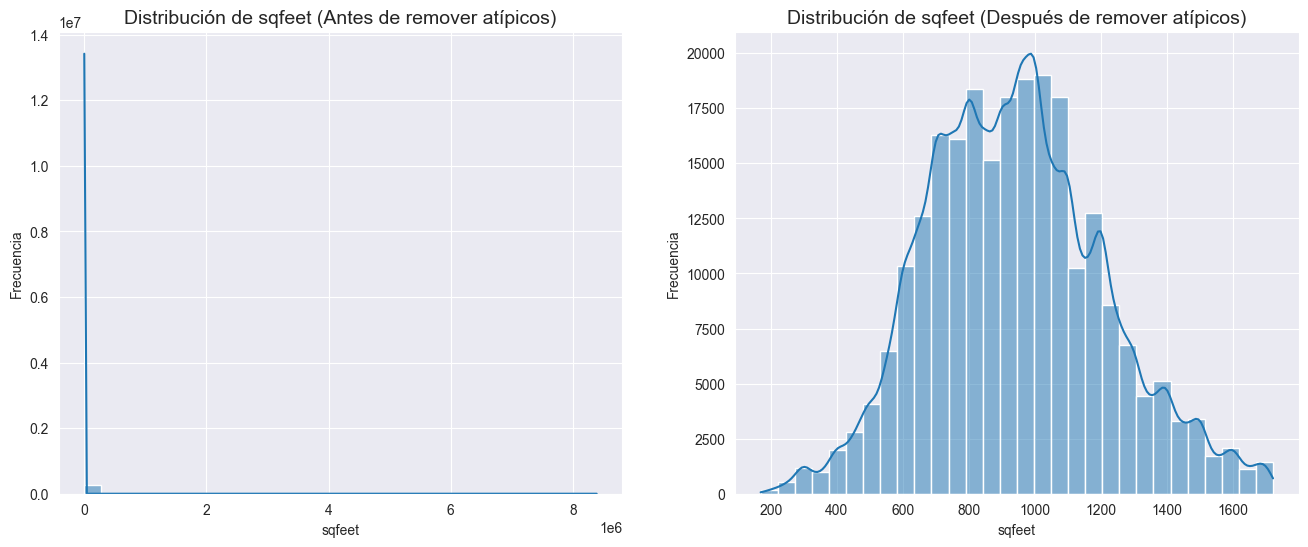

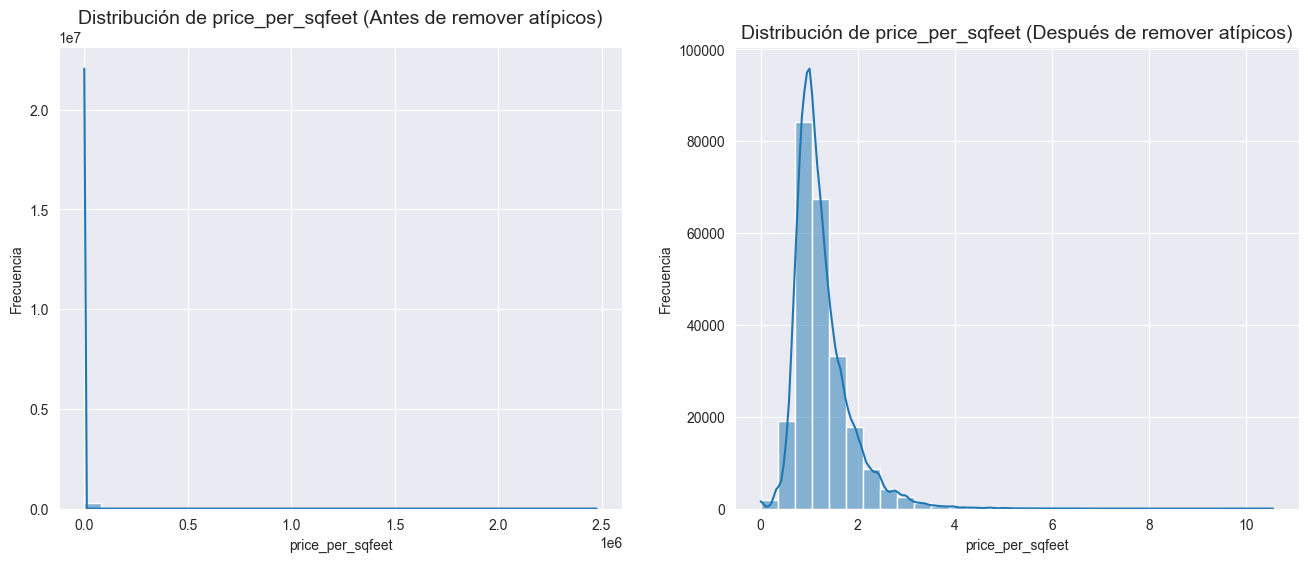

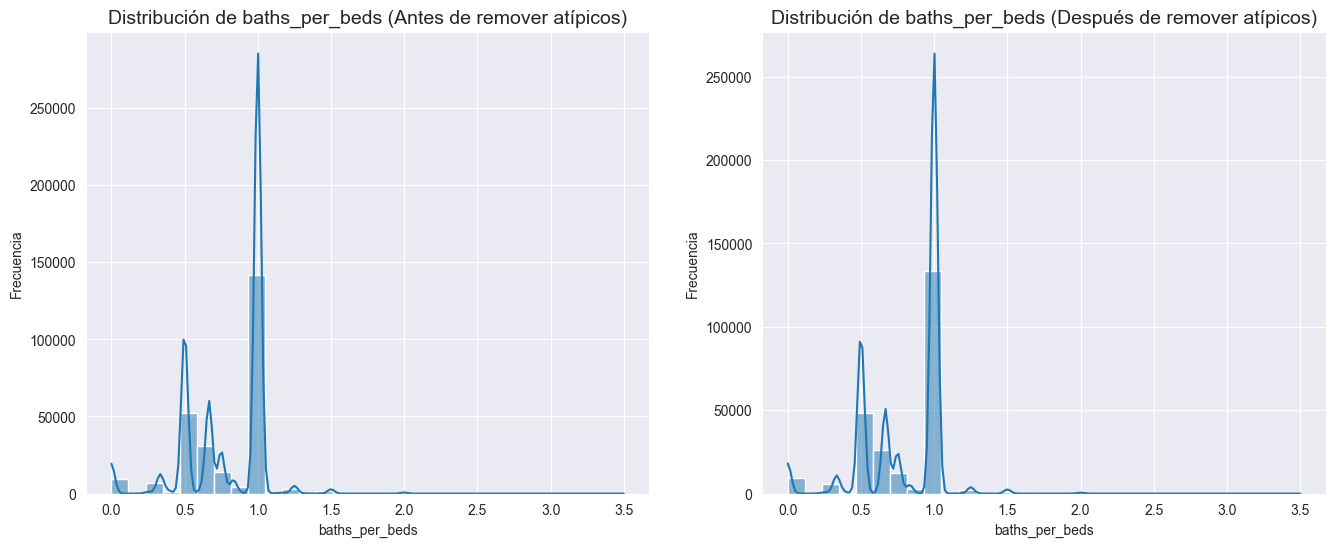

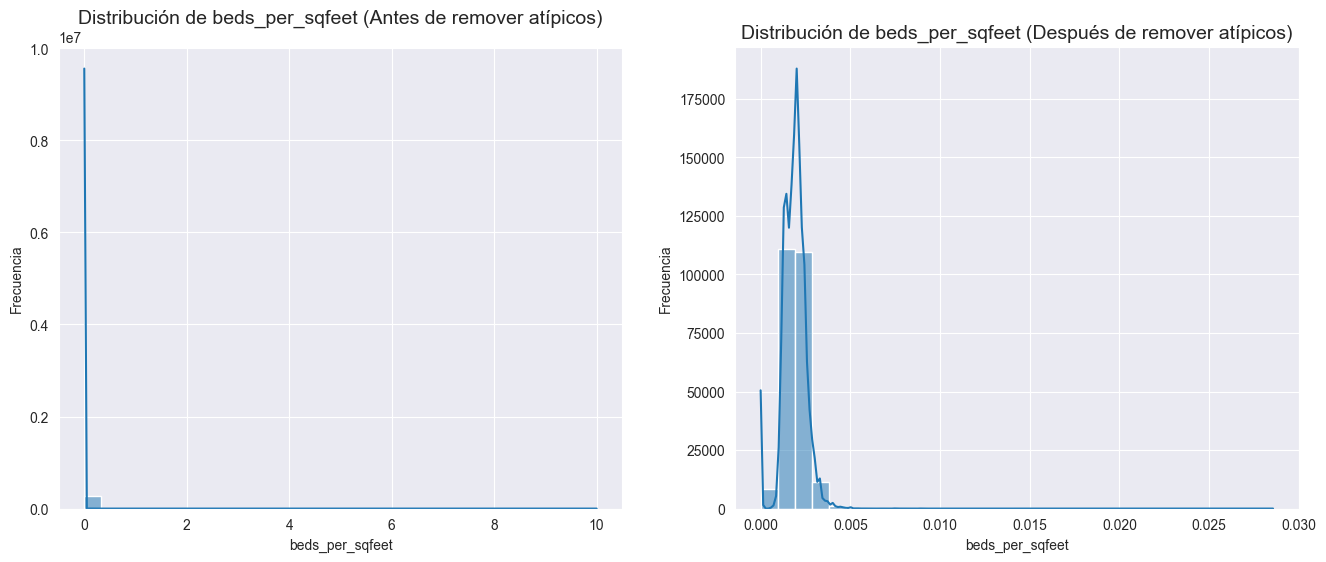

In [44]:
for var in vars_con:
    plt.figure(figsize=(16, 6))
    plt.subplot(1, 2, 1)
    sns.histplot(data[var], kde=True, bins=30)
    plt.title(f'Distribución de {var} (Antes de remover atípicos)', fontsize=14)
    plt.xlabel(var)
    plt.ylabel('Frecuencia')

    plt.subplot(1, 2, 2)
    sns.histplot(data_cleaned[var], kde=True, bins=30)
    plt.title(f'Distribución de {var} (Después de remover atípicos)', fontsize=14)
    plt.xlabel(var)
    plt.ylabel('Frecuencia')
    plt.show()

### Paso 9.3: Análisis Univeriado del Variable Objetivo

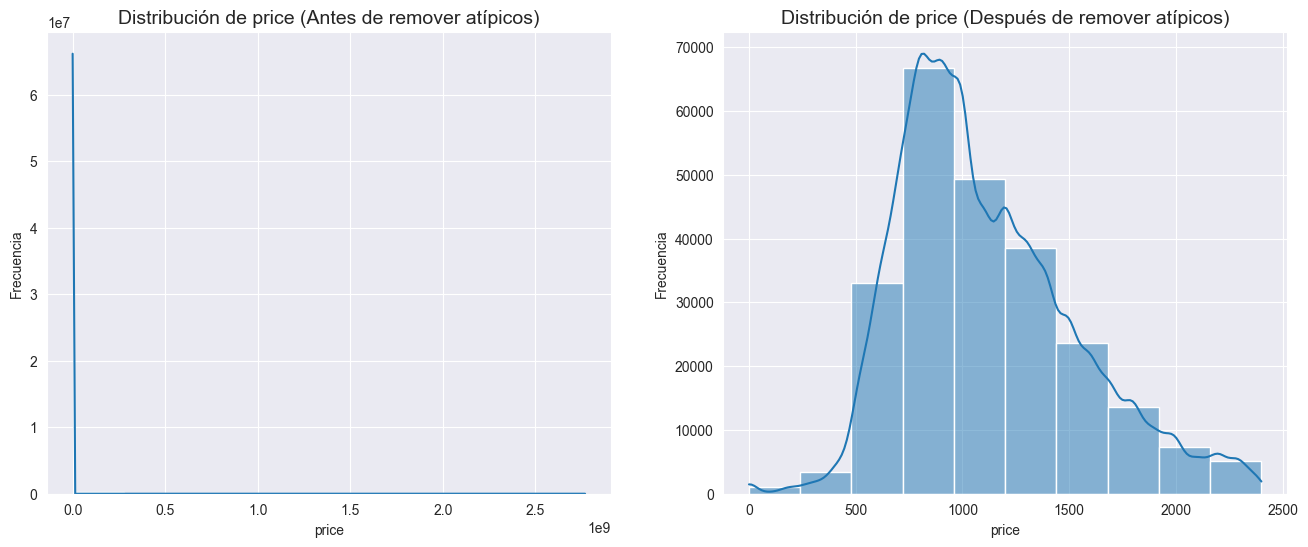

In [45]:
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
sns.histplot(data[target_var_num], kde=True, bins=10)
plt.title(f'Distribución de {target_var_num} (Antes de remover atípicos)', fontsize=14)
plt.xlabel(target_var_num)
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(data_cleaned[target_var_num], kde=True, bins=10)
plt.title(f'Distribución de {target_var_num} (Después de remover atípicos)', fontsize=14)
plt.xlabel(target_var_num)
plt.ylabel('Frecuencia')
plt.show()


- La gráfica **"Distribución de price (Antes de remover atípicos)"** muestra la distribución de precios en el conjunto de datos original. Sin embargo, debido a la presencia de valores extremadamente altos, la mayoría de los datos quedan comprimidos en el extremo izquierdo del gráfico, sin una visualización clara de la distribución real. Este efecto sugiere la existencia de valores atípicos severos que distorsionan la escala, lo que impide apreciar los precios más comunes en la muestra.

- La gráfica **"Distribución de price (Después de remover atípicos)"** muestra la distribución de precios tras la eliminación de valores atípicos. En esta versión, la forma de la distribución se vuelve mucho más clara, con la mayoría de los precios concentrados entre aproximadamente 500 y 1500. A pesar de la reducción de la escala, la distribución sigue presentando un **sesgo positivo (hacia la derecha)**, aunque de forma menos extrema, lo que indica que aún existen precios elevados en comparación con la mayoría de los valores, pero sin los extremos del gráfico original.

## Paso 10: Análisis Bivariado

### Paso 10.1: Análisis Bivariado: Relación con el Precio

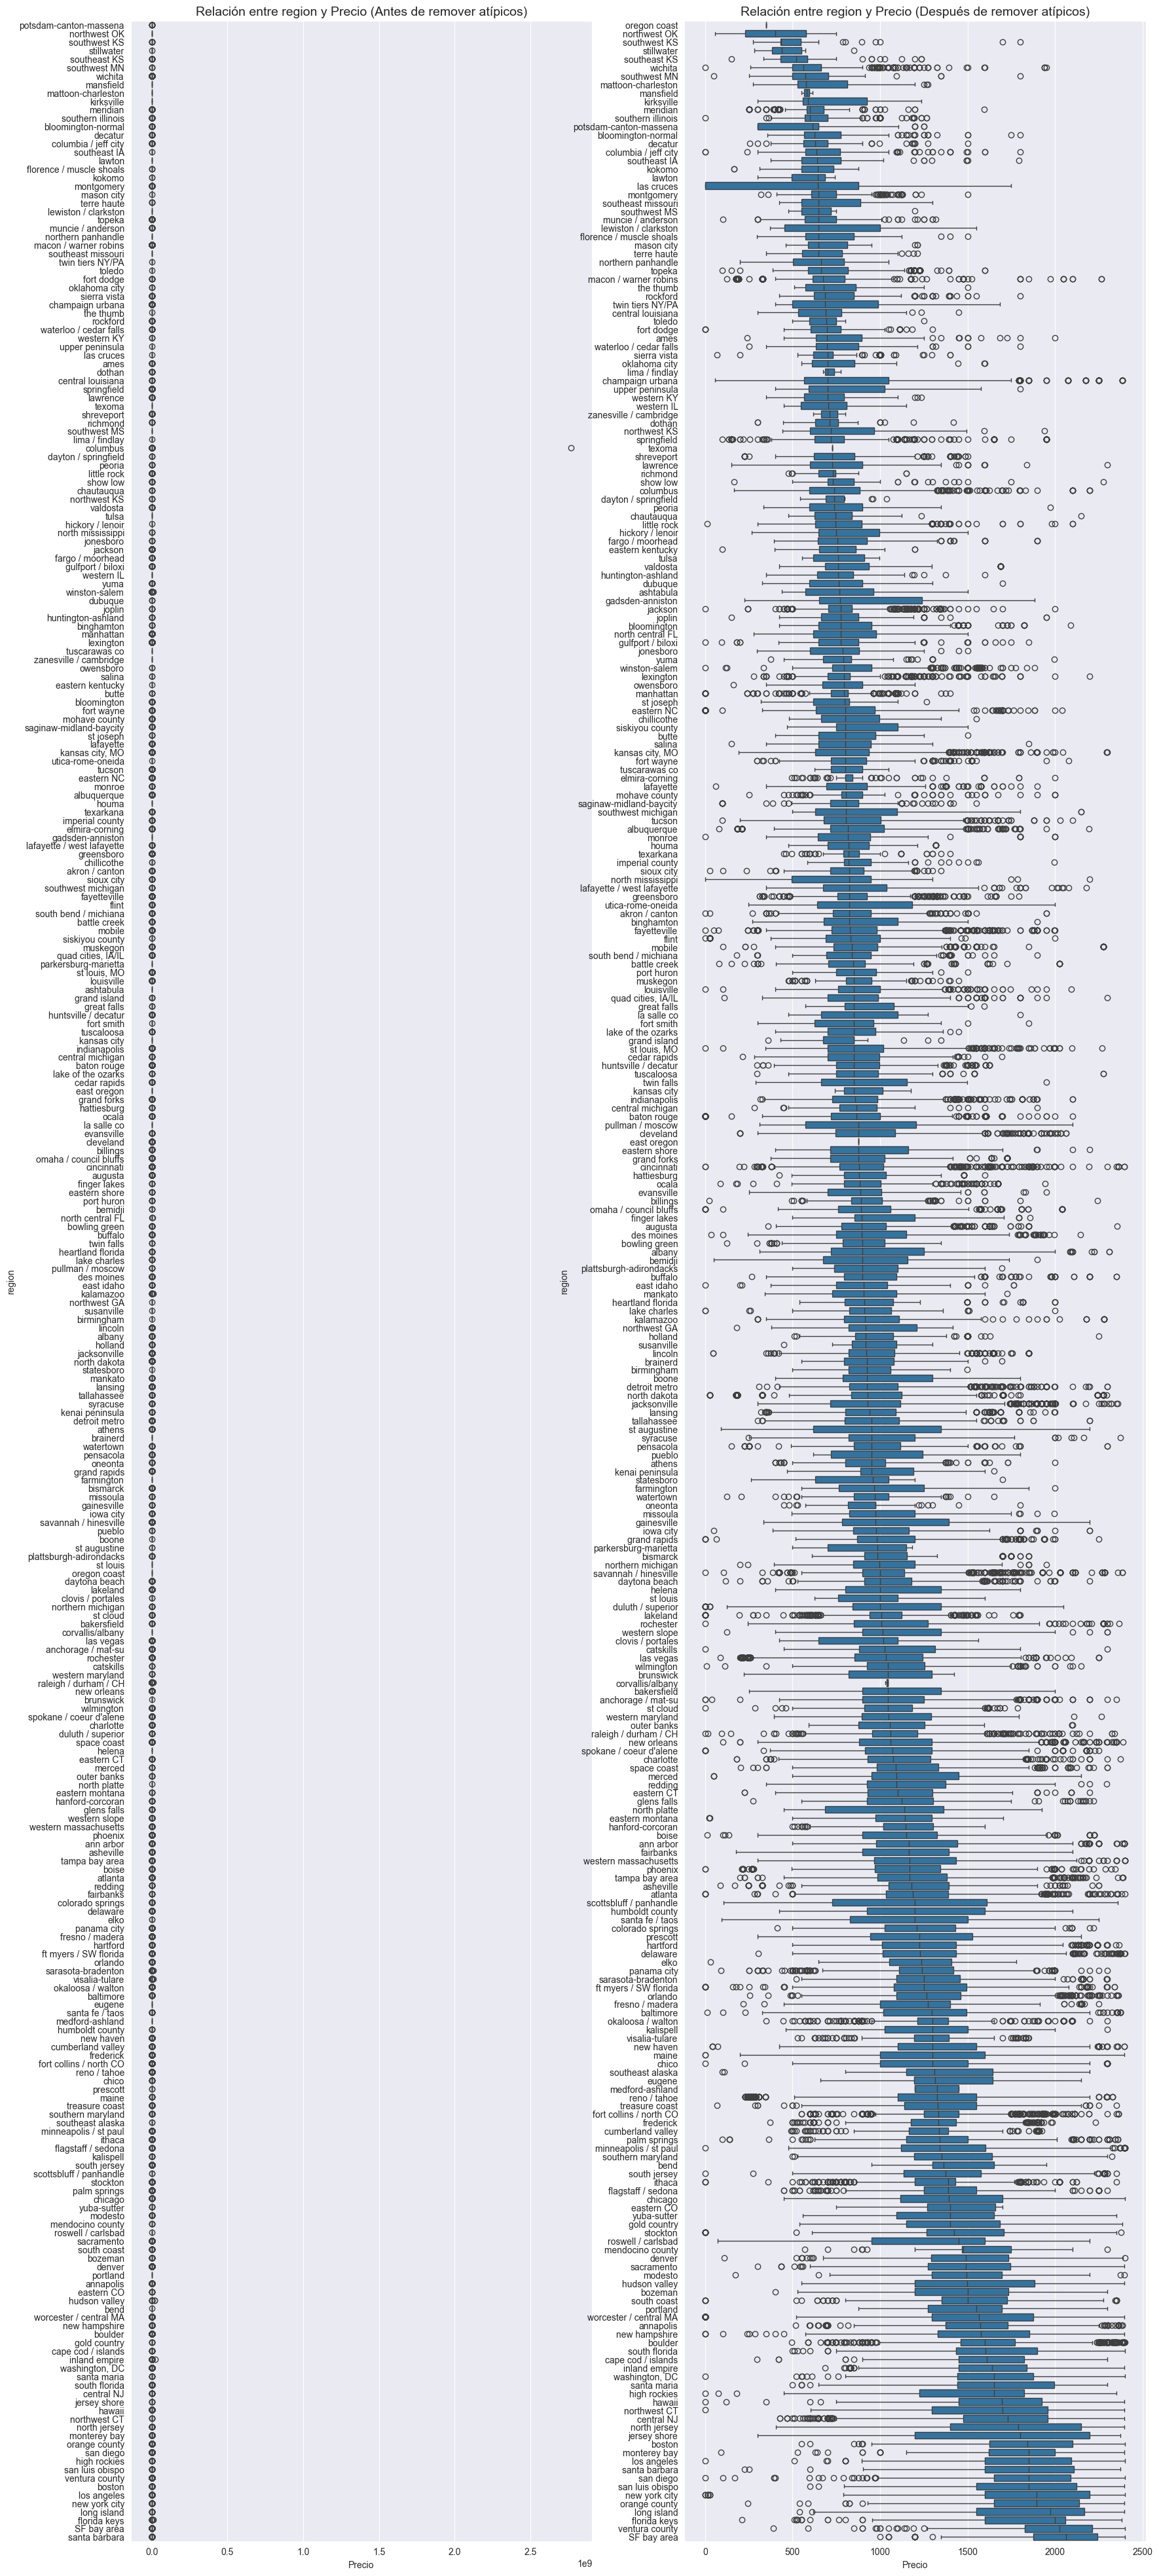

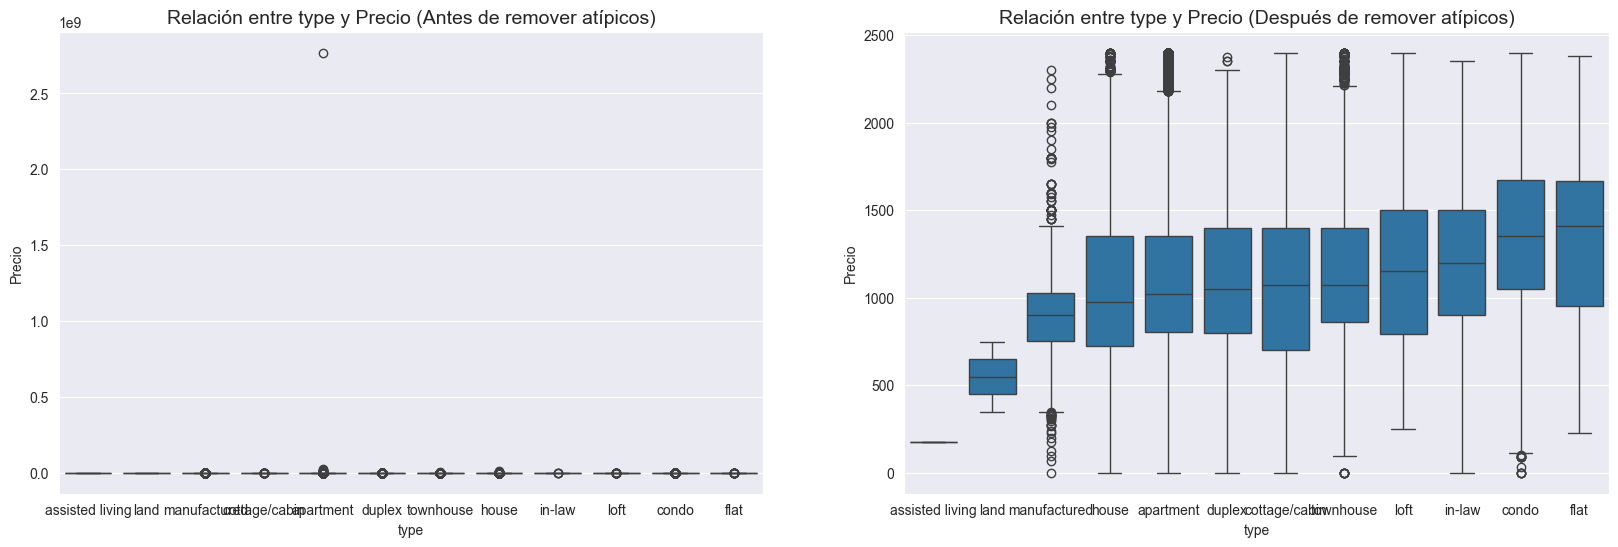

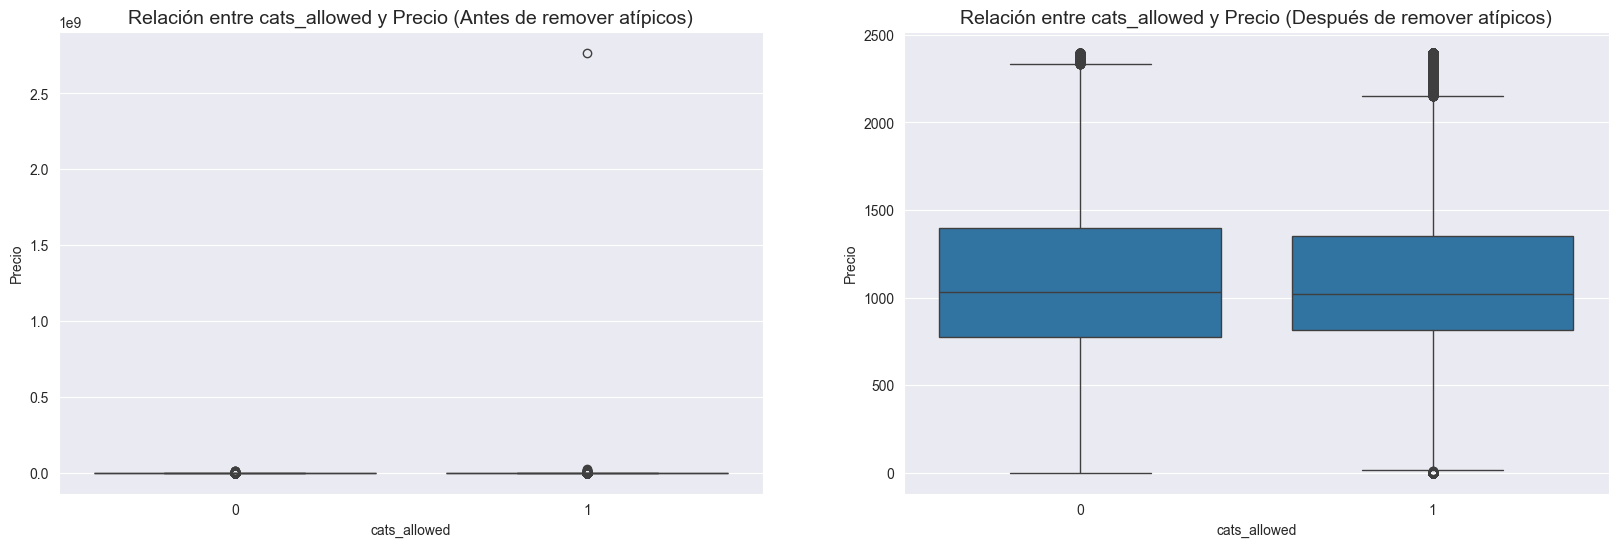

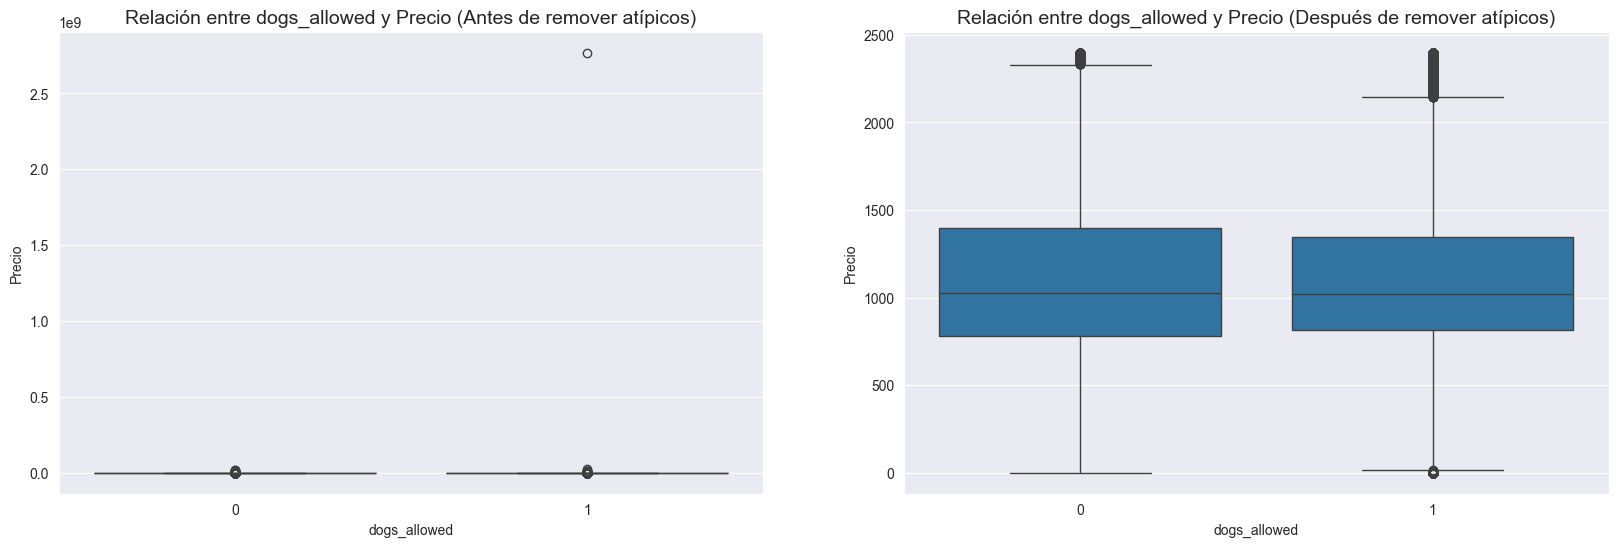

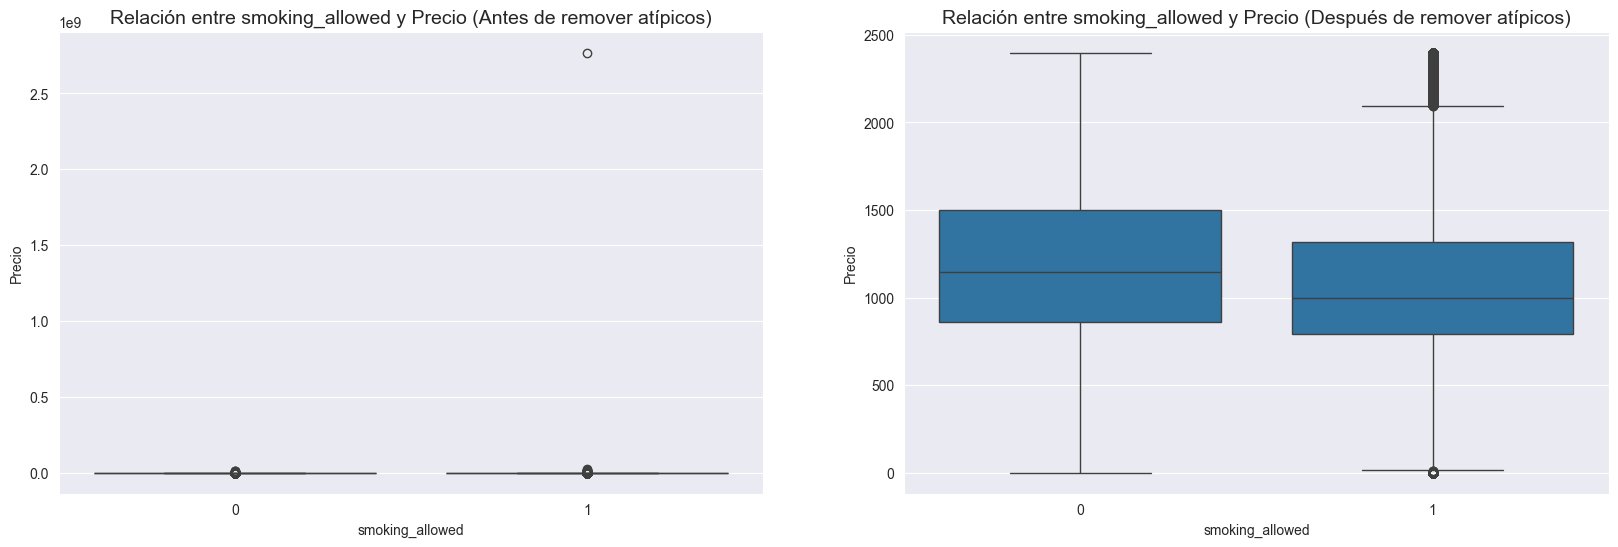

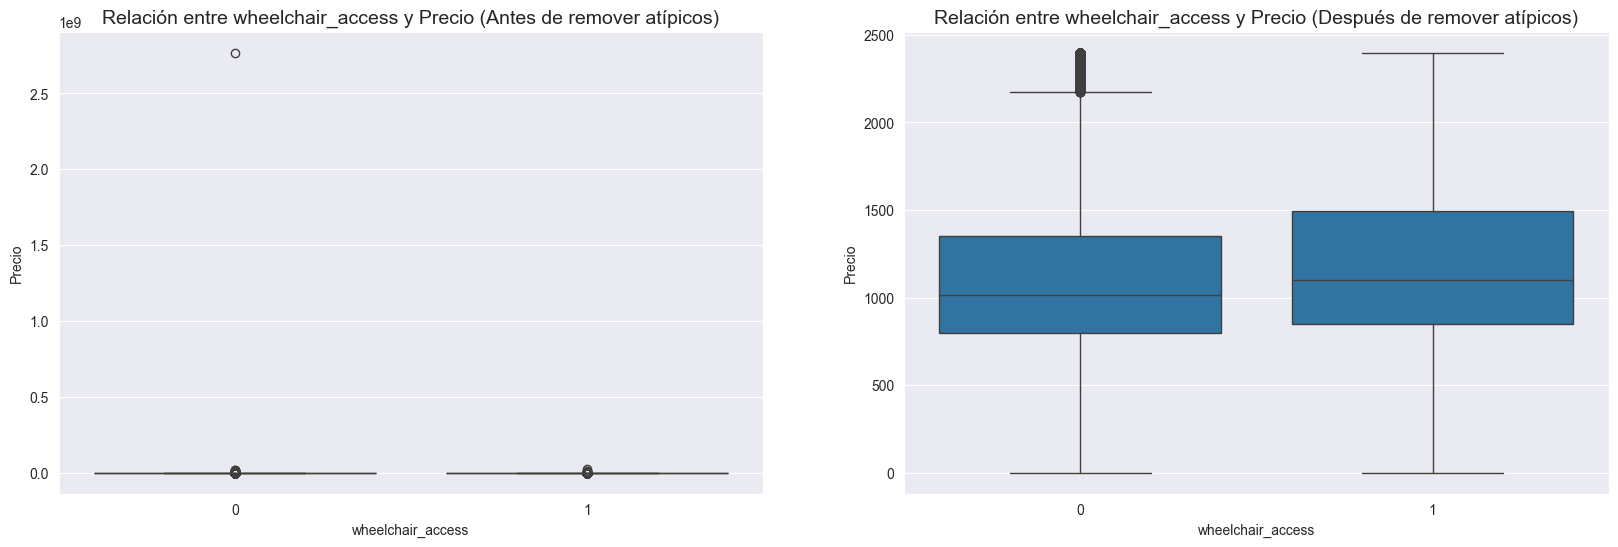

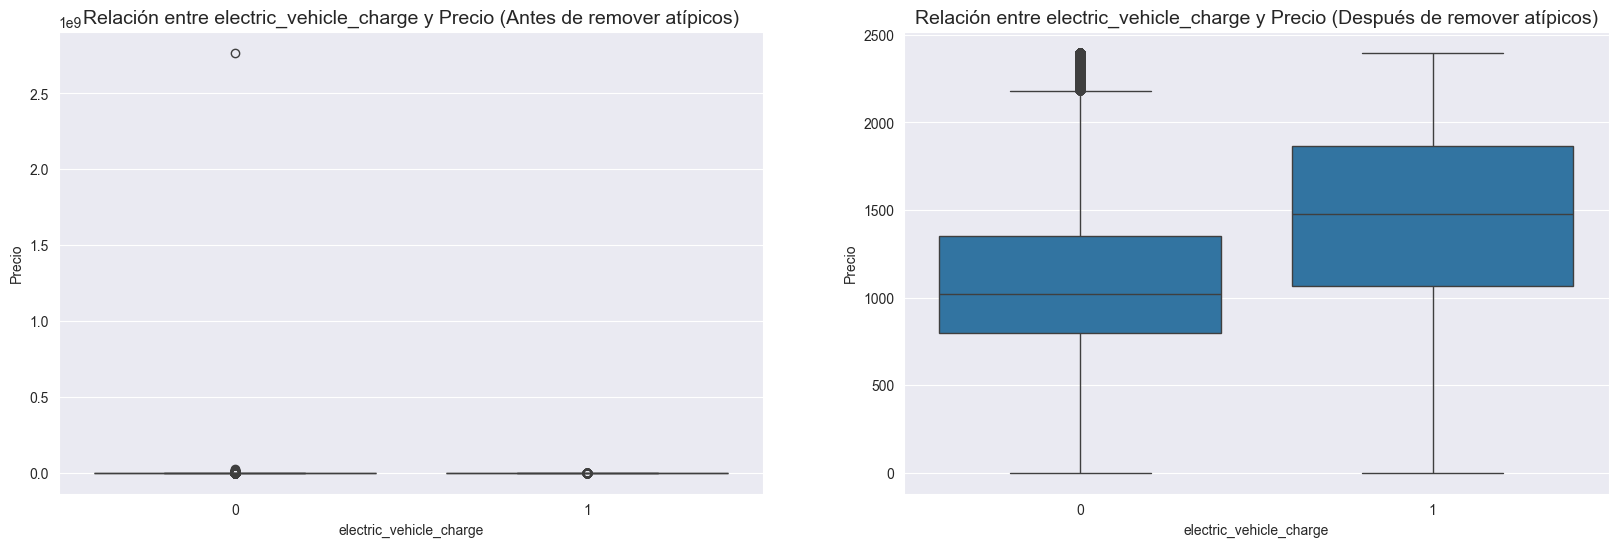

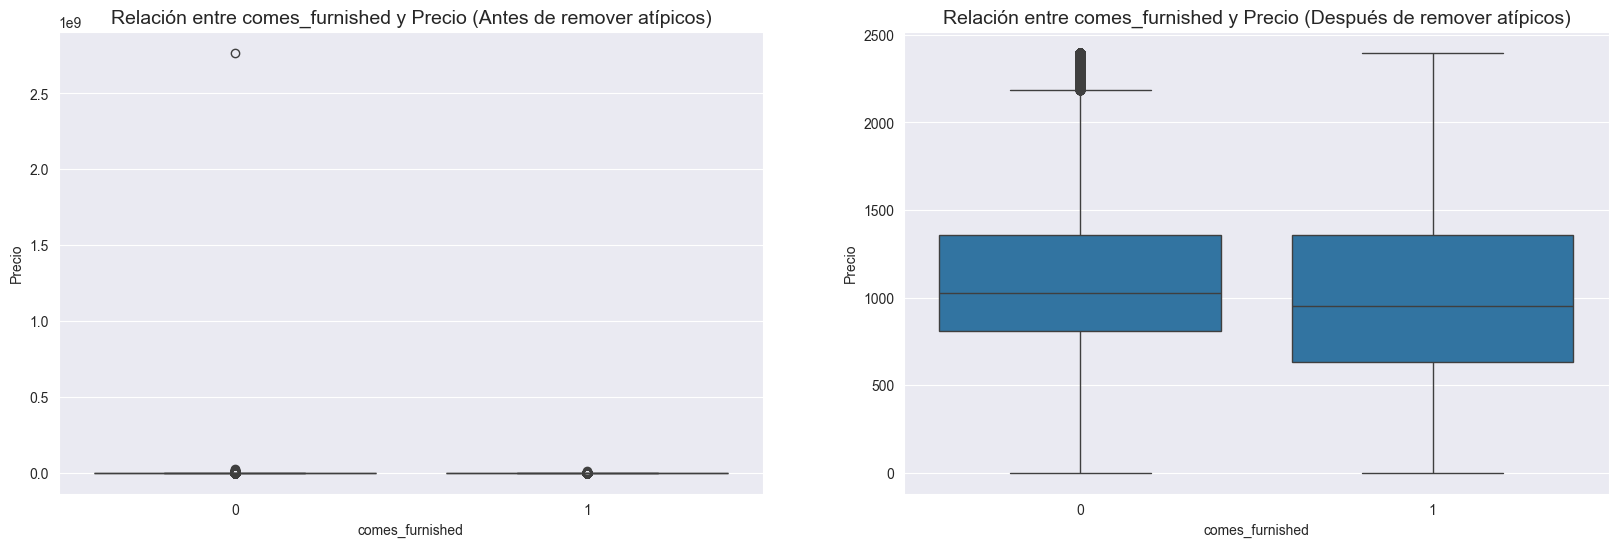

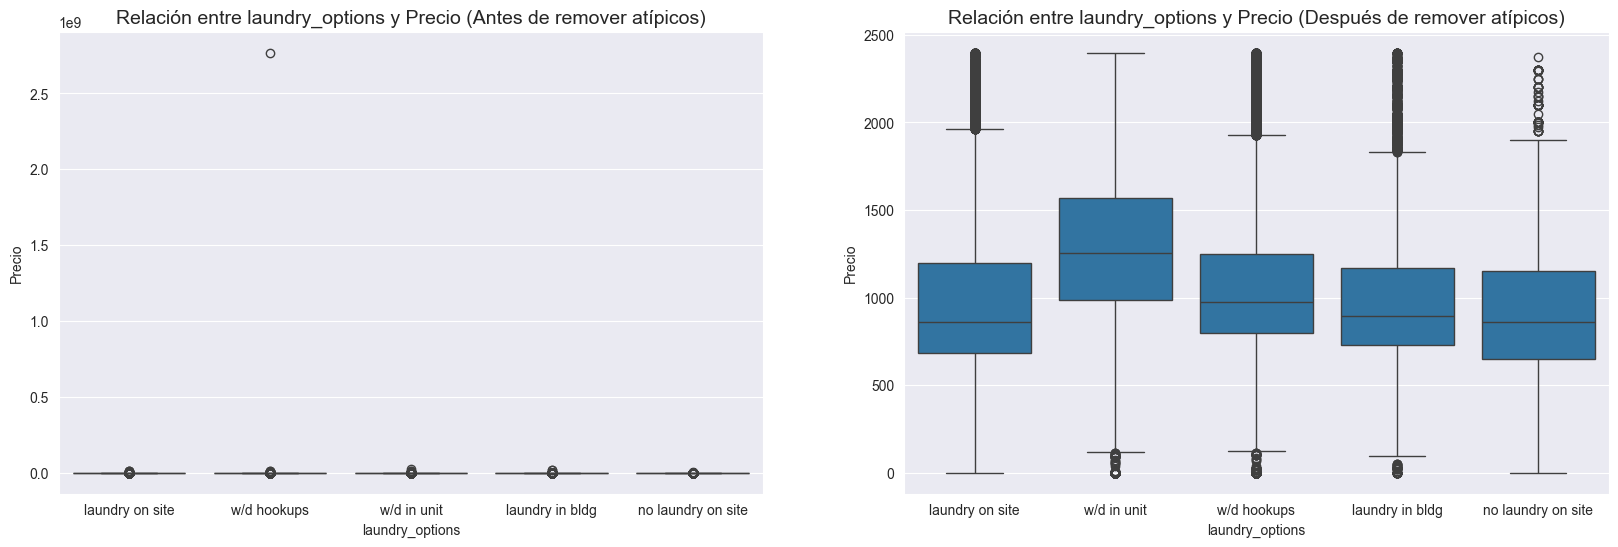

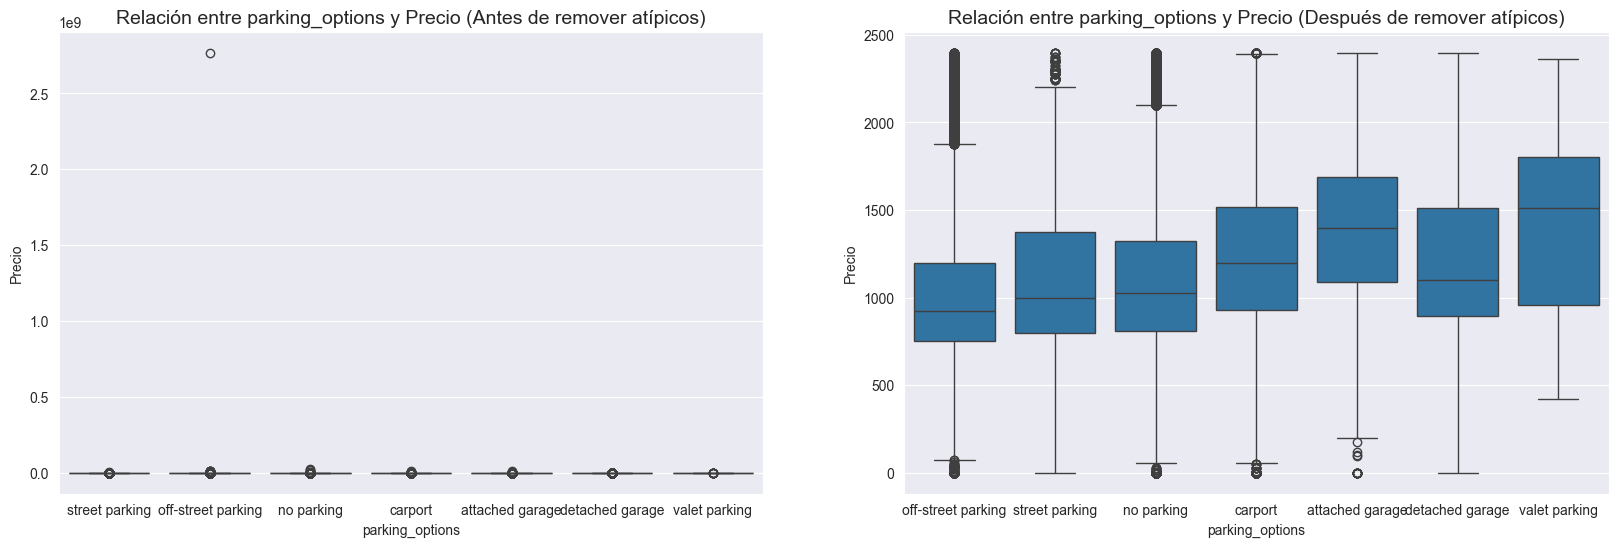

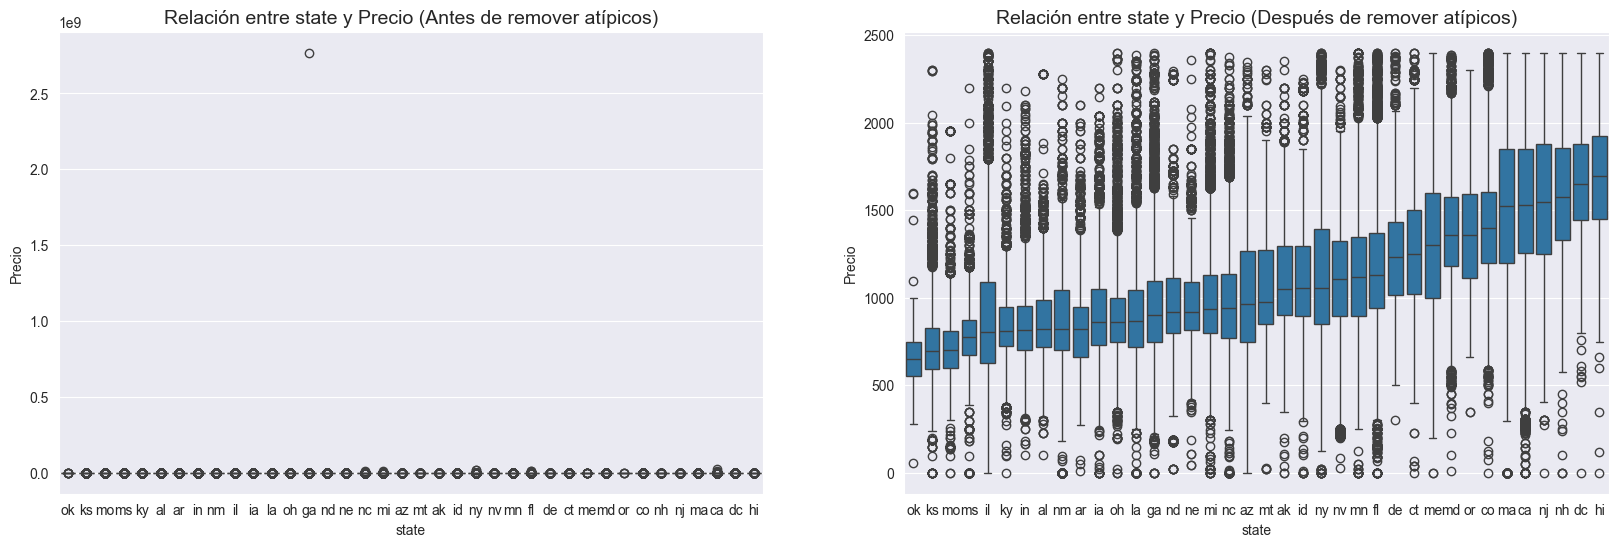

In [46]:
for col in vars_cat:
    if col == "region":
        # Sort regions by median price before plotting
        sorted_regions = data.groupby("region")[target_var_num].median().sort_values()

        plt.figure(figsize=(20, 50))  # Larger figure for better readability
        plt.subplot(1, 2, 1)
        sns.boxplot(data=data, y=col, x=target_var_num, order=sorted_regions.index)  # Vertical & sorted
        plt.title(f'Relación entre {col} y Precio (Antes de remover atípicos)', fontsize=14)
        plt.xlabel('Precio')
        plt.ylabel(col)

        plt.subplot(1, 2, 2)
        sorted_regions_cleaned = data_cleaned.groupby("region")[target_var_num].median().sort_values()
        sns.boxplot(data=data_cleaned, y=col, x=target_var_num, order=sorted_regions_cleaned.index)  # Vertical & sorted
        plt.title(f'Relación entre {col} y Precio (Después de remover atípicos)', fontsize=14)
        plt.xlabel('Precio')
        plt.ylabel(col)
        plt.show()

    elif col in ["type", "state"]:  # Sort "type" and "state" by median price
        sorted_categories = data.groupby(col)[target_var_num].median().sort_values()

        plt.figure(figsize=(20, 6))
        plt.subplot(1, 2, 1)
        sns.boxplot(data=data, x=col, y=target_var_num, order=sorted_categories.index)  # Horizontal & sorted
        plt.title(f'Relación entre {col} y Precio (Antes de remover atípicos)', fontsize=14)
        plt.xlabel(col)
        plt.ylabel('Precio')

        sorted_categories_cleaned = data_cleaned.groupby(col)[target_var_num].median().sort_values()
        plt.subplot(1, 2, 2)
        sns.boxplot(data=data_cleaned, x=col, y=target_var_num, order=sorted_categories_cleaned.index)  # Horizontal & sorted
        plt.title(f'Relación entre {col} y Precio (Después de remover atípicos)', fontsize=14)
        plt.xlabel(col)
        plt.ylabel('Precio')
        plt.show()

    else:
        plt.figure(figsize=(20, 6))  # Standard size for other categories
        plt.subplot(1, 2, 1)
        sns.boxplot(data=data, x=col, y=target_var_num)  # Horizontal plot
        plt.title(f'Relación entre {col} y Precio (Antes de remover atípicos)', fontsize=14)
        plt.xlabel(col)
        plt.ylabel('Precio')

        plt.subplot(1, 2, 2)
        sns.boxplot(data=data_cleaned, x=col, y=target_var_num)  # Horizontal plot
        plt.title(f'Relación entre {col} y Precio (Después de remover atípicos)', fontsize=14)
        plt.xlabel(col)
        plt.ylabel('Precio')
        plt.show()


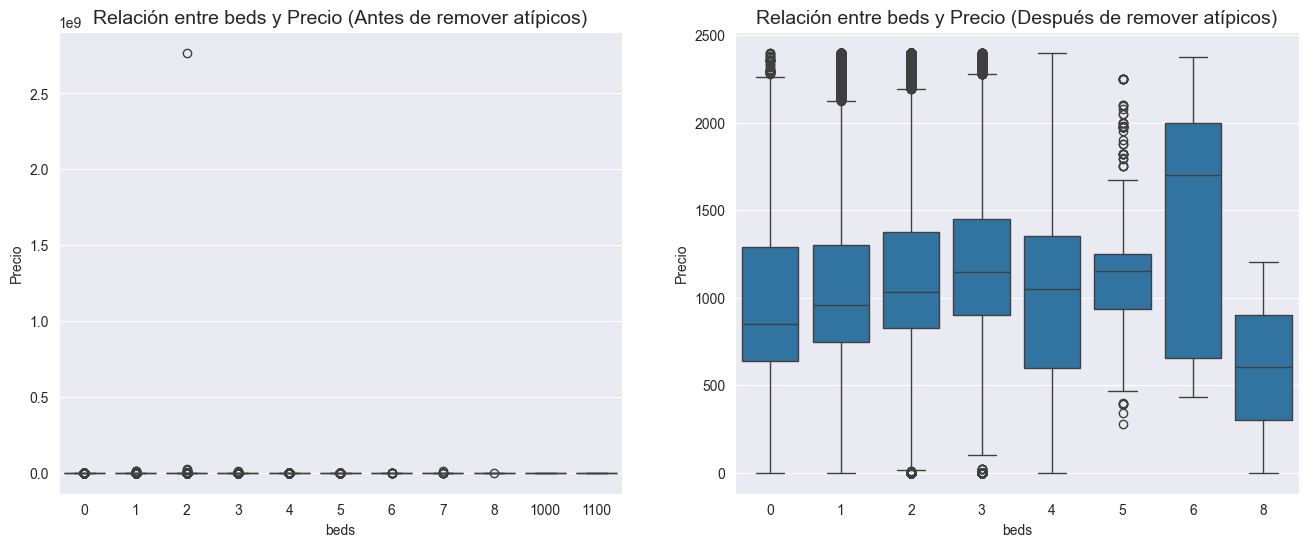

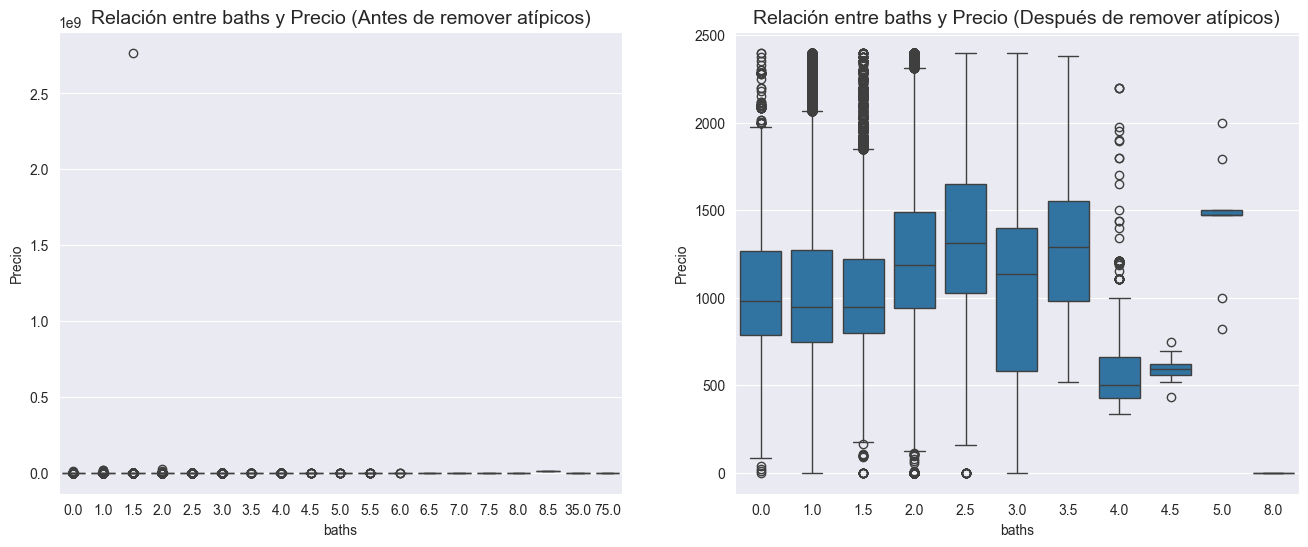

In [47]:
for col in vars_disc:
    plt.figure(figsize=(16, 6))
    plt.subplot(1, 2, 1)
    sns.boxplot(data=data, x=col, y=target_var_num)
    plt.title(f'Relación entre {col} y Precio (Antes de remover atípicos)', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Precio')

    plt.subplot(1, 2, 2)
    sns.boxplot(data=data_cleaned, x=col, y=target_var_num)
    plt.title(f'Relación entre {col} y Precio (Después de remover atípicos)', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Precio')
    plt.show()

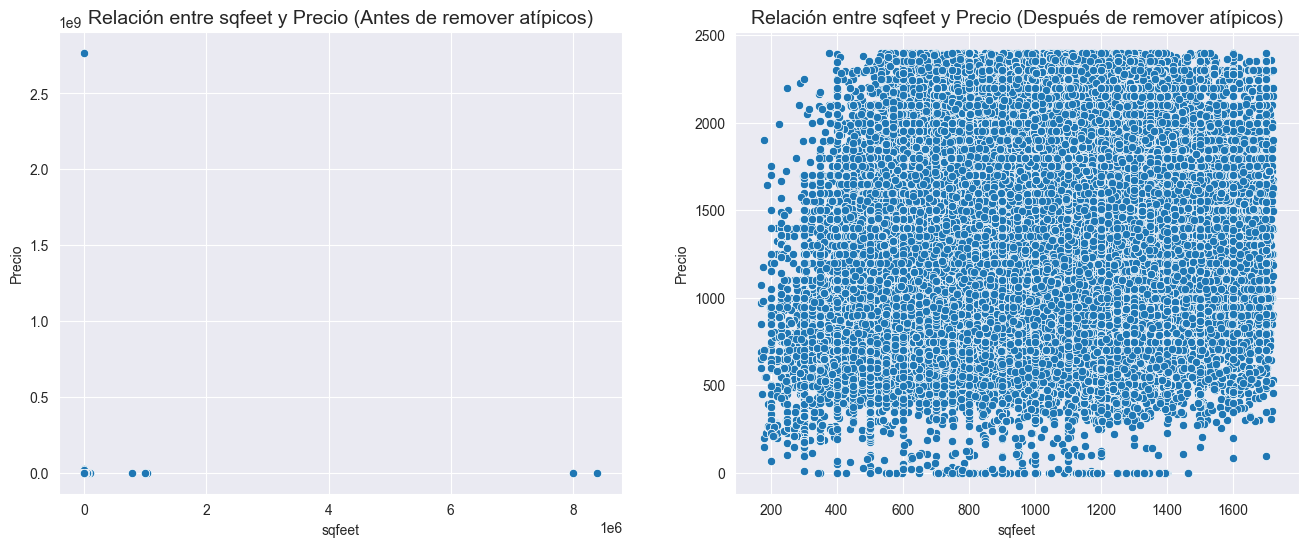

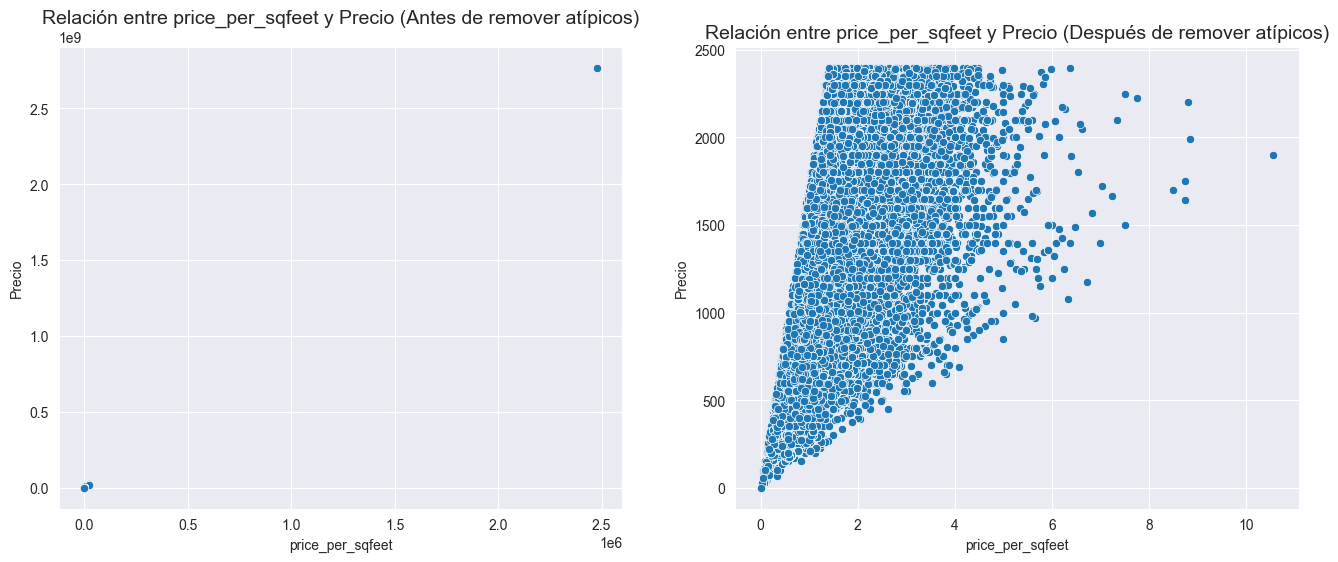

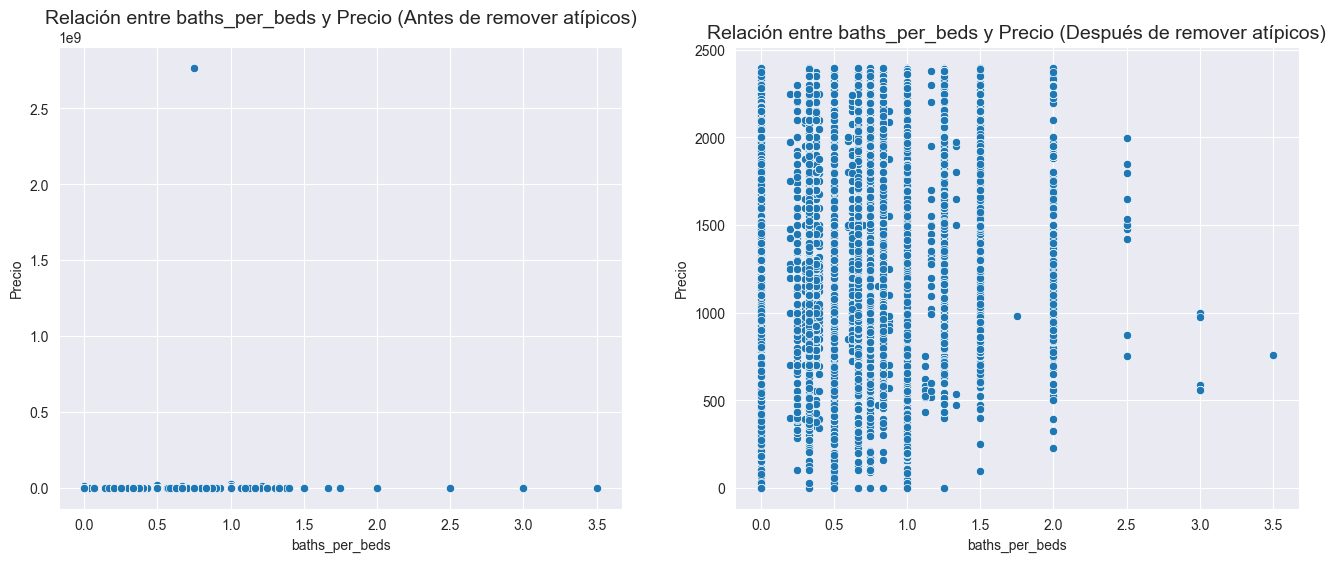

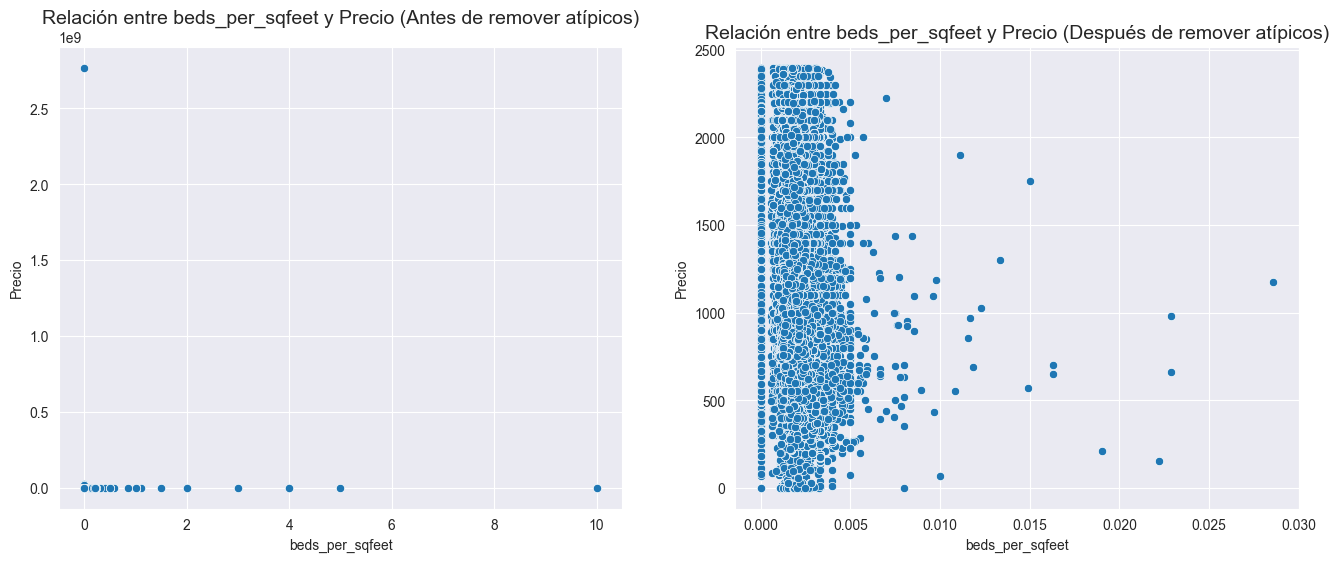

In [48]:
for col in vars_con:
    plt.figure(figsize=(16, 6))
    plt.subplot(1, 2, 1)
    sns.scatterplot(data=data, x=col, y=target_var_num)
    plt.title(f'Relación entre {col} y Precio (Antes de remover atípicos)', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Precio')

    plt.subplot(1, 2, 2)
    sns.scatterplot(data=data_cleaned, x=col, y=target_var_num)
    plt.title(f'Relación entre {col} y Precio (Después de remover atípicos)', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Precio')
    plt.show()


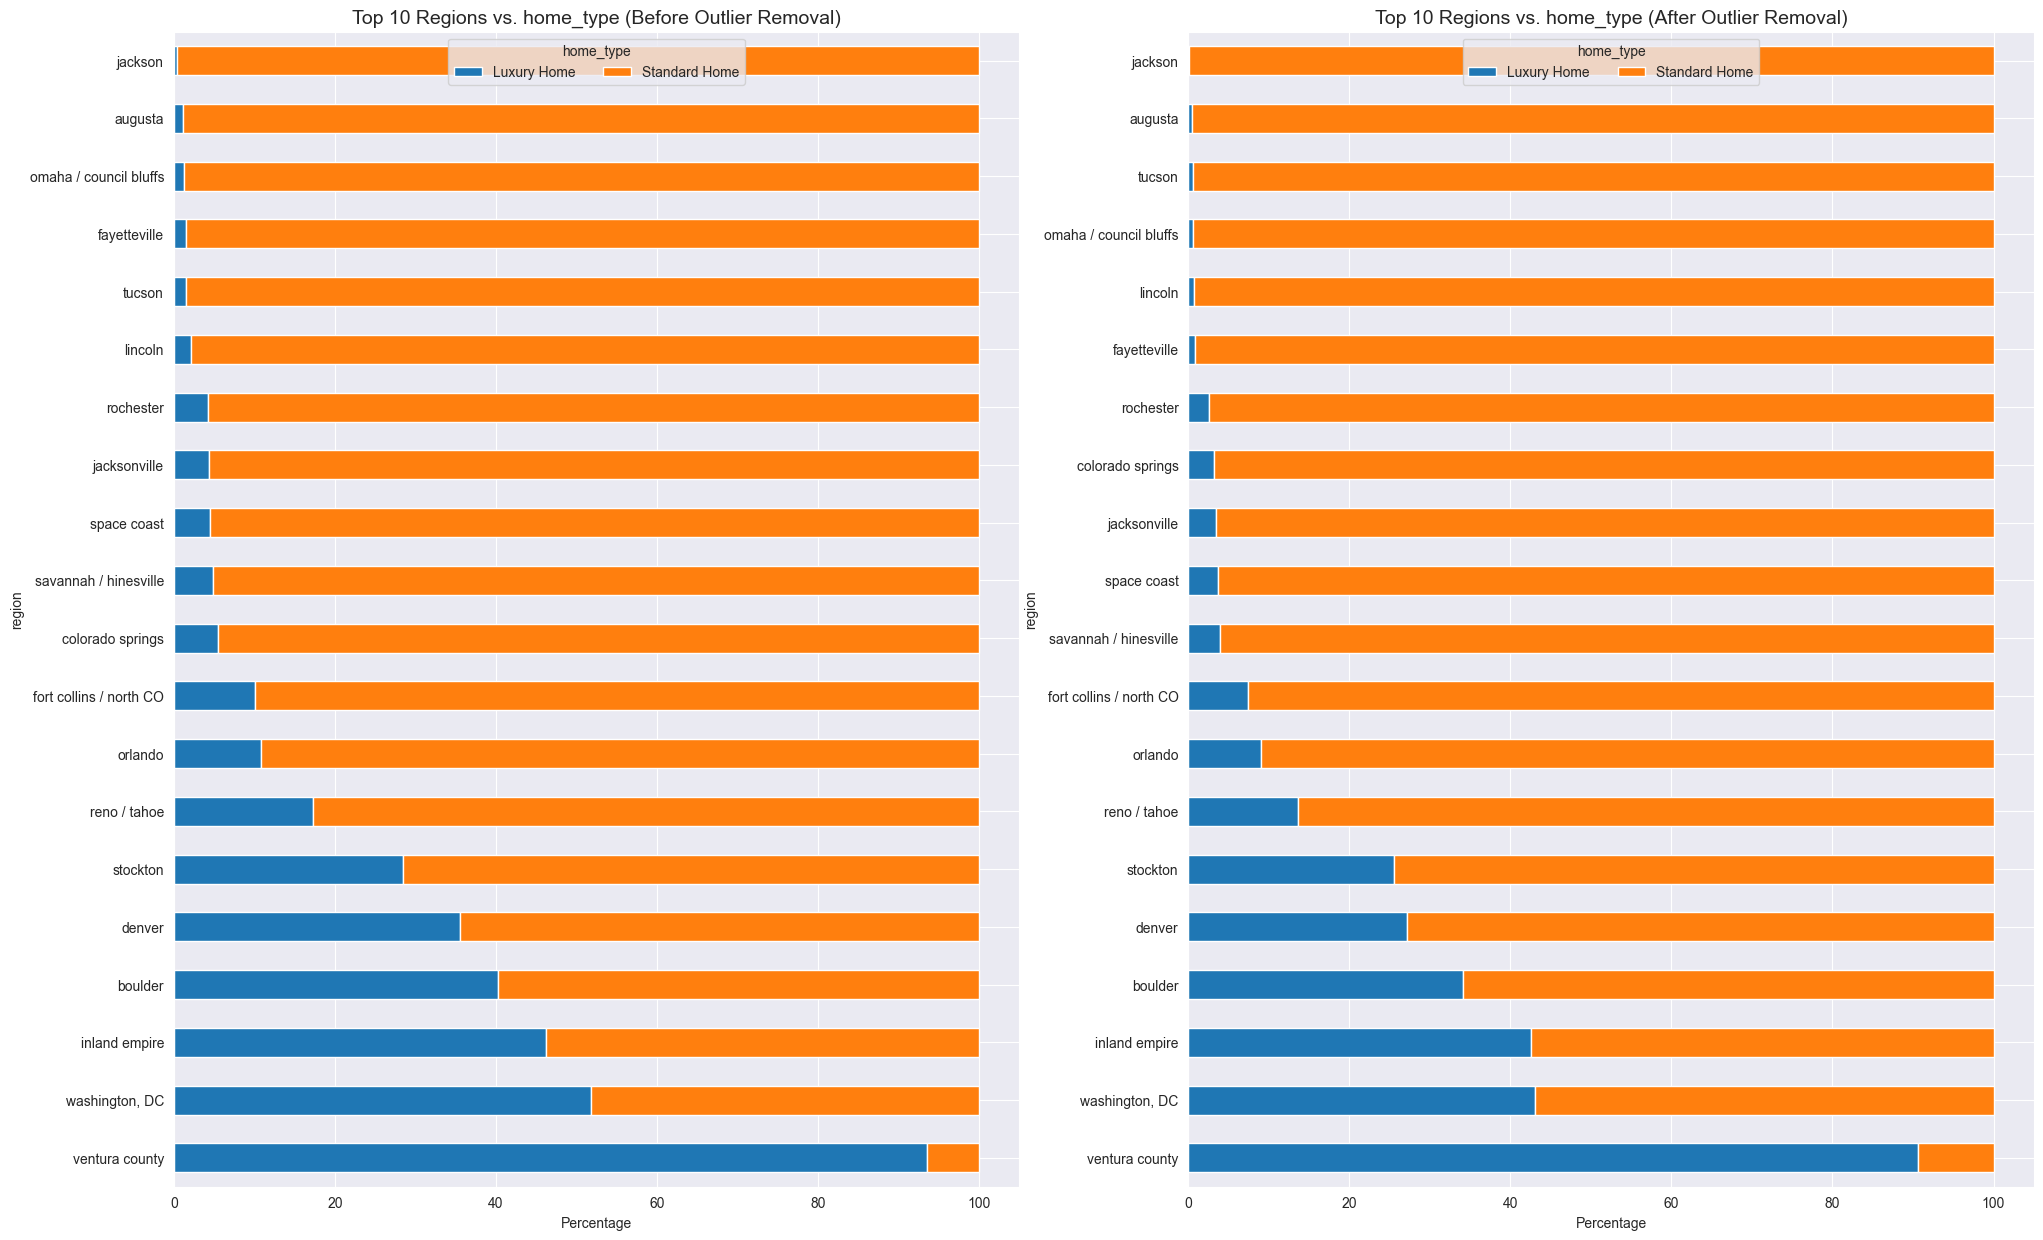

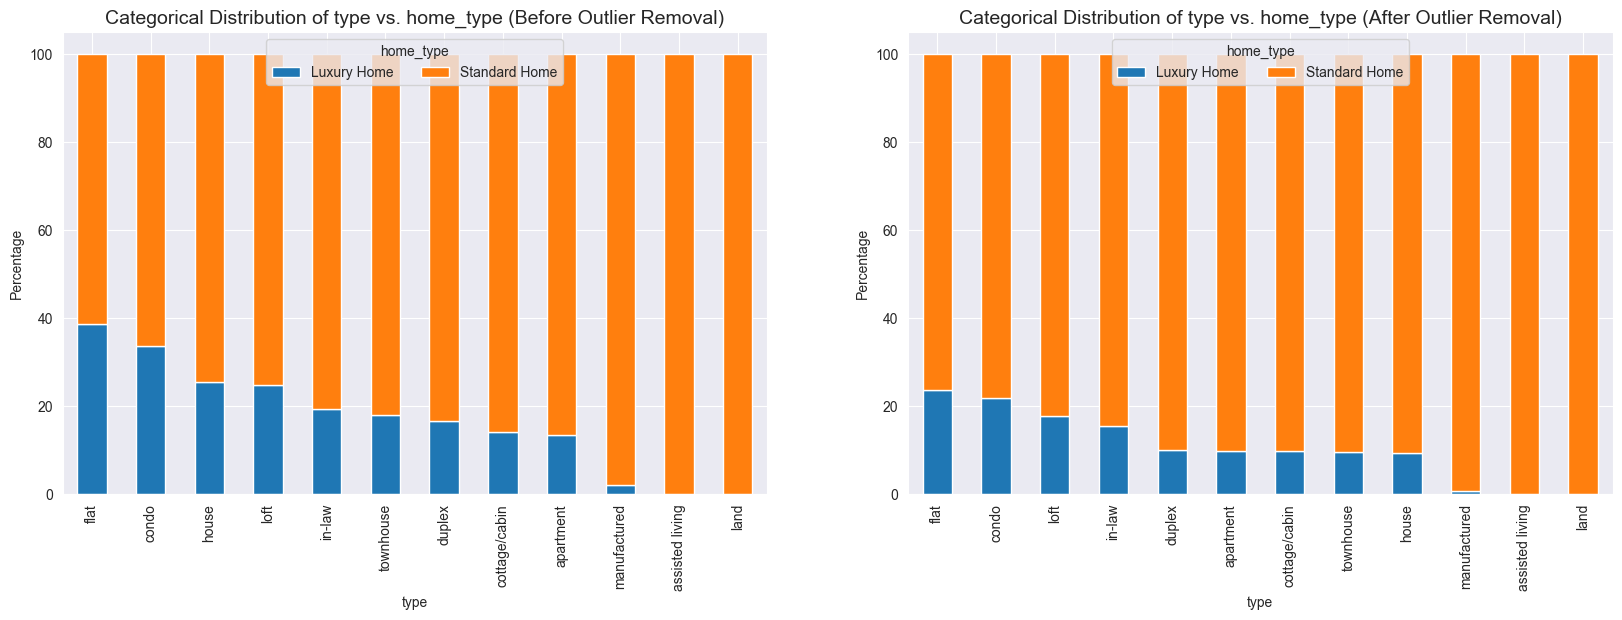

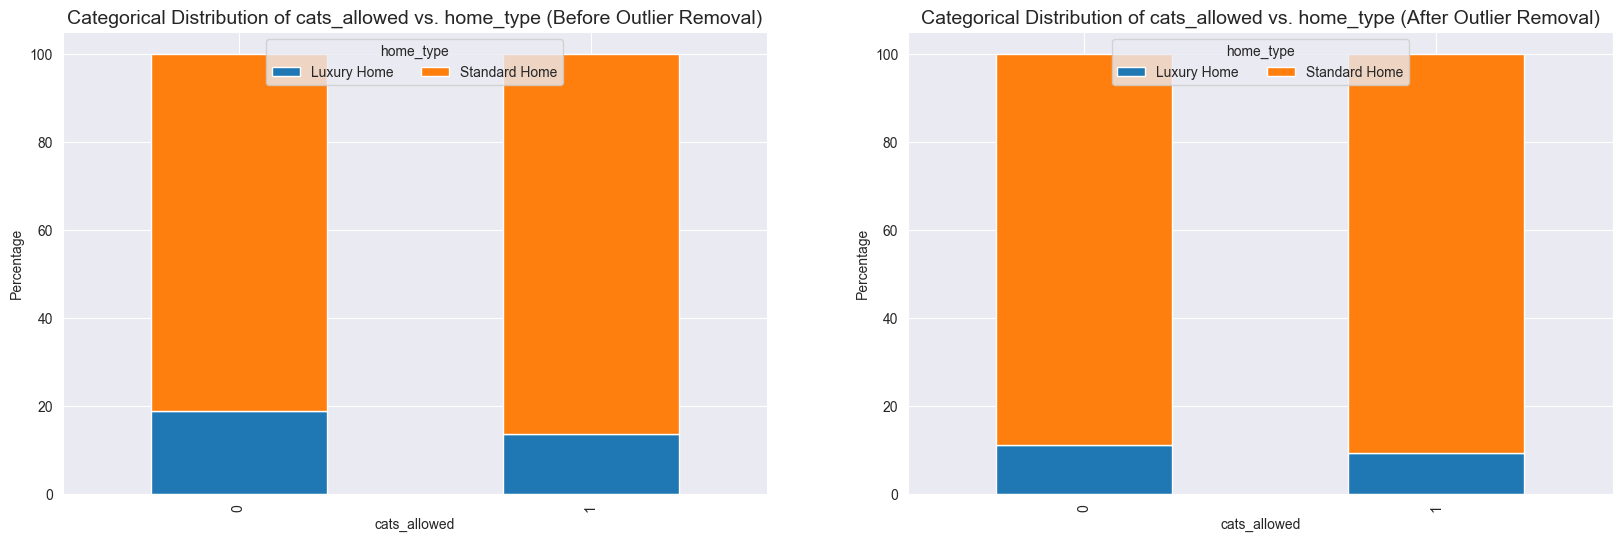

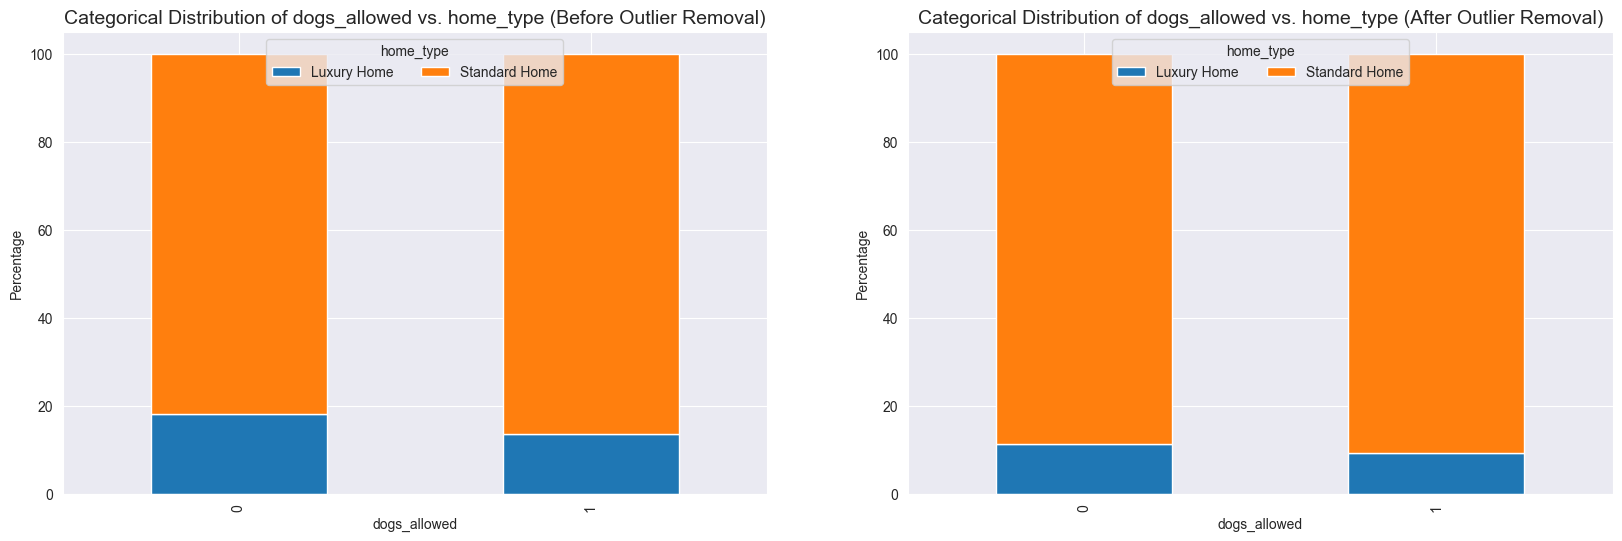

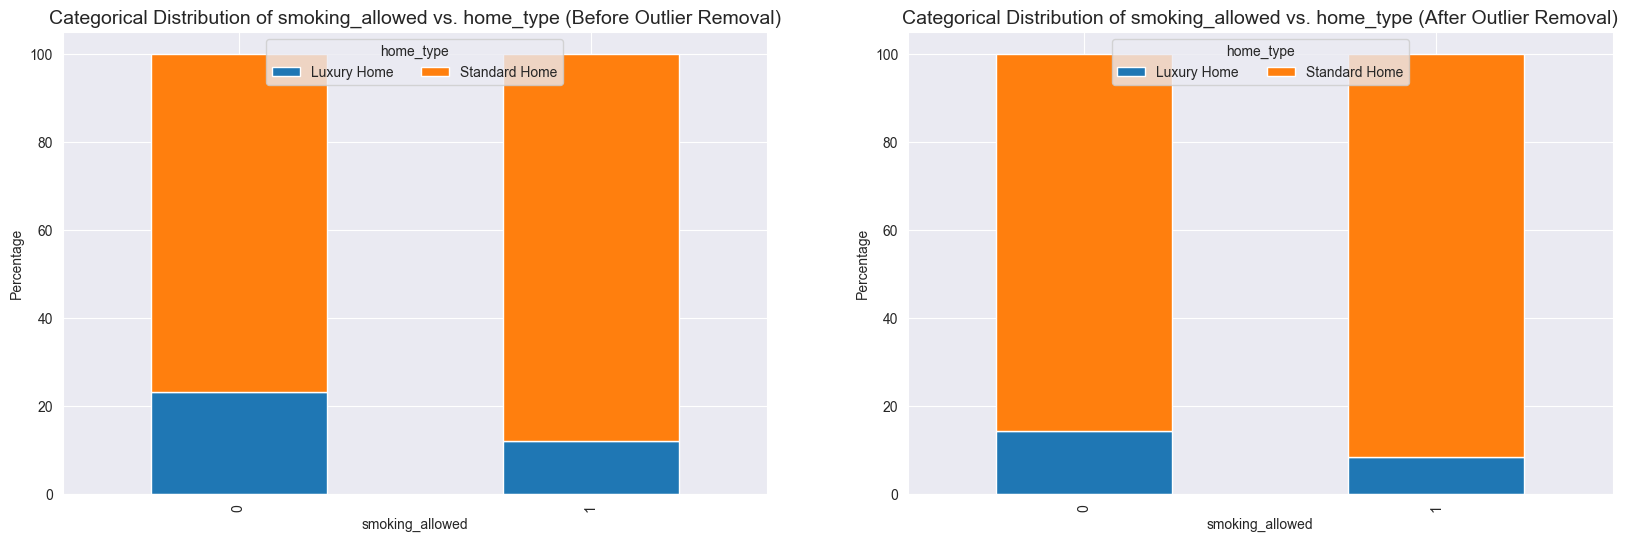

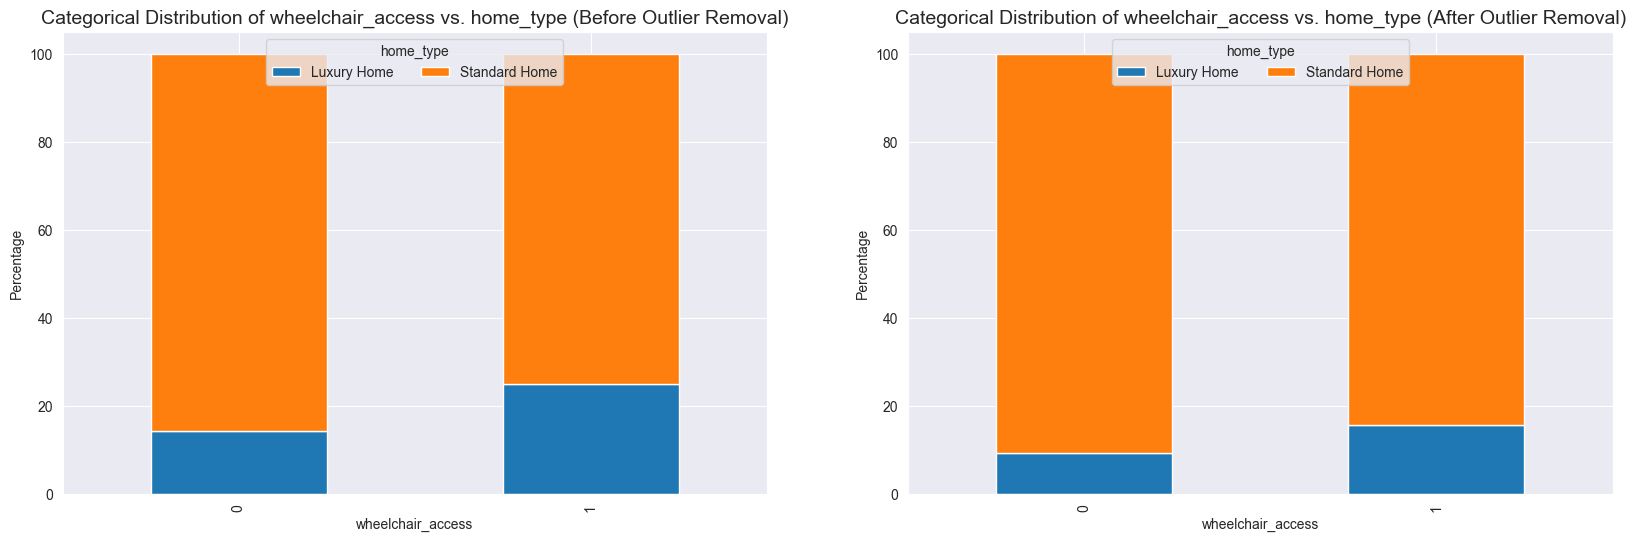

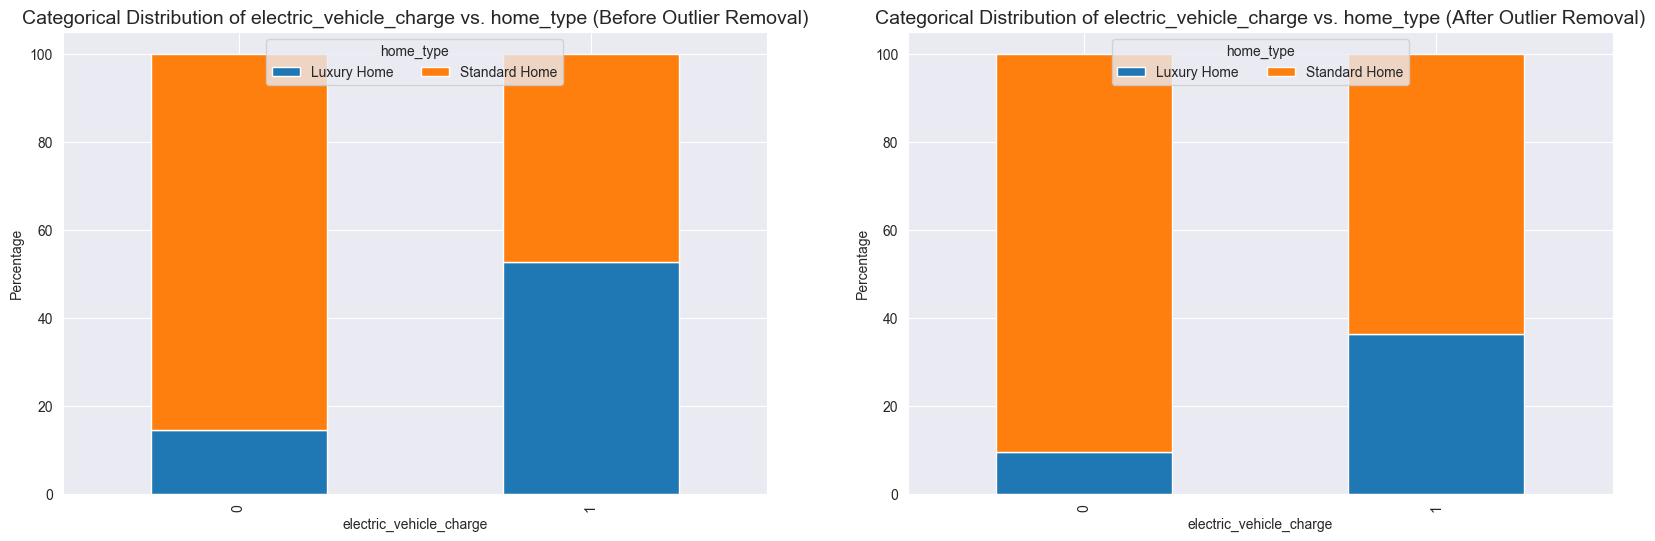

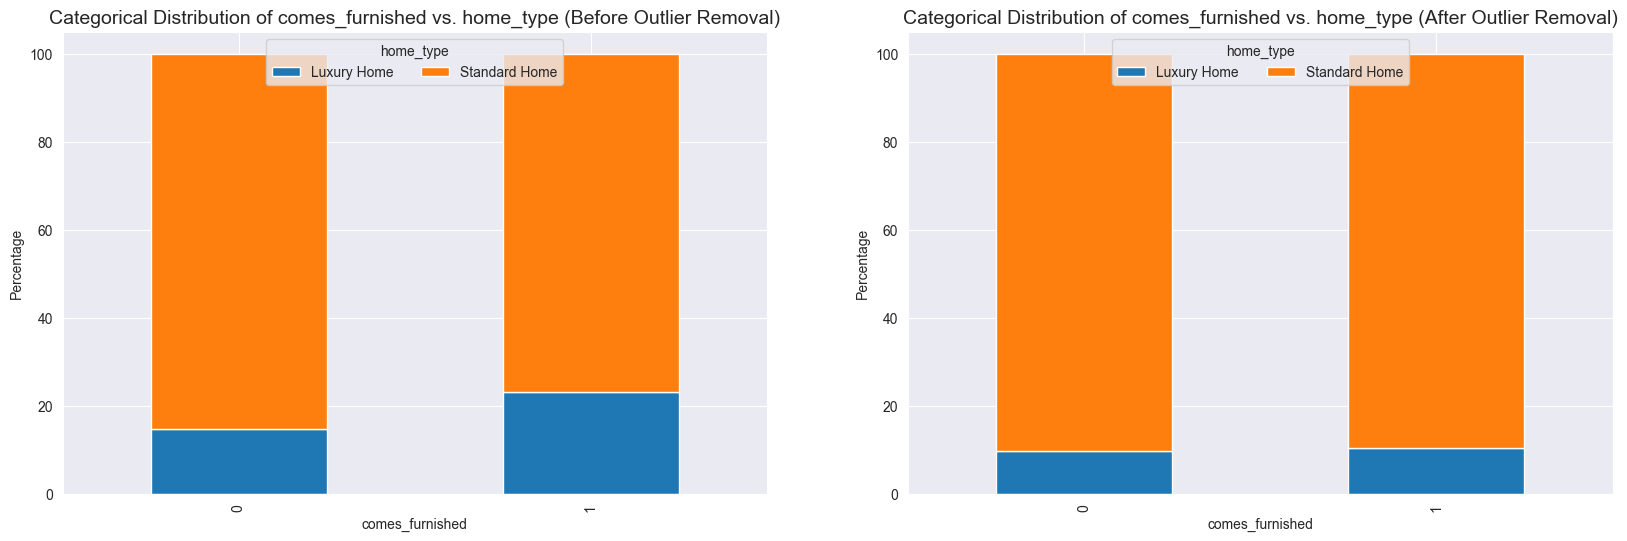

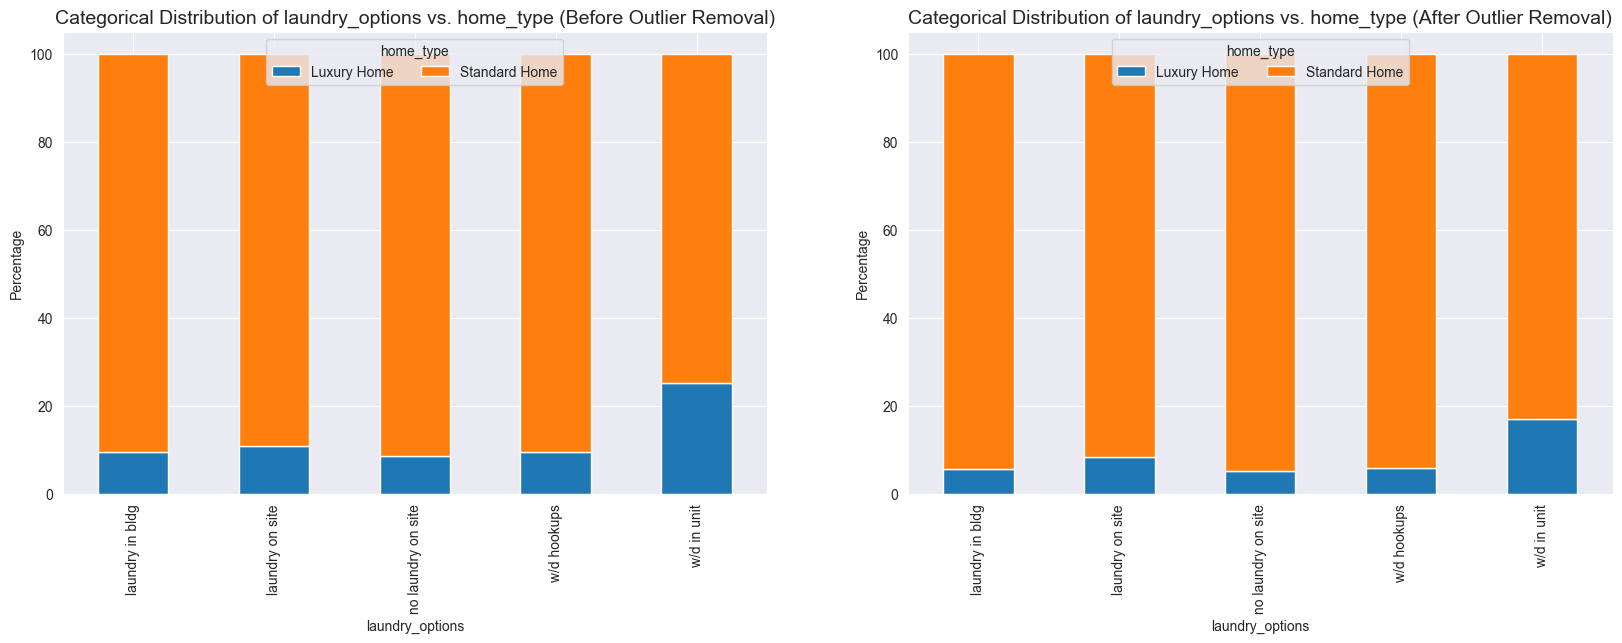

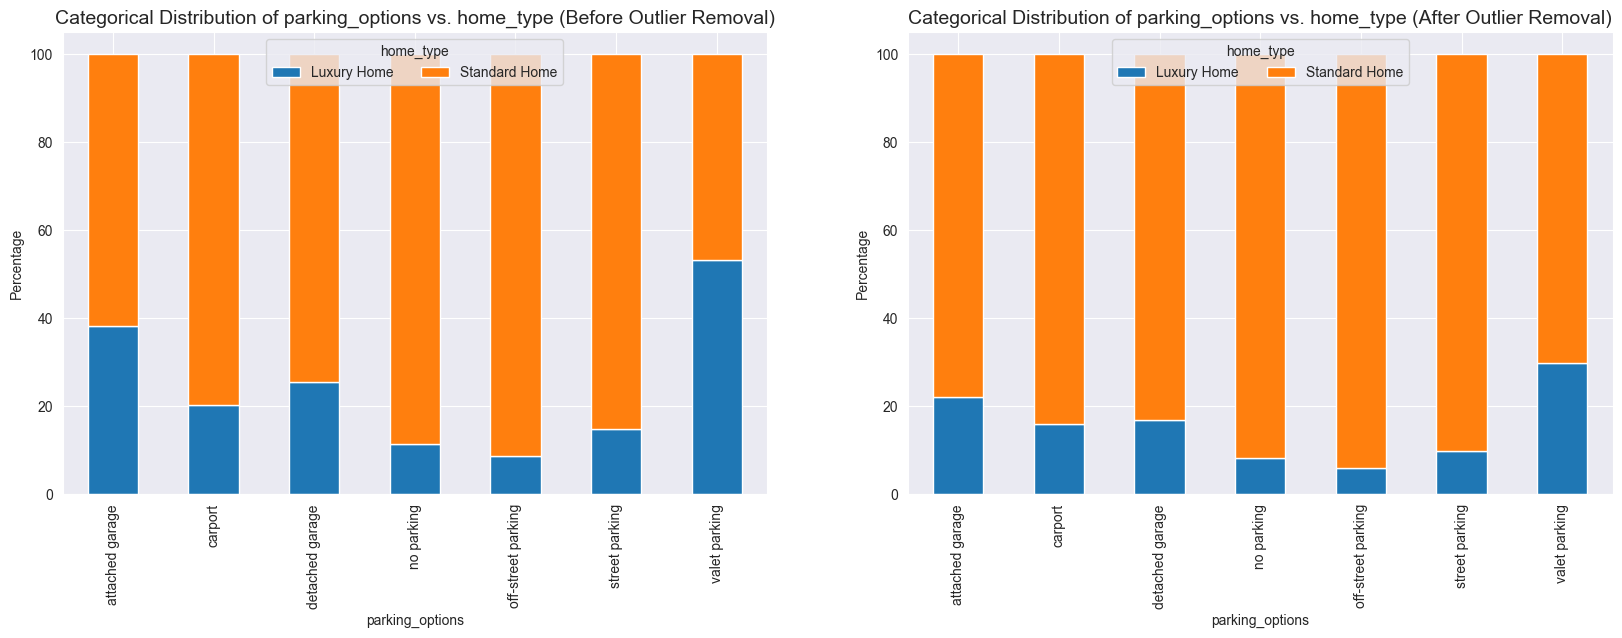

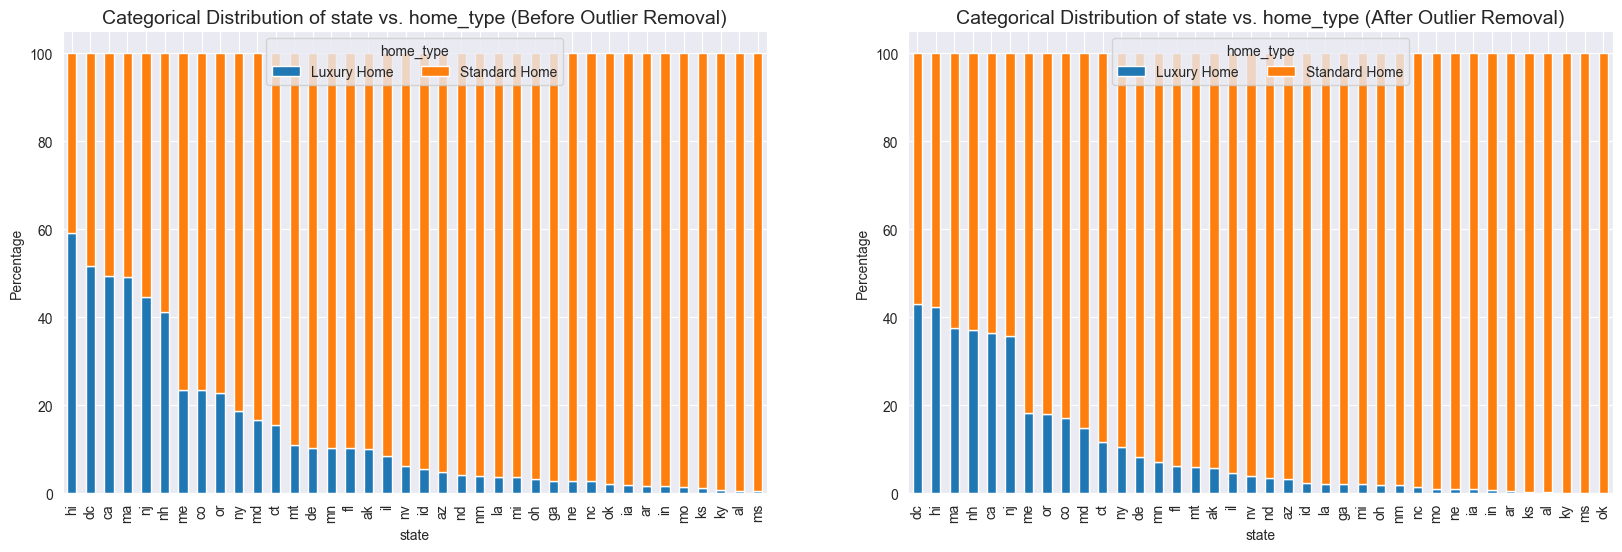

In [49]:
for col in vars_cat:
    if col == "region":
        plt.figure(figsize=(24, 15))  # Adjust height for better visualization

        top_10_regions = data[col].value_counts().nlargest(20).index
        filtered_data = data[data[col].isin(top_10_regions)]
        filtered_data_cleaned = data_cleaned[data_cleaned[col].isin(top_10_regions)]

        # Compute normalized proportions
        region_dist = pd.crosstab(filtered_data[col], filtered_data[target_var_cat], normalize='index') * 100
        region_dist_cleaned = pd.crosstab(filtered_data_cleaned[col], filtered_data_cleaned[target_var_cat], normalize='index') * 100

        # Sort by "Luxury Home" percentage
        if "Luxury Home" in region_dist.columns:
            region_dist = region_dist.sort_values(by="Luxury Home", ascending=False)
        if "Luxury Home" in region_dist_cleaned.columns:
            region_dist_cleaned = region_dist_cleaned.sort_values(by="Luxury Home", ascending=False)

        plt.subplot(1, 2, 1)
        region_dist.plot(kind='barh', stacked=True, ax=plt.gca())
        plt.title(f'Top 10 Regions vs. {target_var_cat} (Before Outlier Removal)', fontsize=14)
        plt.xlabel('Percentage')
        plt.ylabel(col)
        plt.legend(title=target_var_cat, loc='upper center', ncol=3)

        plt.subplot(1, 2, 2)
        region_dist_cleaned.plot(kind='barh', stacked=True, ax=plt.gca())
        plt.title(f'Top 10 Regions vs. {target_var_cat} (After Outlier Removal)', fontsize=14)
        plt.xlabel('Percentage')
        plt.ylabel(col)
        plt.legend(title=target_var_cat,  loc='upper center', ncol=3)

    else:
        plt.figure(figsize=(20, 6))

        # Compute normalized proportions
        cat_dist = pd.crosstab(data[col], data[target_var_cat], normalize='index') * 100
        cat_dist_cleaned = pd.crosstab(data_cleaned[col], data_cleaned[target_var_cat], normalize='index') * 100

        # Sort by "Luxury Home" percentage if applicable
        if col in ["type", "state", "region"] and "Luxury Home" in cat_dist.columns:
            cat_dist = cat_dist.sort_values(by="Luxury Home", ascending=False)
        if col in ["type", "state", "region"] and "Luxury Home" in cat_dist_cleaned.columns:
            cat_dist_cleaned = cat_dist_cleaned.sort_values(by="Luxury Home", ascending=False)

        plt.subplot(1, 2, 1)
        cat_dist.plot(kind='bar', stacked=True, ax=plt.gca())
        plt.title(f'Categorical Distribution of {col} vs. {target_var_cat} (Before Outlier Removal)', fontsize=14)
        plt.xlabel(col)
        plt.ylabel('Percentage')
        plt.legend(title=target_var_cat,  loc='upper center', ncol=3)

        plt.subplot(1, 2, 2)
        cat_dist_cleaned.plot(kind='bar', stacked=True, ax=plt.gca())
        plt.title(f'Categorical Distribution of {col} vs. {target_var_cat} (After Outlier Removal)', fontsize=14)
        plt.xlabel(col)
        plt.ylabel('Percentage')
        plt.legend(title=target_var_cat, loc='upper center', ncol=3)





## Paso 11: Análisis multivariado

### Paso 11.1: Análisis de Correlación

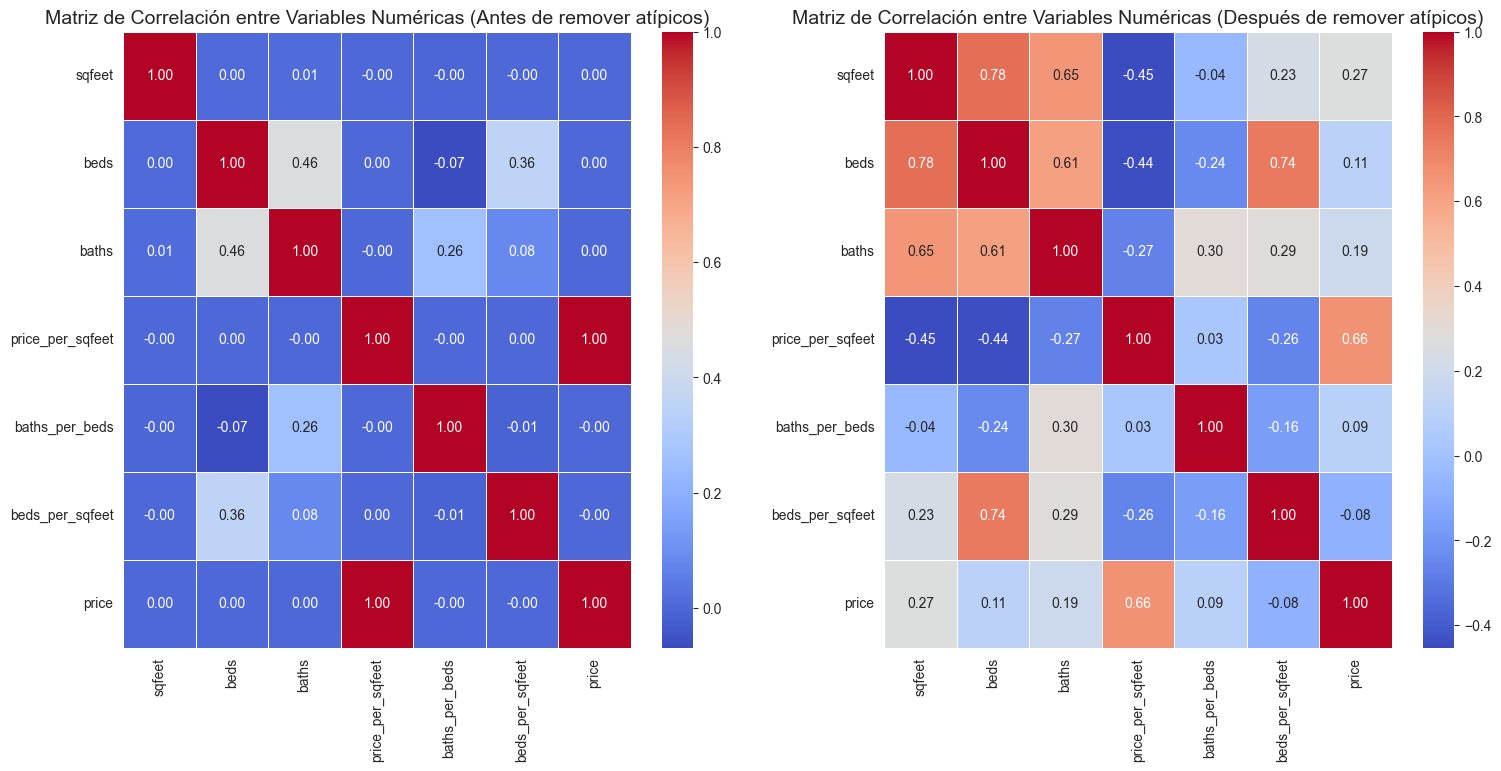

In [50]:
correlation_matrix = data[vars_nums + [target_var_num]].corr()
plt.figure(figsize=(18, 8))
plt.subplot(1, 2, 1)
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación entre Variables Numéricas (Antes de remover atípicos)", fontsize=14)

correlation_matrix_cleaned = data_cleaned[vars_nums + [target_var_num]].corr()
plt.subplot(1, 2, 2)
sns.heatmap(correlation_matrix_cleaned, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación entre Variables Numéricas (Después de remover atípicos)", fontsize=14)
plt.show()

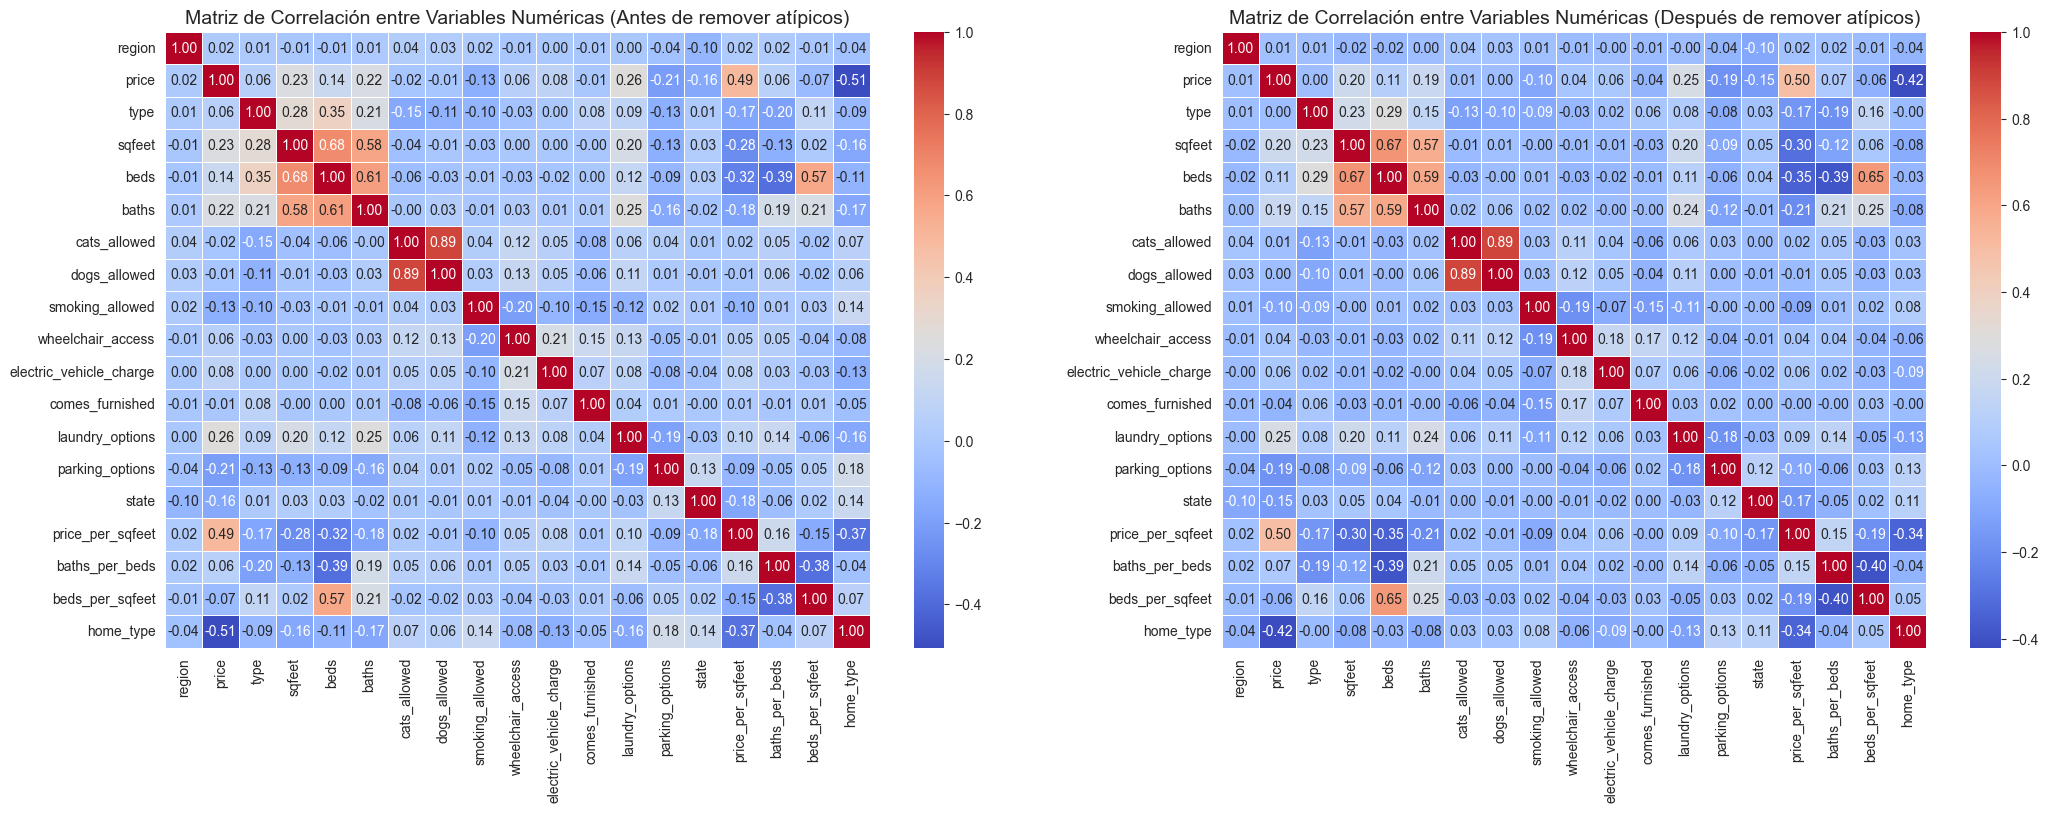

In [51]:
# Copy datasets to avoid modifying the original
data_encoded = data.copy()
data_cleaned_encoded = data_cleaned.copy()

# Ensure vars_cat and target_var_cat are defined and contain categorical columns
categorical_columns = vars_cat + [target_var_cat]

label_encoder = LabelEncoder()

for col in categorical_columns:
    if col in data.columns:
        data_encoded[col] = label_encoder.fit_transform(data[col].astype(str))  # Ensure string type
    if col in data_cleaned.columns:
        data_cleaned_encoded[col] = label_encoder.fit_transform(data_cleaned[col].astype(str))  # Ensure string type

# Compute the correlation matrices
correlation_matrix = data_encoded.corr(method='kendall')
correlation_matrix_cleaned = data_cleaned_encoded.corr(method='kendall')

# Plot the heatmaps
plt.figure(figsize=(25, 8))

plt.subplot(1, 2, 1)
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación entre Variables Numéricas (Antes de remover atípicos)", fontsize=14)

plt.subplot(1, 2, 2)
sns.heatmap(correlation_matrix_cleaned, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación entre Variables Numéricas (Después de remover atípicos)", fontsize=14)

plt.show()

## Paso 12: Pruebas de Hipotesis

## Paso 13: Preparación de los Datos

### Paso 13.1: Codificación de Variables Categóricas

In [52]:
df_encoded = data_cleaned.copy()

#### Paso 13.1.1: Aplicar Label Encoding

In [53]:
label_encoder = LabelEncoder()

df_encoded['home_type'] = label_encoder.fit_transform(data_cleaned['home_type'])
df_encoded['laundry_options'] = label_encoder.fit_transform(data_cleaned['laundry_options'])
df_encoded['parking_options'] = label_encoder.fit_transform(data_cleaned['parking_options'])

#### Paso 13.1.2: Aplicar one-hot encoding

In [54]:
categorical_columns = ['type', 'state', 'region']
df_encoded = pd.get_dummies(df_encoded, columns=categorical_columns, drop_first=True)

In [55]:
df_encoded.head()

,price,sqfeet,beds,baths,cats_allowed,dogs_allowed,smoking_allowed,wheelchair_access,electric_vehicle_charge,comes_furnished,...,region_western maryland,region_western massachusetts,region_western slope,region_wichita,region_wilmington,region_winston-salem,region_worcester / central MA,region_yuba-sutter,region_yuma,region_zanesville / cambridge
1,1120,1319,3,2.0,1,1,1,0,0,0,...,False,False,False,False,False,False,False,False,False,False
2,825,1133,1,1.5,1,1,1,0,0,0,...,False,False,False,False,False,False,False,False,False,False
3,800,927,1,1.0,1,1,1,0,0,0,...,False,False,False,False,False,False,False,False,False,False
4,785,1047,2,1.0,1,1,1,0,0,0,...,False,False,False,False,False,False,False,False,False,False
5,900,1298,2,2.0,1,1,1,0,0,0,...,False,False,False,False,False,False,False,False,False,False


## Paso 14: Organizar los datos en categorías: originales, procesados, regresión y clasificación.

In [56]:
X_original_regression_three_vars = data[['beds', 'baths', 'sqfeet']]
y_original_regression_three_vars = data[target_var_num]

In [57]:
X_processed_regression_three_vars = df_encoded[['beds', 'baths', 'sqfeet']]
y_processed_regression_three_vars = df_encoded[target_var_num]

In [58]:
X_processed_regression_all = df_encoded.drop(columns=['price', 'home_type'], errors='ignore')
y_processed_regression_all = df_encoded[target_var_num]

In [59]:
X_original_classifications = data[['beds', 'baths', 'sqfeet']]
y_original_classification = data[target_var_cat]

In [60]:
X_processed_classification = df_encoded.drop(columns=['price', 'home_type'], errors='ignore')
y_processed_classification = df_encoded[target_var_cat]

In [61]:
X_train_orig_3, X_test_orig_3, y_train_orig_3, y_test_orig_3 = train_test_split(X_original_regression_three_vars,
                                                                                y_original_regression_three_vars,
                                                                                test_size=0.2,
                                                                                random_state=42)
X_train_proc_3, X_test_proc_3, y_train_proc_3, y_test_proc_3 = train_test_split(X_processed_regression_three_vars,
                                                                                y_processed_regression_three_vars,
                                                                                test_size=0.2,
                                                                                random_state=42)
X_train_proc_all, X_test_proc_all, y_train_proc_all, y_test_proc_all = train_test_split(X_processed_regression_all,
                                                                                        y_processed_regression_all,
                                                                                        test_size=0.2,
                                                                                        random_state=42)

In [62]:
X_train_orig_class, X_test_orig_class, y_train_orig_class, y_test_orig_class = train_test_split(X_original_classifications,
                                                                                                y_original_classification,
                                                                                                test_size=0.2,
                                                                                                random_state=42)
X_train_proc_class, X_test_proc_class, y_train_proc_class, y_test_proc_class = train_test_split(X_processed_classification,
                                                                                                y_processed_classification,
                                                                                                test_size=0.2,
                                                                                                random_state=42)

## Paso 15: Función para entrenar, evaluar y graficar modelos

In [63]:
def train_and_evaluate_model(model, X_train, X_test, y_train, y_test, title):
    # Entrenamiento
    model.fit(X_train, y_train)

    # Predicciones
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Cálculo de métricas
    metrics = {
        "MAE_Train": mean_absolute_error(y_train, y_pred_train),
        "RMSE_Train": np.sqrt(mean_squared_error(y_train, y_pred_train)),
        "R2_Train": r2_score(y_train, y_pred_train),
        "MAE_Test": mean_absolute_error(y_test, y_pred_test),
        "RMSE_Test": np.sqrt(mean_squared_error(y_test, y_pred_test)),
        "R2_Test": r2_score(y_test, y_pred_test)
    }

    return  y_pred_train, y_pred_test, title, metrics

## Paso 16: Modelos

## Paso 16.1: Modelos para regressión

In [64]:
# --------------------------------------------
# 2. Modelos y Evaluación
# --------------------------------------------

lineal_models = {
    "Regresión Lineal Múltiple": LinearRegression(),
    "Lasso (alpha=0.1)": Lasso(alpha=0.1),
    "Ridge (alpha=1.0)": Ridge(alpha=1.0)
}

lineal_results = []


## Paso 16.2: Modelos para clasificación

In [65]:
logistic_orig_model = LogisticRegression()
logistic_proc_model = LogisticRegression()

## Paso 17: Entrenamiento

### Paos 17.1: Entrenamiento de los modelos de regresión

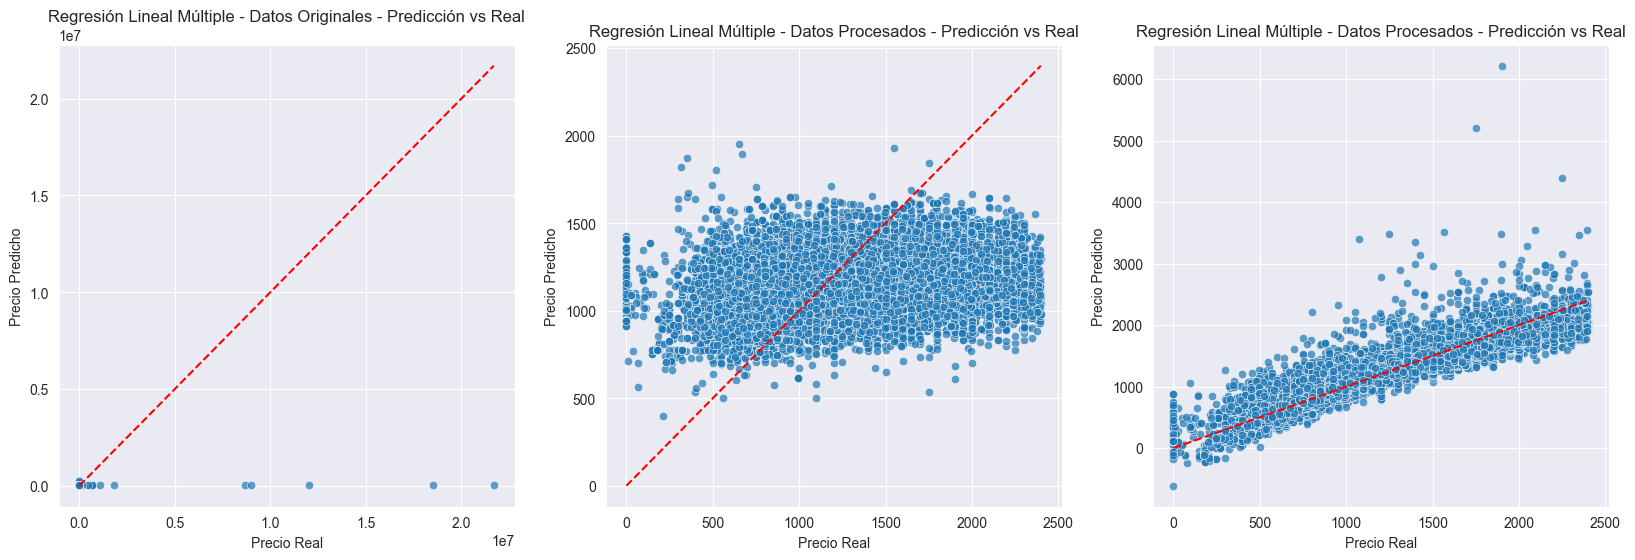

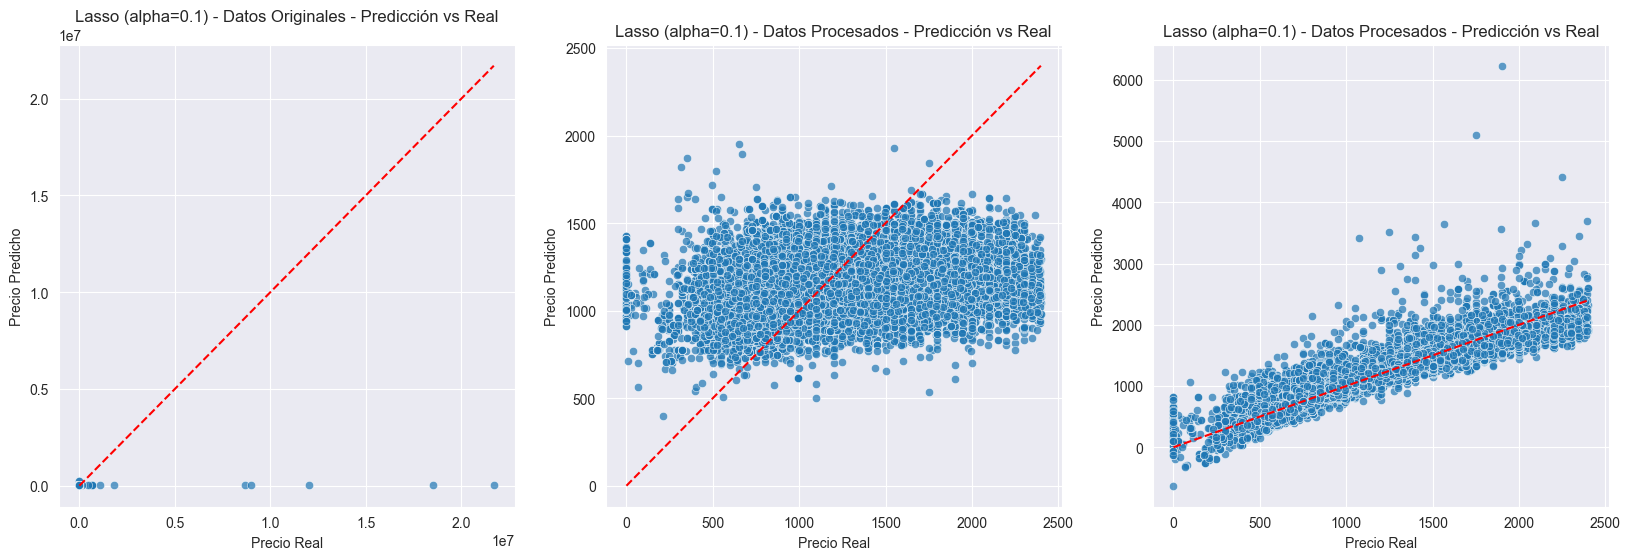

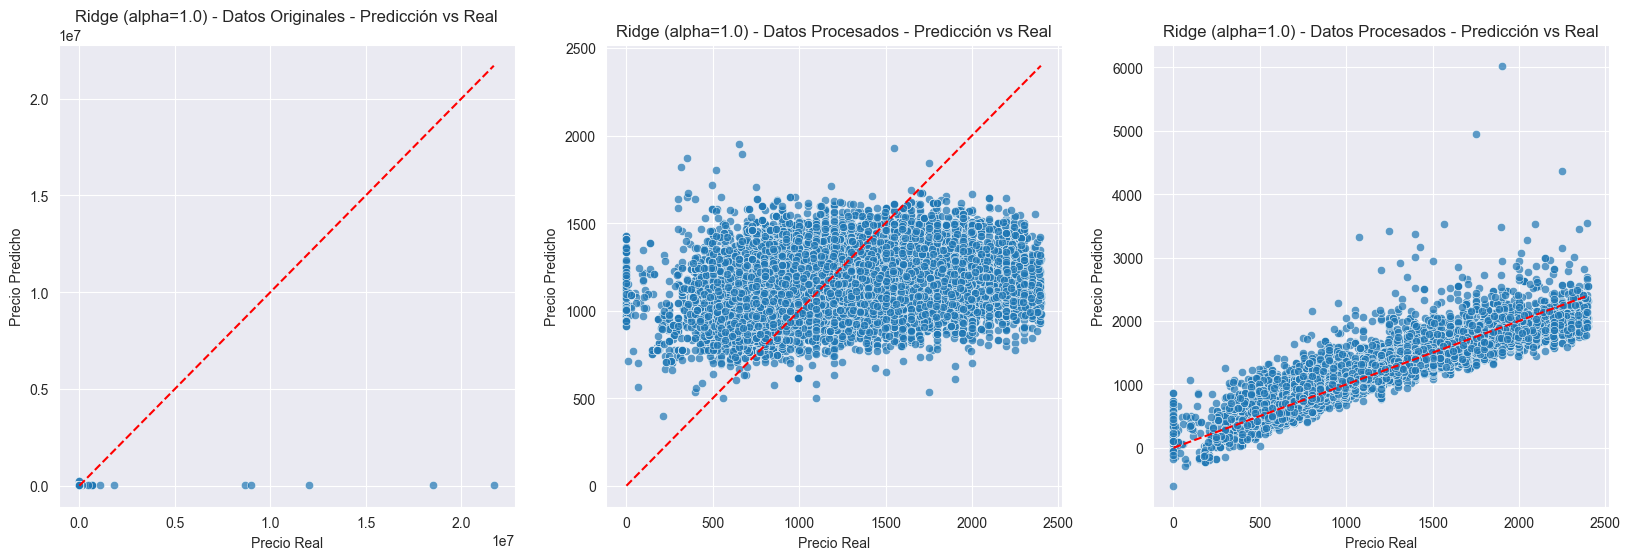

In [66]:
# Entrenamiento y evaluación con la base original
for name, model in lineal_models.items():
    y_train, y_pred_test, title, metrics1 = train_and_evaluate_model(model, X_train_orig_3, X_test_orig_3, y_train_orig_3, y_test_orig_3, f"{name} - Datos Originales")
    lineal_results .append({"Modelo": name + " - Original", **metrics1})
    plt.figure(figsize=(20, 6))
    plt.subplot(1, 3, 1)
    sns.scatterplot(x = y_test_orig_3, y = y_pred_test, alpha = 0.7)
    plt.plot([y_test_orig_3.min(), y_test_orig_3.max()], [y_test_orig_3.min(), y_test_orig_3.max()], '--', color='red')
    plt.xlabel("Precio Real")
    plt.ylabel("Precio Predicho")
    plt.title(f"{title} - Predicción vs Real")


    y_train, y_pred_test ,title, metrics2 = train_and_evaluate_model(model, X_train_proc_3, X_test_proc_3, y_train_proc_3, y_test_proc_3, f"{name} - Datos Procesados")
    lineal_results .append({"Modelo": name + " - Procesado 3 Variables", **metrics2})
    plt.subplot(1, 3, 2)
    sns.scatterplot(x=y_test_proc_3, y=y_pred_test, alpha=0.7)
    plt.plot([y_test_proc_3.min(), y_test_proc_3.max()], [y_test_proc_3.min(), y_test_proc_3.max()], '--', color='red')
    plt.xlabel("Precio Real")
    plt.ylabel("Precio Predicho")
    plt.title(f"{title} - Predicción vs Real")



    y_train, y_pred_test ,title, metrics3 = train_and_evaluate_model(model, X_train_proc_all, X_test_proc_all, y_train_proc_all, y_test_proc_all, f"{name} - Datos Procesados")
    lineal_results.append({"Modelo": name + " - Procesado Todas Variables", **metrics3})
    plt.subplot(1, 3, 3)
    sns.scatterplot(x=y_test_proc_all, y=y_pred_test, alpha=0.7)
    plt.plot([y_test_proc_all.min(), y_test_proc_all.max()], [y_test_proc_all.min(), y_test_proc_all.max()], '--', color='red')
    plt.xlabel("Precio Real")
    plt.ylabel("Precio Predicho")
    plt.title(f"{title} - Predicción vs Real")
    plt.show()


Se observa que los modelos mejoran la predicción cuando los datos se procesan eliminando los valores atípicos y al incluir más variables.

### Paos 17.2: Entrenamiento de los modelos de clasificación

In [67]:
scaler = StandardScaler()

### Paso 17.2.1 Entrenamiento con Datos Originales

In [68]:
X_train_orig_scaled = scaler.fit_transform(X_train_orig_class)
X_test_orig_scaled = scaler.transform(X_test_orig_class)

In [69]:
logistic_orig_model.fit(X_train_orig_scaled, y_train_orig_class)

LogisticRegression()

In [70]:
y_pred_orig = logistic_orig_model.predict(X_test_orig_scaled)

### 17.2.2 Entrenamiento con Datos Procesados

In [71]:
X_train_proc_scaled = scaler.fit_transform(X_train_proc_class)
X_test_proc_scaled = scaler.transform(X_test_proc_class)

In [72]:
logistic_proc_model.fit(X_train_proc_scaled, y_train_proc_class)

LogisticRegression()

In [73]:
y_pred_proc = logistic_proc_model.predict(X_test_proc_scaled)

## Paso 18: Evaluación

### Paso 18.1: Resultados de regresión

In [74]:
results_df = pd.DataFrame(lineal_results)
results_df

,Modelo,MAE_Train,RMSE_Train,R2_Train,MAE_Test,RMSE_Test,R2_Test
0,Regresión Lineal Múltiple - Original,26874.288492,6.010491e+06,1.026760e-08,14908.551004,145877.138442,-0.006814
1,Regresión Lineal Múltiple - Procesado 3 Variables,310.903563,3.946653e+02,1.008866e-01,310.277913,393.910194,0.105011
2,Regresión Lineal Múltiple - Procesado Todas Va...,90.145153,1.399017e+02,8.870198e-01,89.730043,139.435091,0.887858
3,Lasso (alpha=0.1) - Original,26874.288572,6.010491e+06,1.026760e-08,14908.552677,145877.140368,-0.006814
4,Lasso (alpha=0.1) - Procesado 3 Variables,310.912963,3.946655e+02,1.008859e-01,310.285888,393.909412,0.105015
5,Lasso (alpha=0.1) - Procesado Todas Variables,90.510835,1.420779e+02,8.834776e-01,89.807410,140.945942,0.885415
6,Ridge (alpha=1.0) - Original,26874.288494,6.010491e+06,1.026760e-08,14908.551043,145877.138494,-0.006814
7,Ridge (alpha=1.0) - Procesado 3 Variables,310.903612,3.946653e+02,1.008866e-01,310.277959,393.910193,0.105011
8,Ridge (alpha=1.0) - Procesado Todas Variables,90.593790,1.400123e+02,8.868411e-01,90.179086,139.423381,0.887877


Se puede observar que, para los datos procesados, los modelos de regresión lineal múltiple, Lasso y Ridge muestran una mejora en las métricas MAE y RMSE. Específicamente, el MAE se reduce de 26,874 a aproximadamente 90 para los datos procesados, y el RMSE disminuye de 6,010,490 a aproximadamente 140. Entre estos modelos, la regresión lineal múltiple presenta la mejor capacidad explicativa, con un R² de 0.89.

### Paso 19: Resultados de clasificación

In [75]:
accuracy_orig = accuracy_score(y_test_orig_class, y_pred_orig)
print(f"📊 **Regresión Logística Originales** - Accuracy: {accuracy_orig:.2f}")

📊 **Regresión Logística Originales** - Accuracy: 0.85


In [76]:
accuracy_proc = accuracy_score(y_test_proc_class, y_pred_proc)
print(f"📊 **Regresión Logística Procesados** - Accuracy: {accuracy_proc:.2f}")

📊 **Regresión Logística Procesados** - Accuracy: 0.97


Se puede observar que el *accuracy* de la regresión logística mejora al utilizar los datos procesados, lo que indica que el preprocesamiento contribuyó a una mejor diferenciación entre los modelos.

In [77]:
# Evaluar el modelo
print("\nLogistic Regression Results Original:")
print(classification_report(y_test_orig_class, y_pred_orig))
print("\nLogistic Regression Results Processed:")
print(classification_report(y_test_proc_class, y_pred_proc ))


Logistic Regression Results Original:
               precision    recall  f1-score   support

  Luxury Home       0.28      0.01      0.02      8009
Standard Home       0.85      1.00      0.92     45029

     accuracy                           0.85     53038
    macro avg       0.57      0.50      0.47     53038
 weighted avg       0.76      0.85      0.78     53038


Logistic Regression Results Processed:
              precision    recall  f1-score   support

           0       0.87      0.81      0.84      4771
           1       0.98      0.99      0.98     43601

    accuracy                           0.97     48372
   macro avg       0.93      0.90      0.91     48372
weighted avg       0.97      0.97      0.97     48372



**Resultados Antes del Procesamiento (Original)**

**Análisis:**
- **Mala detección de Luxury Home**
  - Precisión: **28%** (cuando predice "Luxury Home", solo el 28% son realmente de esa clase).
  - Recall: **1%** (solo detecta el **1%** de las casas de lujo).
  - F1-score: **0.02** (muy bajo, lo que indica mal desempeño en esta clase).

- **Excelente detección de Standard Home**
  - Precisión: **85%** (cuando predice "Standard Home", acierta en el 85% de los casos).
  - Recall: **100%** (detecta todas las casas estándar correctamente).
  - F1-score: **0.92** (indica buen equilibrio entre precisión y recall).

- **Exactitud general: 85%**
  - El modelo tiene una **alta precisión general**, pero **casi no detecta las casas de lujo** (falsos negativos muy altos).

**Resultados Después del Procesamiento**
**Análisis:**
- **Gran mejora en la detección de Luxury Home**
  - Precisión: **87%** (cuando predice "Luxury Home", el 87% de las veces acierta).
  - Recall: **81%** (detecta **81%** de las casas de lujo, mucho mejor que antes).
  - F1-score: **0.84** (indica un **buen equilibrio** entre precisión y recall).

- **Sigue detectando muy bien las Standard Home**
  - Precisión: **98%** (casi todas las predicciones de "Standard Home" son correctas).
  - Recall: **99%** (casi todas las casas estándar son correctamente clasificadas).
  - F1-score: **0.98** (indica un modelo muy confiable en esta clase).

- **Exactitud general: 97%**
  - **Mejora la precisión general del modelo**, evitando errores en la detección de casas de lujo.

**Conclusión**
- **El procesamiento de datos mejora la clasificación de casas de lujo (Luxury Home)**.
- **Se reducen los falsos negativos para Luxury Home** (antes solo detectaba 1%, ahora 81%).
- **El modelo mantiene una alta precisión para Standard Home**.
- **La exactitud general mejora de 85% a 97%**, mostrando una **mejor discriminación entre ambas clases**.

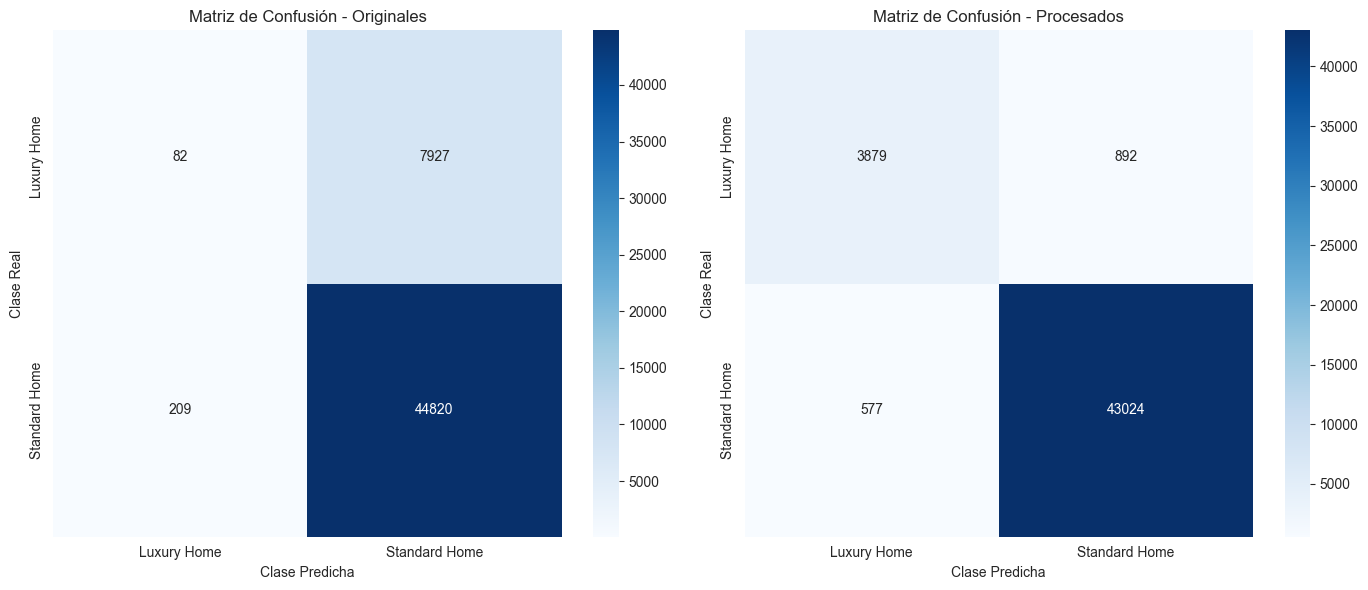

In [78]:
# Obtener etiquetas únicas de las clases en los datos originales y procesados
labels_orig = np.unique(np.concatenate((y_test_orig_class, y_pred_orig)))
labels_proc = np.unique(np.concatenate((y_test_proc_class, y_pred_proc)))

# Crear una figura con dos subgráficos en una fila
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Matriz de confusión para datos originales
cm_orig = confusion_matrix(y_test_orig_class, y_pred_orig, labels=labels_orig)
sns.heatmap(cm_orig, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_orig, yticklabels=labels_orig, ax=axes[0])
axes[0].set_title('Matriz de Confusión - Originales')
axes[0].set_xlabel("Clase Predicha")
axes[0].set_ylabel("Clase Real")

# Matriz de confusión para datos procesados
cm_proc = confusion_matrix(y_test_proc_class, y_pred_proc, labels=labels_proc)
sns.heatmap(cm_proc, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_orig, yticklabels=labels_orig, ax=axes[1])
axes[1].set_title('Matriz de Confusión - Procesados')
axes[1].set_xlabel("Clase Predicha")
axes[1].set_ylabel("Clase Real")

# Ajustar diseño
plt.tight_layout()
plt.show()


**Matriz de Confusión - Originales (Izquierda)**
- **Clases Reales:**
  - "Luxury Home" (Clase Minoritaria)
  - "Standard Home" (Clase Mayoritaria)
- **Clases Predichas:**
  - "Luxury Home" (Predicción Positiva)
  - "Standard Home" (Predicción Negativa)

Valores clave:
- **82** verdaderos positivos (Luxury Home predicho correctamente).
- **7927** falsos negativos (Luxury Home clasificado como Standard Home).
- **209** falsos positivos (Standard Home clasificado como Luxury Home).
- **44820** verdaderos negativos (Standard Home predicho correctamente).

**Problema:**
El modelo original tiene un **alto número de falsos negativos** (7927), lo que significa que muchas casas de lujo no están siendo detectadas correctamente.

**Matriz de Confusión - Procesados (Derecha)**
- La clase "Luxury Home" ahora se representa con 0 y "Standard Home" con 1.
- **Mejoras Clave:**
  - **Menos falsos negativos** (antes 7927, ahora 892).
  - **Aumento leve de falsos positivos** (antes 209, ahora 577), lo que indica que el modelo clasifica erróneamente más Standard Home como Luxury Home, pero no de manera drástica.
  - **Más verdaderos positivos** (antes 82, ahora 3879).
  - **Sigue detectando bien los Standard Home, aunque disminuye** (de 44820 a 43024).

🔹 **Conclusión:**
Después del procesamiento de datos, la regresión logística **mejora significativamente** la clasificación de casas de lujo (clase 0), reduciendo la cantidad de errores en esta categoría. Sin embargo, **los falsos positivos aumentaron ligeramente**, lo que indica que el modelo es más sensible a detectar casas de lujo, aunque con una pequeña reducción en precisión para la otra categoría.

In [79]:
# **Odds Ratio**
odds_ratios_proc = np.exp(logistic_orig_model.coef_[0])
print("📊 **Odds Ratios:**", odds_ratios_proc)

📊 **Odds Ratios:** [1.05979127 0.60882641 0.99342285]


In [80]:
odds_ratios_proc = np.exp(logistic_proc_model.coef_[0])
print("📊 **Odds Ratios:**", odds_ratios_proc)

📊 **Odds Ratios:** [0.01237983 0.50480871 1.75663524 1.0052184  1.03237325 1.05780579
 1.00502446 0.89533466 1.00778182 0.68673434 1.09402728 0.0114373
 0.39764511 0.78042358 0.99017463 1.06568323 1.15834161 1.06721413
 1.00573635 1.51298037 1.08368547 0.99040359 1.01123443 1.36394382
 1.29840806 1.33058947 1.22262499 1.01549886 0.52134477 0.8783047
 0.94268379 0.88470996 0.94122904 1.0018592  1.28186474 0.96744262
 1.14004582 1.06933742 1.0934674  1.07919645 1.20258279 1.18381628
 1.15770205 0.85247742 0.86320783 0.9565096  1.12258873 0.98286
 1.00471151 1.22455261 1.02421784 1.12284488 1.03920536 1.13715778
 0.88924456 0.86890859 1.01159519 0.78021965 0.9565927  0.95550413
 1.02994501 1.00532091 1.12766178 0.94376019 1.03037744 0.98479015
 0.97236336 0.90336092 0.8776405  0.97214213 1.05809957 0.95933352
 0.90000068 1.07227797 1.29848648 0.94524506 1.07382615 1.01533029
 1.00183079 1.00137865 1.02569636 1.18872491 1.17105893 0.97664625
 0.97780191 0.97561457 0.97767198 1.00255354 0.8

In [82]:
betas = logistic_orig_model.coef_
intercept = logistic_orig_model.intercept_

print("Betas (coefficients):", betas)
print("Intercept:", intercept)


Betas (coefficients): [[ 0.05807198 -0.4962221  -0.00659887]]
Intercept: [1.81127205]


array([[ 0.03969095,  0.86217381, -0.00393968],
       [ 0.03969095,  0.86217381,  0.00197251],
       [ 0.46701981,  0.86217381,  0.02382647],
       ...,
       [ 0.03969095, -0.80970497, -0.01449715],
       [ 0.03969095,  0.86217381, -0.00393968],
       [ 0.03969095,  0.86217381, -0.0034118 ]], shape=(53038, 3))

In [88]:
logistic_orig_model.predict(X_test_orig_scaled)

array(['Standard Home', 'Standard Home', 'Standard Home', ...,
       'Standard Home', 'Standard Home', 'Standard Home'],
      shape=(53038,), dtype=object)

In [85]:
df_encoded[['beds', 'baths', 'sqfeet']]

,beds,baths,sqfeet
1,3,2.0,1319
2,1,1.5,1133
3,1,1.0,927
4,2,1.0,1047
5,2,2.0,1298
...,...,...,...
265184,1,1.0,728
265186,2,1.5,1020
265187,2,1.5,1660
265188,3,1.5,1220


In [84]:
betas = logistic_proc_model.coef_
intercept = logistic_proc_model.intercept_

print("Betas (coefficients):", betas)
print("Intercept:", intercept)


Betas (coefficients): [[-4.39168683e+00 -6.83575723e-01  5.63400186e-01  5.20483092e-03
   3.18602799e-02  5.61967523e-02  5.01188042e-03 -1.10557709e-01
   7.75169787e-03 -3.75807750e-01  8.98656402e-02 -4.47087538e+00
  -9.22195359e-01 -2.47918457e-01 -9.87395883e-03  6.36161281e-02
   1.46989334e-01  6.50516408e-02  5.71995798e-03  4.14081462e-01
   8.03677013e-02 -9.64275245e-03  1.11717877e-02  3.10380370e-01
   2.61138942e-01  2.85622053e-01  2.01000179e-01  1.53799771e-02
  -6.51343708e-01 -1.29761702e-01 -5.90243729e-02 -1.22495415e-01
  -6.05687663e-02  1.85747726e-03  2.48315849e-01 -3.30991583e-02
   1.31068456e-01  6.70392199e-02  8.93537507e-02  7.62167345e-02
   1.84471570e-01  1.68743353e-01  1.46437052e-01 -1.59608561e-01
  -1.47099798e-01 -4.44644485e-02  1.15637382e-01 -1.72885883e-02
   4.70044971e-03  2.02575558e-01  2.39292422e-02  1.15865533e-01
   3.84563476e-02  1.28531976e-01 -1.17382986e-01 -1.40517347e-01
   1.15284828e-02 -2.48179803e-01 -4.43775801e-02 -4.5